# Introduction

This notebook will be used for the generation of all relevant figures, in order of presentation within the manuscript. A short blub will accompany each figure in markdown explaining what exactly is being plotted.

Raw figures will be used and aggregated in Illustrator to make larger complete figures.

In [1]:
import importlib
import gc
import ptychopinn_torch.datagen
import ptychopinn_torch.reassembly
import ptychopinn_torch.helper
import ptychopinn_torch.dataloader
import ptychopinn_torch.patch_generator
importlib.reload(ptychopinn_torch.reassembly)
importlib.reload(ptychopinn_torch.helper)
importlib.reload(ptychopinn_torch.dataloader)
importlib.reload(ptychopinn_torch.patch_generator)

<module 'ptychopinn_torch.patch_generator' from '/local/CDI-PINN/ptychopinn_torch/patch_generator.py'>

In [2]:
from ptychopinn_torch.reassembly import reconstruct_image, reassemble_multi_channel
from ptychopinn_torch.patch_generator import get_fixed_quadrant_neighbors_c4
import mlflow.pytorch
from mlflow import MlflowClient
import matplotlib.pyplot as plt
import torch
import numpy as np
from ptychopinn_torch.utils import load_all_configs_from_mlflow, update_existing_config
import os
from ptychopinn_torch.helper import center_crop

In [3]:
from ptychopinn_torch.train import print_auto_logged_info
from ptychopinn_torch.config_params import ModelConfig, TrainingConfig, DataConfig, InferenceConfig
from ptychopinn_torch.config_params import update_existing_config
from ptychopinn_torch.dataloader import TensorDictDataLoader, PtychoDataset, Collate
from glob import glob
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
from matplotlib import patheffects

# Figure 1

Thsi figure wil show an overview of the sample datasets.
Each phase object will be generated as its own figure.
Additionally, a vertically stacked version of the probe amp/phase will be created.

The colorbars will be put on the bottom left of the figure within the figure itself, but fairly small. 

In [4]:
# Get all directories starting with "pinn"
pinn_dirs = glob("../../data/pinn*/", recursive=False)

# Filter out those ending with "_supervised"
filtered_dirs = [d for d in pinn_dirs if not d.rstrip('/').endswith('_supervised')]
filtered_dirs.sort()

In [5]:
def get_probe_list(dir_list):
    probe_names = []
    probe_list = []
    obj_list = []
    #Iterate through all npz files
    for subdir in dir_list:
        probe_name = subdir.split('/')[-2][5:]

        temp_file = glob(subdir + '*.npz')[0]
        loaded_temp_file = np.load(temp_file)
        temp_probe = loaded_temp_file['probeGuess']
        temp_obj = loaded_temp_file['objectGuess']

        probe_names.append(probe_name)
        probe_list.append(temp_probe)
        obj_list.append(temp_obj)

    return probe_names, probe_list, obj_list

In [6]:
# Running simple get probe function
probe_names, probe_list, obj_list = get_probe_list(filtered_dirs)

Generate plotting code specifically for the phase.

In this manuscript, phase will generally be in black and white, and amplitude will use the blue/yellow colormap.

The probes I will show using a different type of colormap (tbd), but it won't overlap with either of these.

## Plotting function for object phase image with nice inset colorbar

In [8]:
def plot_complex_image(data, image_type='phase', colorbar_size=(0.03, 0.3), 
                      colorbar_position=(0.03, 0.05), figsize=(2,2), 
                      save_path=None, save_name = 'default', format='svg', dpi=600):

                      
    """
    Plot complex-valued data as phase or amplitude image with embedded colorbar.
    
    Parameters:
    -----------
    data : numpy.ndarray
        Complex-valued 2D array
    image_type : str
        'phase' or 'amplitude'
    colorbar_size : tuple
        (width, height) of colorbar as fraction of image
    colorbar_position : tuple
        (x, y) position of colorbar bottom-left corner as fraction of image
    figsize : tuple
        Figure size in inches
    save_path : str or None
        Path to save the image. If None, displays only
    format : str
        Export format ('svg', 'pdf', 'png', 'eps')
    dpi : int
        DPI for raster formats
    """
    
    # Extract phase or amplitude
    if image_type == 'phase':
        image_data = np.angle(data)
        vmin, vmax = np.min(image_data), np.max(image_data)
        tick_values = [vmin, vmax]
        min_label = f'{vmin:.2f}' if vmin <= 0 else f' {vmin:.2f}'
        max_label = f'{vmin:.2f}' if vmax <= 0 else f' {vmax:.2f}'
        tick_labels = [min_label, max_label]
        cmap = 'gray'
    elif image_type == 'amplitude':
        image_data = np.abs(data)
        vmin, vmax = np.min(image_data), np.max(image_data)
        tick_values = [vmin, vmax]
        min_label = f'{vmin:.2f}' if vmin <= 0 else f' {vmin:.2f}'
        max_label = f'{vmin:.2f}' if vmax <= 0 else f' {vmax:.2f}'
        tick_labels = [min_label, max_label]
        cmap = 'gray'
    else:
        raise ValueError("image_type must be 'phase' or 'amplitude'")
    
    # Create figure with transparent background
    fig = plt.figure(figsize=figsize, facecolor='none')
    fig.patch.set_alpha(0)
    
    # Create main axis for the image (takes up full figure)
    ax_main = fig.add_axes([0, 0, 1, 1])
    
    # Display the main image
    im = ax_main.imshow(image_data, cmap=cmap, vmin=vmin, vmax=vmax, 
                       aspect='equal', interpolation='nearest')
    
    # Remove all borders and ticks from main axis
    ax_main.set_xticks([])
    ax_main.set_yticks([])
    ax_main.spines['top'].set_visible(False)
    ax_main.spines['right'].set_visible(False)
    ax_main.spines['bottom'].set_visible(False)
    ax_main.spines['left'].set_visible(False)
    
    # Create colorbar axis positioned in bottom left
    # Position: [left, bottom, width, height] in figure coordinates
    cb_left = colorbar_position[0]
    cb_bottom = colorbar_position[1]
    cb_width = colorbar_size[0]
    cb_height = colorbar_size[1]
    
    ax_cb = fig.add_axes([cb_left, cb_bottom, cb_width, cb_height])
    
    # Create colorbar using the proper matplotlib functionality
    cb = plt.colorbar(im, cax=ax_cb, orientation='vertical')

    # Ensure the colorbar axis maintains proper aspect ratio
    ax_cb.set_aspect('auto')
    
    # Set up default tick marks (matplotlib will create appropriate intermediate ticks)
    # But only label the top and bottom
    cb.set_ticks([vmin, vmax])  # Only set labels for min and max
    cb.set_ticklabels(tick_labels)
    cb.ax.tick_params(color='white', size = 1)
    
    # Style the colorbar ticks - keep default appearance but adjust label positioning
    cb.ax.tick_params(
        labelsize=8,
        labelcolor='black',
        pad=1,  # Distance between colorbar and labels
        left=False, 
        right=True, 
        labelleft=False,  # Remove left labels
        labelright=True   # Keep right labels
    )

    for label in cb.ax.get_yticklabels():
            label.set_path_effects([
                patheffects.Stroke(linewidth=2, foreground='white'),
                patheffects.Normal()
            ])
    
    # Keep the colorbar outline (standard border)
    cb.outline.set_visible(True)
    cb.outline.set_linewidth(0.5)
    cb.outline.set_edgecolor('white')
    
    if save_path:
        full_save_path = os.path.join(save_path, f"{save_name}.{format}")
        plt.savefig(full_save_path, format=format, dpi=dpi, 
                   bbox_inches='tight', pad_inches=0, 
                   transparent=True, facecolor='none')
        print(f"Image saved as {full_save_path}")
    
    plt.show()
    return fig, ax_main, cb

## 1a. Actually plotting object phase image

In [9]:
crop_sizes = {
    'cosmic_micro_lfp': 20,
    'hxn_cnm': 30,
    'velo_fly001': 8,
    'velo_gold_tp_1': 20,
    'velo_gold_tp_2': 20,
    'velo_ic_1': 10,
    'velo_ic_2': 10,
    'velo_ncm': 15
}

print(probe_names)



['cosmic_micro_lfp', 'hxn_cnm', 'velo_fly001', 'velo_gold_tp_1', 'velo_gold_tp_2', 'velo_ic_1', 'velo_ic_2', 'velo_ncm']


Image saved as ../../manuscript_figures/Figure_1_dataset/velo_ncm.svg


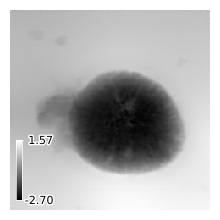

(<Figure size 200x200 with 2 Axes>,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7f59c8111570>)

In [146]:
plot_id = 7
w = crop_sizes[probe_names[plot_id]]
#Get image and crop appropriately
im_to_plot = obj_list[plot_id]
smaller_dim = min(im_to_plot.shape) #Get smaller dimension for center crop
centered_im = center_crop(im_to_plot,smaller_dim)
cropped_im = centered_im[w:-w,w:-w] #Crop additional edges due to bad edge reconstruction/scaling

#Actuall plot
plot_complex_image(cropped_im, save_path = '../../manuscript_figures/Figure_1_dataset', save_name = probe_names[plot_id])

## 1b. Plotting probe images stacked on top of each other.

### Defining probe plotting function

In [8]:
def plot_complex_probe(data, colorbar_size=(0.06, 0.3), 
                      colorbar_position=(0.03, 0.05), figsize=(2,4), 
                      border_thickness=0.02, save_path=None, save_name='probe_default', 
                      format='svg', dpi=600, colormap = 'magma'):
    """
    Plot complex-valued probe data as stacked amplitude and phase images with embedded colorbars.
    
    Parameters:
    -----------
    data : numpy.ndarray
        Complex-valued 2D array
    colorbar_size : tuple
        (width, height) of each colorbar as fraction of each sub-image
    colorbar_position : tuple
        (x, y) position of colorbar bottom-left corner as fraction of each sub-image
    figsize : tuple
        Figure size in inches (width, height)
    border_thickness : float
        Thickness of white border between images as fraction of total height
    save_path : str or None
        Directory path to save the image. If None, displays only
    save_name : str
        Base filename for saved image
    format : str
        Export format ('svg', 'pdf', 'png', 'eps')
    dpi : int
        DPI for raster formats
    """
    
# Extract amplitude and phase data
    amplitude_data = np.abs(data)
    phase_data = np.angle(data)
    
    # Create figure with subplots
    fig, (ax_amp, ax_phase) = plt.subplots(2, 1, figsize=figsize, facecolor='none')
    fig.patch.set_alpha(0)
    plt.subplots_adjust(hspace=border_thickness)
    
    # Process amplitude image (top)
    amp_vmin, amp_vmax = np.min(amplitude_data), np.max(amplitude_data)
    amp_min_label = f'{amp_vmin:.2f}' if amp_vmin <= 0 else f' {amp_vmin:.2f}'
    amp_max_label = f'{amp_vmax:.2f}' if amp_vmax <= 0 else f' {amp_vmax:.2f}'
    amp_tick_labels = [amp_min_label, amp_max_label]
    
    # Display amplitude image
    im_amp = ax_amp.imshow(amplitude_data, cmap= colormap, vmin=amp_vmin, vmax=amp_vmax, 
                          aspect='equal', interpolation='nearest')
    
    # Remove borders and ticks from amplitude axis
    ax_amp.set_xticks([])
    ax_amp.set_yticks([])
    ax_amp.spines['top'].set_visible(False)
    ax_amp.spines['right'].set_visible(False)
    ax_amp.spines['bottom'].set_visible(False)
    ax_amp.spines['left'].set_visible(False)
    
    # Create amplitude colorbar
    amp_pos = ax_amp.get_position()
    cb_left_amp = amp_pos.x0 + colorbar_position[0] * amp_pos.width
    cb_bottom_amp = amp_pos.y0 + colorbar_position[1] * amp_pos.height
    cb_width_amp = colorbar_size[0] * amp_pos.width
    cb_height_amp = colorbar_size[1] * amp_pos.height
    
    ax_cb_amp = fig.add_axes([cb_left_amp, cb_bottom_amp, cb_width_amp, cb_height_amp])
    cb_amp = plt.colorbar(im_amp, cax=ax_cb_amp, orientation='vertical')
    ax_cb_amp.set_aspect('auto')
    
    cb_amp.set_ticks([amp_vmin, amp_vmax])
    cb_amp.set_ticklabels(amp_tick_labels)
    cb_amp.ax.tick_params(color='white', size=1)
    
    cb_amp.ax.tick_params(
        labelsize=8,
        labelcolor='black',
        pad=1,
        left=False, 
        right=True, 
        labelleft=False,
        labelright=True
    )
    
    for label in cb_amp.ax.get_yticklabels():
        label.set_path_effects([
            patheffects.Stroke(linewidth=2, foreground='white'),
            patheffects.Normal()
        ])
    
    cb_amp.outline.set_visible(True)
    cb_amp.outline.set_linewidth(1.5)
    cb_amp.outline.set_edgecolor('white')
    
    # Process phase image (bottom)
    phase_vmin, phase_vmax = np.min(phase_data), np.max(phase_data)
    phase_min_label = f'{phase_vmin:.2f}' if phase_vmin <= 0 else f' {phase_vmin:.2f}'
    phase_max_label = f'{phase_vmax:.2f}' if phase_vmax <= 0 else f' {phase_vmax:.2f}'
    phase_tick_labels = [phase_min_label, phase_max_label]
    
    # Display phase image
    im_phase = ax_phase.imshow(phase_data, cmap= colormap, vmin=phase_vmin, vmax=phase_vmax, 
                              aspect='equal', interpolation='nearest')
    
    # Remove borders and ticks from phase axis
    ax_phase.set_xticks([])
    ax_phase.set_yticks([])
    ax_phase.spines['top'].set_visible(False)
    ax_phase.spines['right'].set_visible(False)
    ax_phase.spines['bottom'].set_visible(False)
    ax_phase.spines['left'].set_visible(False)
    
    # Create phase colorbar
    phase_pos = ax_phase.get_position()
    cb_left_phase = phase_pos.x0 + colorbar_position[0] * phase_pos.width
    cb_bottom_phase = phase_pos.y0 + colorbar_position[1] * phase_pos.height
    cb_width_phase = colorbar_size[0] * phase_pos.width
    cb_height_phase = colorbar_size[1] * phase_pos.height
    
    ax_cb_phase = fig.add_axes([cb_left_phase, cb_bottom_phase, cb_width_phase, cb_height_phase])
    cb_phase = plt.colorbar(im_phase, cax=ax_cb_phase, orientation='vertical')
    ax_cb_phase.set_aspect('auto')
    
    cb_phase.set_ticks([phase_vmin, phase_vmax])
    cb_phase.set_ticklabels(phase_tick_labels)
    cb_phase.ax.tick_params(color='white', size=1)
    
    cb_phase.ax.tick_params(
        labelsize=8,
        labelcolor='black',
        pad=1,
        left=False, 
        right=True, 
        labelleft=False,
        labelright=True
    )
    
    for label in cb_phase.ax.get_yticklabels():
        label.set_path_effects([
            patheffects.Stroke(linewidth=2, foreground='white'),
            patheffects.Normal()
        ])
    
    cb_phase.outline.set_visible(True)
    cb_phase.outline.set_linewidth(1.5)
    cb_phase.outline.set_edgecolor('white')
    
    if save_path:
        full_save_path = os.path.join(save_path, f"{save_name}.{format}")
        plt.savefig(full_save_path, format=format, dpi=dpi, 
                   bbox_inches='tight', pad_inches=0, 
                   transparent=True, facecolor='none')
        print(f"Image saved as {full_save_path}")
    
    plt.show()
    return fig, ax_amp, ax_phase, cb_amp, cb_phase

### Actually plotting probe image now

Image saved as ../../manuscript_figures/Figure_1_dataset/velo_ncm_probe.svg


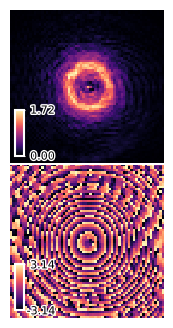

(<Figure size 200x400 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7f59c14b6e30>)

In [192]:
plot_id = 7
probe_to_plot = probe_list[plot_id]
full_save_name = probe_names[plot_id] + '_probe'
#Actuall plot
plot_complex_probe(probe_to_plot, border_thickness = 0.01, colormap = 'magma', save_path = '../../manuscript_figures/Figure_1_dataset', save_name = full_save_name)

## 1c Plotting synthetic object phases

In [9]:
from ptychopinn_torch.datagen.datagen import simulate_synthetic_objects

In [195]:
#Prep and setting up
n_experiments = 1
img_shape = (200,200) #Object sizing

obj_arg = {'blur': True,
           'r_min_frac': 0.03,
           'r_max_frac': 0.2,
           'r_sigma': 3,
           'max_iters': 500}

            #  'probe_method': 'fzp'}

#Data configs
data_config = DataConfig()
data_config_replace = {'N': 64}
update_existing_config(data_config, data_config_replace)


## Generating synthetic data with experimental probes

In [272]:
#Generating object for plotting
synthetic_obj = simulate_synthetic_objects(img_shape, data_config, n_experiments, "blurred_white_noise", obj_arg)[0]


Image saved as ../../manuscript_figures/Figure_1_dataset/blurred_white_noise.svg


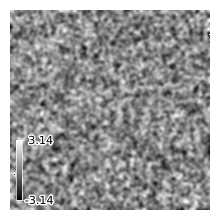

(<Figure size 200x200 with 2 Axes>,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7f59b774cb50>)

In [273]:
plot_complex_image(synthetic_obj, save_path = '../../manuscript_figures/Figure_1_dataset', save_name = "blurred_white_noise")

## 1d. Generate Radial PSD plots for inset on each object image

### Function definitions

In [7]:
def compute_psd_2d(image):
    """
    Compute the 2D power spectral density of an image.
    
    Args:
        image (np.ndarray): 2D image array (real or complex)
        
    Returns:
        np.ndarray: 2D power spectral density
    """
    # Take 2D FFT
    fft_2d = np.fft.fft2(image)
    
    # Shift zero frequency to center
    fft_2d_shifted = np.fft.fftshift(fft_2d)
    
    # Compute power spectral density
    psd_2d = np.abs(fft_2d_shifted)**2
    
    return psd_2d

def compute_radial_psd(image):
    """
    Compute the radially averaged power spectral density.
    This gives you a 1D profile showing how power varies with spatial frequency.
    
    Args:
        image (np.ndarray): 2D image array
        
    Returns:
        tuple: (frequencies, radial_psd)
    """
    # Get 2D PSD
    psd_2d = compute_psd_2d(image)
    
    h, w = psd_2d.shape
    center_y, center_x = h // 2, w // 2
    
    # Create coordinate arrays
    y, x = np.ogrid[:h, :w]
    
    # Calculate distance from center for each pixel
    r = np.sqrt((x - center_x)**2 + (y - center_y)**2)
    
    # Define radial bins
    max_r = min(center_x, center_y)
    r_bins = np.arange(0, max_r, 1)
    
    # Compute radially averaged PSD
    radial_psd = []
    for i in range(len(r_bins) - 1):
        mask = (r >= r_bins[i]) & (r < r_bins[i + 1])
        if np.any(mask):
            radial_psd.append(np.mean(psd_2d[mask]))
        else:
            radial_psd.append(0)
    
    # Convert bin indices to actual frequencies
    frequencies = r_bins[:-1] / max(h, w)  # Normalized frequencies
    
    return frequencies, np.array(radial_psd)

In [10]:
def plot_radial_psd(object_image, figsize=(2,2), line_color='black', linewidth=3, fontsize=14,
                    save_path = None, save_name = 'default', dpi = 600, format='svg'):

    frequencies, radial_psd = compute_radial_psd(object_image)

    # Create figure with transparent background
    fig = plt.figure(figsize=figsize, facecolor='none')
    fig.patch.set_alpha(0)
    # ax = plt.gca()
    # ax.set_facecolor('black') 
    
    # For the plot line itself:
    plt.loglog(frequencies[1:], radial_psd[1:], 
            color=line_color, 
            linewidth=linewidth,
            path_effects=[patheffects.Stroke(linewidth=linewidth+2, foreground='white', alpha=1.0),
                        patheffects.Normal()])

    # For axis labels:
    plt.xlabel('Frequency', fontsize=fontsize, fontweight='bold', color=line_color,
            path_effects=[patheffects.Stroke(linewidth=2, foreground='white', alpha=1.0),
                        patheffects.Normal()])
    plt.ylabel('Power', fontsize=fontsize, fontweight='bold', color=line_color,
            path_effects=[patheffects.Stroke(linewidth=2, foreground='white', alpha=1.0),
                        patheffects.Normal()])
    plt.ylim([1e2,1e8])

    # For tick labels:
    ax = plt.gca()
    plt.tick_params(axis='both', which='major', labelsize=fontsize-2, 
                   colors=line_color, width=2, length=6)
    plt.tick_params(axis='both', which='minor', labelsize=fontsize-4, 
                   colors=line_color, width=1, length=3)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_path_effects([patheffects.Stroke(linewidth=2, foreground='white', alpha=1.0),
                            patheffects.Normal()])

    # For plot borders with white outline:
    for spine in ax.spines.values():
        spine.set_color(line_color)
        spine.set_linewidth(2)
        spine.set_path_effects([patheffects.Stroke(linewidth=4, foreground='white', alpha=1.0),
                            patheffects.Normal()])
    
    # Tight layout for clean overlay
    plt.tight_layout()

    if save_path:
        full_save_path = os.path.join(save_path, f"{save_name}.{format}")
        plt.savefig(full_save_path, format=format, dpi=dpi, 
                    bbox_inches='tight', pad_inches=0, 
                    transparent=True, facecolor='none')
        print(f"Image saved as {full_save_path}")
    
    return fig

### Actually plotting now

In [235]:
probe_names

['cosmic_micro_lfp',
 'hxn_cnm',
 'velo_fly001',
 'velo_gold_tp_1',
 'velo_gold_tp_2',
 'velo_ic_1',
 'velo_ic_2',
 'velo_ncm']

**Plotting PSD for experimental objecrts**

Image saved as ../../manuscript_figures/Figure_1_dataset/velo_ncm_psd_black.svg


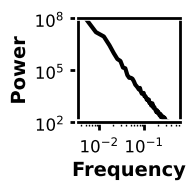

In [18]:
plot_id = 7
w = crop_sizes[probe_names[plot_id]]

#Get image and crop appropriately
im_to_plot = obj_list[plot_id]
smaller_dim = min(im_to_plot.shape) #Get smaller dimension for center crop
centered_im = center_crop(im_to_plot,smaller_dim)
cropped_im = centered_im[w:-w,w:-w] #Crop additional edges due to bad edge reconstruction/scaling

#Plotting
full_save_name = probe_names[plot_id] + '_psd_black'
fig = plot_radial_psd(cropped_im, save_path = '../../manuscript_figures/Figure_1_dataset', save_name = full_save_name)

**Plotting PSD for synthetic objects**

Amplitude range: 0.6000 - 1.1000
Phase range: -3.1416 - 3.1416 radians
Beta map range: 0.0000e+00 - 9.9427e-04
Delta map range: 0.0000e+00 - 1.1538e-01
Image saved as ../../manuscript_figures/Figure_1_dataset/dead_leaves_psd.svg


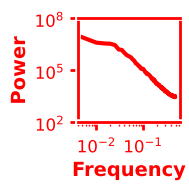

In [329]:
#Generating object for plotting
synth_name = "dead_leaves"
synthetic_obj = simulate_synthetic_objects(img_shape, data_config, n_experiments, synth_name, obj_arg)[0]
full_save_name = synth_name + '_psd'
fig = plot_radial_psd(synthetic_obj, save_path = '../../manuscript_figures/Figure_1_dataset', save_name = full_save_name)

## 1e. Getting diffraction patterns from random experiments to tilt (cannot be SVG)

### Helper Functions

In [28]:
def plot_diffraction(data, cmap = 'gray', colorbar_plot = True, colorbar_size=(0.03, 0.3), 
                      colorbar_position=(0.03, 0.05), figsize=(2,2), 
                      save_path=None, save_name = 'default', format='png', dpi=600):

                      
    """
    Plot complex-valued data as phase or amplitude image with embedded colorbar.
    
    Parameters:
    -----------
    data : numpy.ndarray
        Complex-valued 2D array
    image_type : str
        'phase' or 'amplitude'
    colorbar_size : tuple
        (width, height) of colorbar as fraction of image
    colorbar_position : tuple
        (x, y) position of colorbar bottom-left corner as fraction of image
    figsize : tuple
        Figure size in inches
    save_path : str or None
        Path to save the image. If None, displays only
    format : str
        Export format ('svg', 'pdf', 'png', 'eps')
    dpi : int
        DPI for raster formats
    """
    

    image_data = data
    vmin, vmax = np.min(image_data), np.max(image_data)
    tick_values = [vmin, vmax]
    min_label = f'{vmin:.2f}' if vmin <= 0 else f' {vmin:.2f}'
    max_label = f'{vmin:.2f}' if vmax <= 0 else f' {vmax:.2f}'
    tick_labels = [min_label, max_label]
    
    # Create figure with transparent background
    fig = plt.figure(figsize=figsize, facecolor='none')
    fig.patch.set_alpha(0)
    
    # Create main axis for the image (takes up full figure)
    ax_main = fig.add_axes([0, 0, 1, 1])
    
    # Display the main image
    im = ax_main.imshow(image_data, cmap=cmap, vmin=vmin, vmax=vmax, 
                       aspect='equal', interpolation='nearest')
    
    # Remove all borders and ticks from main axis
    ax_main.set_xticks([])
    ax_main.set_yticks([])
    ax_main.spines['top'].set_visible(False)
    ax_main.spines['right'].set_visible(False)
    ax_main.spines['bottom'].set_visible(False)
    ax_main.spines['left'].set_visible(False)
    
    # Create colorbar axis positioned in bottom left
    # Position: [left, bottom, width, height] in figure coordinates
    if colorbar_plot:
        cb_left = colorbar_position[0]
        cb_bottom = colorbar_position[1]
        cb_width = colorbar_size[0]
        cb_height = colorbar_size[1]
        
        ax_cb = fig.add_axes([cb_left, cb_bottom, cb_width, cb_height])
        
        # Create colorbar using the proper matplotlib functionality
        cb = plt.colorbar(im, cax=ax_cb, orientation='vertical')

        # Ensure the colorbar axis maintains proper aspect ratio
        ax_cb.set_aspect('auto')
        
        # Set up default tick marks (matplotlib will create appropriate intermediate ticks)
        # But only label the top and bottom
        cb.set_ticks([vmin, vmax])  # Only set labels for min and max
        cb.set_ticklabels(tick_labels)
        cb.ax.tick_params(color='white', size = 1)
        
        # Style the colorbar ticks - keep default appearance but adjust label positioning
        cb.ax.tick_params(
            labelsize=8,
            labelcolor='black',
            pad=1,  # Distance between colorbar and labels
            left=False, 
            right=True, 
            labelleft=False,  # Remove left labels
            labelright=True   # Keep right labels
        )

        for label in cb.ax.get_yticklabels():
                label.set_path_effects([
                    patheffects.Stroke(linewidth=2, foreground='white'),
                    patheffects.Normal()
                ])
    
        # Keep the colorbar outline (standard border)
        cb.outline.set_visible(True)
        cb.outline.set_linewidth(0.5)
        cb.outline.set_edgecolor('white')
    
    if save_path:
        full_save_path = os.path.join(save_path, f"{save_name}.{format}")
        plt.savefig(full_save_path, format=format, dpi=dpi, 
                   bbox_inches='tight', pad_inches=0, 
                   transparent=True, facecolor='none')
        print(f"Image saved as {full_save_path}")
    
    plt.show()
    return fig, ax_main

In [13]:
exp_path = '../../data/pinn_velo_gold_tp_2/*'
file_path = glob(exp_path)[0]

exp_dat = np.load(file_path)


Image saved as ../../manuscript_figures/Figure_1_dataset/diff_gold_tp_2_200.png


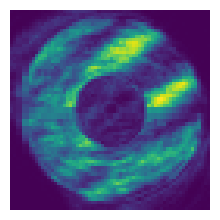

(<Figure size 200x200 with 1 Axes>, <Axes: >)

In [40]:
plot_idx = 200
diff_to_plot = exp_dat['diff3d'][plot_idx]
full_save_name = "diff_gold_tp_2_" + str(plot_idx)

plot_diffraction(diff_to_plot, cmap = 'viridis', colorbar_plot = False,
                 save_path = '../../manuscript_figures/Figure_1_dataset',
                 save_name = full_save_name)

In [35]:
synth_path = '../../data/synthetic_experiments/*'
file_path = glob(synth_path)[0]

syn_dat = np.load(file_path)


Image saved as ../../manuscript_figures/Figure_1_dataset/diff_synth_tp_2_probe_150.png


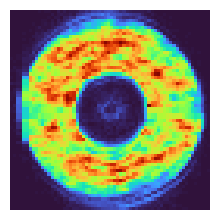

(<Figure size 200x200 with 1 Axes>, <Axes: >)

In [39]:
plot_idx = 150
diff_to_plot = exp_dat['diff3d'][plot_idx]
full_save_name = "diff_synth_tp_2_probe_" + str(plot_idx)

plot_diffraction(diff_to_plot, cmap = 'turbo', colorbar_plot = False,
                 save_path = '../../manuscript_figures/Figure_1_dataset',
                 save_name = full_save_name)

# Figure 2

## 1a. Side by side phase/amplitude images for representative experiments

### Helper functions

In [18]:
def plot_object(data, colorbar_size=(0.06, 0.3), 
                      colorbar_position=(0.03, 0.05), figsize=(4,2), 
                      border_thickness=0.02, save_path=None, save_name='probe_default', 
                      format='svg', dpi=600):
    """
    Plot complex-valued object data as horizontally stacked amplitude and phase images with embedded colorbars.
    
    Parameters:
    -----------
    data : numpy.ndarray
        Complex-valued 2D array
    colorbar_size : tuple
        (width, height) of each colorbar as fraction of each sub-image
    colorbar_position : tuple
        (x, y) position of colorbar bottom-left corner as fraction of each sub-image
    figsize : tuple
        Figure size in inches (width, height)
    border_thickness : float
        Thickness of white border between images as fraction of total height
    save_path : str or None
        Directory path to save the image. If None, displays only
    save_name : str
        Base filename for saved image
    format : str
        Export format ('svg', 'pdf', 'png', 'eps')
    dpi : int
        DPI for raster formats
    """
    
# Extract amplitude and phase data
    amplitude_data = np.abs(data)
    phase_data = np.angle(data)
    
    # Create figure with subplots
    fig, (ax_amp, ax_phase) = plt.subplots(1,2, figsize=figsize, facecolor='none')
    fig.patch.set_alpha(0)
    plt.subplots_adjust(wspace=border_thickness)
    
    # Process amplitude image (top)
    amp_vmin, amp_vmax = np.min(amplitude_data), np.max(amplitude_data)
    amp_min_label = f'{amp_vmin:.2f}' if amp_vmin <= 0 else f' {amp_vmin:.2f}'
    amp_max_label = f'{amp_vmax:.2f}' if amp_vmax <= 0 else f' {amp_vmax:.2f}'
    amp_tick_labels = [amp_min_label, amp_max_label]
    
    # Display amplitude image
    im_amp = ax_amp.imshow(amplitude_data, cmap= 'viridis', vmin=amp_vmin, vmax=amp_vmax, 
                          aspect='equal', interpolation='nearest')
    
    # Remove borders and ticks from amplitude axis
    ax_amp.set_xticks([])
    ax_amp.set_yticks([])
    ax_amp.spines['top'].set_visible(False)
    ax_amp.spines['right'].set_visible(False)
    ax_amp.spines['bottom'].set_visible(False)
    ax_amp.spines['left'].set_visible(False)
    
    # Create amplitude colorbar
    amp_pos = ax_amp.get_position()
    cb_left_amp = amp_pos.x0 + colorbar_position[0] * amp_pos.width
    cb_bottom_amp = amp_pos.y0 + colorbar_position[1] * amp_pos.height
    cb_width_amp = colorbar_size[0] * amp_pos.width
    cb_height_amp = colorbar_size[1] * amp_pos.height
    
    ax_cb_amp = fig.add_axes([cb_left_amp, cb_bottom_amp, cb_width_amp, cb_height_amp])
    cb_amp = plt.colorbar(im_amp, cax=ax_cb_amp, orientation='vertical')
    ax_cb_amp.set_aspect('auto')
    
    cb_amp.set_ticks([amp_vmin, amp_vmax])
    cb_amp.set_ticklabels(amp_tick_labels)
    cb_amp.ax.tick_params(color='white', size=1)
    
    cb_amp.ax.tick_params(
        labelsize=8,
        labelcolor='black',
        pad=1,
        left=False, 
        right=True, 
        labelleft=False,
        labelright=True
    )
    
    for label in cb_amp.ax.get_yticklabels():
        label.set_path_effects([
            patheffects.Stroke(linewidth=2, foreground='white'),
            patheffects.Normal()
        ])
    
    cb_amp.outline.set_visible(True)
    cb_amp.outline.set_linewidth(1.5)
    cb_amp.outline.set_edgecolor('white')
    
    # Process phase image (bottom)
    phase_vmin, phase_vmax = np.min(phase_data), np.max(phase_data)
    phase_min_label = f'{phase_vmin:.2f}' if phase_vmin <= 0 else f' {phase_vmin:.2f}'
    phase_max_label = f'{phase_vmax:.2f}' if phase_vmax <= 0 else f' {phase_vmax:.2f}'
    phase_tick_labels = [phase_min_label, phase_max_label]
    
    # Display phase image
    im_phase = ax_phase.imshow(phase_data, cmap= 'gray', vmin=phase_vmin, vmax=phase_vmax, 
                              aspect='equal', interpolation='nearest')
    
    # Remove borders and ticks from phase axis
    ax_phase.set_xticks([])
    ax_phase.set_yticks([])
    ax_phase.spines['top'].set_visible(False)
    ax_phase.spines['right'].set_visible(False)
    ax_phase.spines['bottom'].set_visible(False)
    ax_phase.spines['left'].set_visible(False)
    
    # Create phase colorbar
    phase_pos = ax_phase.get_position()
    cb_left_phase = phase_pos.x0 + colorbar_position[0] * phase_pos.width
    cb_bottom_phase = phase_pos.y0 + colorbar_position[1] * phase_pos.height
    cb_width_phase = colorbar_size[0] * phase_pos.width
    cb_height_phase = colorbar_size[1] * phase_pos.height
    
    ax_cb_phase = fig.add_axes([cb_left_phase, cb_bottom_phase, cb_width_phase, cb_height_phase])
    cb_phase = plt.colorbar(im_phase, cax=ax_cb_phase, orientation='vertical')
    ax_cb_phase.set_aspect('auto')
    
    cb_phase.set_ticks([phase_vmin, phase_vmax])
    cb_phase.set_ticklabels(phase_tick_labels)
    cb_phase.ax.tick_params(color='white', size=1)
    
    cb_phase.ax.tick_params(
        labelsize=8,
        labelcolor='black',
        pad=1,
        left=False, 
        right=True, 
        labelleft=False,
        labelright=True
    )
    
    for label in cb_phase.ax.get_yticklabels():
        label.set_path_effects([
            patheffects.Stroke(linewidth=2, foreground='white'),
            patheffects.Normal()
        ])
    
    cb_phase.outline.set_visible(True)
    cb_phase.outline.set_linewidth(1.5)
    cb_phase.outline.set_edgecolor('white')
    
    if save_path:
        full_save_path = os.path.join(save_path, f"{save_name}.{format}")
        plt.savefig(full_save_path, format=format, dpi=dpi, 
                   bbox_inches='tight', pad_inches=0, 
                   transparent=True, facecolor='none')
        print(f"Image saved as {full_save_path}")
    
    plt.show()
    return fig, ax_amp, ax_phase, cb_amp, cb_phase

#### Experiment List Dictionaries

In [ ]:
file_list = ['../../data/pinn_hxn_cnm',
            '../../data/pinn_velo_fly001',
            # '../../data/pinn_velo_als_ns',
            '../../data/pinn_velo_gold_tp_1',
            '../../data/pinn_velo_gold_tp_2',
            '../../data/pinn_velo_ic_1',
            '../../data/pinn_velo_ic_2',
            '../../data/pinn_cosmic_micro_lfp',
            '../../data/pinn_velo_ncm',
            ]

model_dict = {
    #Synthetic
    'pinn_hxn_cnm_syn': '74ba23396c4042afb1751afe9fa87520',
    'pinn_velo_fly001_syn': '3d2ca583357c43baa6ab17519d500355',
    # 'pinn_velo_als_ns_syn': '', #Need to fix
    'pinn_velo_gold_tp_1_syn': 'f637381fd7fe49158bb0ed2e7a28ca45',
    'pinn_velo_gold_tp_2_syn': '6fb4668f21e44e0b80056f64fdfedf01',
    'pinn_velo_ic_1_syn': '345aa234e8f34935af11c3ebed167448',
    'pinn_velo_ic_2_syn': '06822d7239504a93ae0f7a6c4577cdc8',
    'pinn_cosmic_micro_lfp_syn': '1cda8280703748fabba173f747fc4103', #Need to fix properly
    'pinn_velo_ncm_syn': '0908cd113f774d15802f41e40b3a51e2',
    #Experimental
    'pinn_hxn_cnm_exp': '3360765d399443d0a758e9667c8455b5',
    'pinn_velo_fly001_exp': '4911939f91d147348f450ec1d78811dd',
    'pinn_velo_gold_tp_1_exp': 'c86ba4cc6d424a8fb1370bcfa87d967c',
    'pinn_velo_gold_tp_2_exp': '3dcc4ce0423c46f6bab529294886f453',
    'pinn_velo_ic_1_exp': 'b1f8f06f9dee41e48e0323d295e0a5d3',
    'pinn_velo_ic_2_exp': 'e09fa3d8b48e406aa7c9ff78e34f7782',
    'pinn_velo_ncm_exp': '293d4107954d4d11832fe979e6045229',
    'pinn_cosmic_micro_lfp_exp': 'aee5ab755d8e4e558c1f328491adb0fb',
    #Supervised
    'pinn_velo_gold_tp_2_supervised': 'fb950794aaad49dba03ffee8cc6ea230'
}

# Window size dict. All values should be 20 except for pinn_gold_tp_2, which is 40. Use only names of experiments without _syn or _exp suffixes
window_size_dict = {
    #Synthetic objects
    'pinn_hxn_cnm': 20,
    'pinn_hxn_cnm_supervised': 20,
    'pinn_velo_fly001': 20,
    'pinn_velo_fly001_supervised': 20,
    'pinn_velo_als_ns': 20,
    'pinn_velo_gold_tp_1': 20,
    'pinn_velo_gold_tp_1_supervised': 20,
    'pinn_velo_gold_tp_2': 40,
    'pinn_velo_gold_tp_2_supervised': 40,
    'pinn_velo_ic_1': 20,
    'pinn_velo_ic_2': 20,
    'pinn_velo_ic_2_supervised': 20,
    'pinn_cosmic_micro_lfp': 20,
    'pinn_velo_ncm': 20,
    'pinn_velo_ncm_supervised': 10,
}

#### Other helper functions

In [2]:
def load_dataset(ptycho_dir, model_id, data_config_replace=None):
    """
    Loads dataset with configuration parameters linked to specific model ID.
    Args:
        ptycho_dir (str): Directory containing the ptychography data.
        model_id (str): Model ID to load the dataset configuration from.
        data_config_replace (dict, optional): Dictionary to replace specific data configuration parameters.
    """
    


    #Load configs
    data_config, model_config, training_config, inference_config = load_all_configs_from_mlflow(model_id,
                                                                                            tracking_uri)


    # Replace data config if avail
    if data_config_replace is not None:
        update_existing_config(data_config, data_config_replace)

    print('Creating dataset...')
    ptycho_dataset = PtychoDataset(ptycho_dir, model_config, data_config,
                                remake_map=True)

    return ptycho_dataset, data_config, model_config, training_config, inference_config

In [3]:
def load_model_and_reconstruct(model_id, ptycho_dataset,
                              data_config, model_config, training_config,
                              inference_config, inference_config_replace = None):
    """
    Loads the model and reconstructs the image from the dataset.
    Args:
        model_id (str): Model ID to load the model from.
        ptycho_dataset (PtychoDataset): Dataset containing the ptychography data.
        data_config (DataConfig): Data configuration parameters.
        model_config (ModelConfig): Model configuration parameters.
        training_config (TrainingConfig): Training configuration parameters.
        inference_config (InferenceConfig): Inference configuration parameters.
    """
    
    # Loading model
    mlflow.set_tracking_uri(tracking_uri)
    model_uri = f"runs:/{model_id}/model"
    loaded_model = mlflow.pytorch.load_model(model_uri)
    loaded_model.to('cuda')
    loaded_model.training = True

    # Reconstruct image
    print('Reconstructing image...')
    result, recon_dataset = reconstruct_image(loaded_model, ptycho_dataset,
                           training_config, data_config, model_config, inference_config)

    return result, recon_dataset

In [4]:
def get_target_and_prediction_images_and_window(result, recon_dataset, window_size=0):
    """
    Meant to be called on result of reconstruct_image which still resides on GPU.
    Gets target amplitude and phase images, as well as the prediction amplitude and phase images.
    Crops to specified window size if provided.
    Args:
        result (torch.Tensor): Result tensor from the reconstruction. Complex-valued
        recon_dataset (PtychoDataset): Dataset containing the ptychography data.
        window_size (int): Size of the window to crop the images to. If 0, no cropping is done. Will almost surely be greater than 0.
    Returns:
        np.ndarray: Numpy array of the result.
    """
    #Move result to CPU and remove channel dimension if needed
    im_cpu = result.to('cpu')
    if len(im_cpu.shape) == 3:
        im_cpu = im_cpu.squeeze()
    
    # Set to shorter variable for readability
    w = window_size

    # Object recon
    recon = im_cpu.detach().cpu().numpy().copy()[w:-w,w:-w]

    # Ground truth
    gt = recon_dataset.data_dict['objectGuess'][0].copy()[w:-w,w:-w]
    gt = center_crop(gt, recon.shape[0])

    return gt, recon
    


In [22]:
## Quick and dirty reconstruction plotting

def generate_gt_and_recon(file, model_name, model_dict):
    
    model_id = model_dict[model_name]

    exp_name = file.split('/')[-1]

    data_config_replace = {}

    data_config_replace['normalize'] = 'Batch'
    data_config_replace['probe_normalize'] = 'False'
    data_config_replace['scan_pattern'] = 'Rectangular'
    data_config_replace['n_subsample'] = 1
    data_config_replace["x_bounds"] = [0.05, 0.95]
    data_config_replace["y_bounds"] = [0.05, 0.95]
    data_config_replace["min_neighbor_distance"] = 0.5
    data_config_replace["max_neighbor_distance"] = 8

    # Check to see if need to replace data config
    if exp_name in ['pinn_velo_gold_tp_1', 'pinn_velo_ic_1', 'pinn_velo_gold_tp_1_supervised', 'pinn_velo_ic_1_supervised']:
        data_config_replace["x_bounds"] = [0.07, 0.93]
        data_config_replace["y_bounds"] = [0.07, 0.93]
    
    ptycho_dataset, data_config, model_config, training_config, inference_config = load_dataset(file, model_id,
                                                                                                  data_config_replace=data_config_replace)
        
    #Replacing inference config
    inference_config_replace = {'middle_trim': data_config.N//2,
                        'batch_size': 512,
                        'experiment_number': 0,
                        'pad_eval': True}

    update_existing_config(inference_config, inference_config_replace)
        
        
    print("Beginning reconstruction...")
    # Load model and reconstruct image
    result, recon_dataset = load_model_and_reconstruct(model_id, ptycho_dataset,
                                                    data_config, model_config,
                                                    training_config, inference_config)
    
    print("Recon complete. Beginning FRC calculation...")
    # Get target and prediction images
    gt, recon = get_target_and_prediction_images_and_window(result, recon_dataset,
                                                                window_size=window_size_dict[exp_name])
    
    return gt, recon

## Fig 2. Looking at actual reconstructions

In [15]:
# Constant vars
relative_mlruns_path = '../../mlruns'
tracking_uri = f"file:{os.path.abspath(relative_mlruns_path)}"

In [86]:
gt, recon = generate_gt_and_recon('../../data/pinn_velo_gold_tp_2', 'pinn_cosmic_micro_lfp_syn', model_dict)

amp, phase = np.abs(recon), np.angle(recon)

Creating dataset...
Calculating dataset length with coordinate bounds...
For file ../../data/pinn_velo_gold_tp_2/nxs_data_gold_tp_2_64_train.npz, maximum x_range is (33.47206497192383, 566.5279541015625), yrange is (33.47703552246094, 630.52294921875)
Creating memory mapped tensor dictionary...
Memory map length: 5931
Memory map creation time: 0.0012903213500976562
Populating memory map for dataset 0
Start - end = 5931
grouping
4_quadrant
Building KDTree for 7709 points...
Processing 5931 potential central points...
Finished quadrant neighbor processing. Found 5931 valid C=4 groups.
Non-diffraction memory map write time: 0.7542102336883545
Getting normalization coefficients...
Batch rms factor is tensor([[[[0.0031]]]])
Diffraction memory map write time: 0.2525365352630615
[PtychoDataset Rank 0] Initialization successful. Dataset length: 5931.
Beginning reconstruction...
Reconstructing image...
Batch 0 completed in 0.24850106239318848 seconds
Batch 1 completed in 0.24002456665039062 sec

Image saved as ../../manuscript_figures/Figure_2_comparison/All_comparisons/tp2/lfp_train_tp2_test.svg


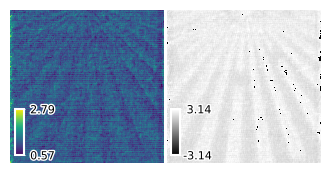

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7ff8840f7370>)

In [87]:
full_save_name = "lfp_train_tp2_test"
plot_object(recon,
            save_path = '../../manuscript_figures/Figure_2_comparison/All_comparisons/tp2',
            save_name = full_save_name)

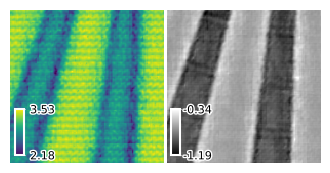

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7f7c458c27a0>)

In [ ]:
full_save_name = "supervised_cnm"
half = recon.shape[0]//2
size = 150
y_offset = 30
x_offset = -60
plot_object(recon[half+y_offset:half+y_offset+size, half+x_offset-size//2:half+x_offset+size//2])
            # save_path = '../../manuscript_figures/Figure_2_comparison',
            # save_name = full_save_name)

#### Loop to generate all images needed for SI (I can pick and choose ofc)

In [23]:
model_name_dict = {
    #Synthetic
    'pinn_hxn_cnm_syn': 'cnm_train',
    'pinn_velo_fly001_syn': 'fly1_train',
    # 'pinn_velo_als_ns_syn': '', #Need to fix
    'pinn_velo_gold_tp_1_syn': 'tp1_train',
    'pinn_velo_gold_tp_2_syn': 'tp2_train',
    'pinn_velo_ic_1_syn': 'ic1_train',
    'pinn_velo_ic_2_syn': 'ic2_train',
    'pinn_cosmic_micro_lfp_syn': 'lfp_train', #Need to fix properly
    'pinn_velo_ncm_syn': 'ncm_train',
    #Experimental
    'pinn_hxn_cnm_exp': 'cnm_exp_train',
    'pinn_velo_fly001_exp': 'fly1_exp_train',
    'pinn_velo_gold_tp_1_exp': 'tp1_exp_train',
    'pinn_velo_gold_tp_2_exp': 'tp2_exp_train',
    'pinn_velo_ic_1_exp': 'ic1_exp_train',
    'pinn_velo_ic_2_exp': 'ic2_exp_train',
    'pinn_velo_ncm_exp': 'ncm_exp_train',
    'pinn_cosmic_micro_lfp_exp': 'lfp_exp_train',
}

file_name_dict = {'../../data/pinn_hxn_cnm': 'cnm',
            '../../data/pinn_velo_fly001': 'fly1',
            # '../../data/pinn_velo_als_ns',
            '../../data/pinn_velo_gold_tp_1': 'tp1',
            '../../data/pinn_velo_gold_tp_2': 'tp2',
            '../../data/pinn_velo_ic_1': 'ic1',
            '../../data/pinn_velo_ic_2': 'ic2',
            '../../data/pinn_cosmic_micro_lfp': 'lfp',
            '../../data/pinn_velo_ncm': 'ncm',
}


def plot_all_objects(base_save_directory, model_name_dict, file_name_dict,
                     model_dict):
    for dir_name in file_name_dict.keys():
        print(f"Starting recons for file: {file_name_dict[dir_name]}")
        for model in model_name_dict.keys():
            if model == 'pinn_velo_gold_tp_1_exp':
                #Generate recon
                gt, recon = generate_gt_and_recon(dir_name, model, model_dict)
                #Generate save
                full_save_name = model_name_dict[model] + "_" + file_name_dict[dir_name] + "_test"
                full_save_path = base_save_directory + "/" + file_name_dict[dir_name]
                if not os.path.exists(full_save_path):
                    os.mkdir(full_save_path)

                plot_object(recon,
                save_path = full_save_path,
                save_name = full_save_name)

Starting recons for file: cnm
Creating dataset...
Calculating dataset length with coordinate bounds...
For file ../../data/pinn_hxn_cnm/CNM_APS_XNP_scan39_pty-chi_LSQML-64.npz, maximum x_range is (33.04172515869142, 203.9582748413086), yrange is (33.0417251586895, 203.9582748413105)
Creating memory mapped tensor dictionary...
Memory map length: 20449
Memory map creation time: 0.0013413429260253906
Populating memory map for dataset 0
Start - end = 20449
grouping
4_quadrant
Building KDTree for 25921 points...
Processing 20449 potential central points...
Finished quadrant neighbor processing. Found 20449 valid C=4 groups.
Non-diffraction memory map write time: 2.823974370956421
Getting normalization coefficients...
Normalize is Batch
Batch rms factor is tensor([[[[0.0002]]]])
Diffraction memory map write time: 0.7013475894927979
[PtychoDataset Rank 0] Initialization successful. Dataset length: 20449.
Beginning reconstruction...
Reconstructing image...
Batch 0 completed in 0.15200614929199

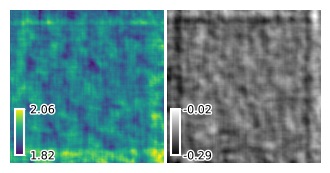

Starting recons for file: fly1
Creating dataset...
Calculating dataset length with coordinate bounds...
For file ../../data/pinn_velo_fly001/fly001_64_train.npz, maximum x_range is (33.484195709228516, 198.51580810546875), yrange is (33.05133819580078, 198.9486541748047)
Creating memory mapped tensor dictionary...
Memory map length: 8125
Memory map creation time: 0.0007309913635253906
Populating memory map for dataset 0
Start - end = 8125
grouping
4_quadrant
Building KDTree for 10304 points...
Processing 8125 potential central points...
Finished quadrant neighbor processing. Found 8125 valid C=4 groups.
Non-diffraction memory map write time: 0.6613569259643555
Getting normalization coefficients...
Normalize is Batch
Batch rms factor is tensor([[[[0.0063]]]])
Diffraction memory map write time: 0.1744520664215088
[PtychoDataset Rank 0] Initialization successful. Dataset length: 8125.
Beginning reconstruction...
Reconstructing image...
Batch 0 completed in 0.15165257453918457 seconds
Batc

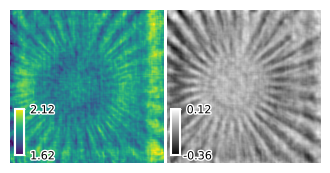

Starting recons for file: tp1
Creating dataset...
Calculating dataset length with coordinate bounds...
For file ../../data/pinn_velo_gold_tp_1/nxs_data_gold_tp_1_64_train.npz, maximum x_range is (33.33454895019531, 168.6654510498047), yrange is (33.13616943359375, 165.86383056640625)
Creating memory mapped tensor dictionary...
Memory map length: 780
Memory map creation time: 0.0007481575012207031
Populating memory map for dataset 0
Start - end = 780
grouping
4_quadrant
Building KDTree for 1143 points...
Processing 780 potential central points...
Finished quadrant neighbor processing. Found 780 valid C=4 groups.
Non-diffraction memory map write time: 0.056027889251708984
Getting normalization coefficients...
Normalize is Batch
Batch rms factor is tensor([[[[0.0016]]]])
Diffraction memory map write time: 0.03154158592224121
[PtychoDataset Rank 0] Initialization successful. Dataset length: 780.
Beginning reconstruction...
Reconstructing image...
Batch 0 completed in 0.1479969024658203 sec

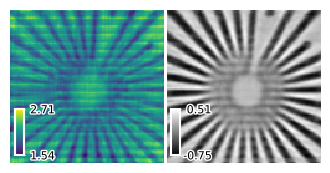

Starting recons for file: tp2
Creating dataset...
Calculating dataset length with coordinate bounds...
For file ../../data/pinn_velo_gold_tp_2/nxs_data_gold_tp_2_64_train.npz, maximum x_range is (33.47206497192383, 566.5279541015625), yrange is (33.47703552246094, 630.52294921875)
Creating memory mapped tensor dictionary...
Memory map length: 5931
Memory map creation time: 0.0007646083831787109
Populating memory map for dataset 0
Start - end = 5931
grouping
4_quadrant
Building KDTree for 7709 points...
Processing 5931 potential central points...
Finished quadrant neighbor processing. Found 5931 valid C=4 groups.
Non-diffraction memory map write time: 0.3807981014251709
Getting normalization coefficients...
Normalize is Batch
Batch rms factor is tensor([[[[0.0031]]]])
Diffraction memory map write time: 0.18515634536743164
[PtychoDataset Rank 0] Initialization successful. Dataset length: 5931.
Beginning reconstruction...
Reconstructing image...
Batch 0 completed in 0.24789643287658691 se

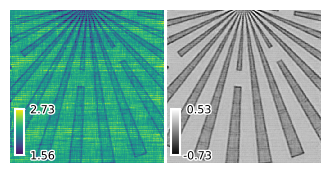

Starting recons for file: ic1
Creating dataset...
Calculating dataset length with coordinate bounds...
For file ../../data/pinn_velo_ic_1/nxs_data_ic_1_64_train.npz, maximum x_range is (33.129241943359375, 170.87075805664062), yrange is (33.0966911315918, 165.90330505371094)
Creating memory mapped tensor dictionary...
Memory map length: 779
Memory map creation time: 0.0007424354553222656
Populating memory map for dataset 0
Start - end = 779
grouping
4_quadrant
Building KDTree for 1143 points...
Processing 779 potential central points...
Finished quadrant neighbor processing. Found 779 valid C=4 groups.
Non-diffraction memory map write time: 0.05717277526855469
Getting normalization coefficients...
Normalize is Batch
Batch rms factor is tensor([[[[0.0032]]]])
Diffraction memory map write time: 0.02479076385498047
[PtychoDataset Rank 0] Initialization successful. Dataset length: 779.
Beginning reconstruction...
Reconstructing image...
Batch 0 completed in 0.1485598087310791 seconds
Batch

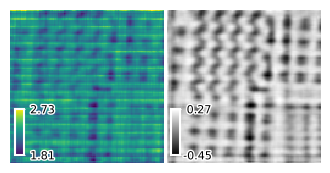

Starting recons for file: ic2
Creating dataset...
Calculating dataset length with coordinate bounds...
For file ../../data/pinn_velo_ic_2/nxs_data_ic_2_64_train.npz, maximum x_range is (33.003055572509766, 434.9969482421875), yrange is (33.472206115722656, 431.5278015136719)
Creating memory mapped tensor dictionary...
Memory map length: 7591
Memory map creation time: 0.0007402896881103516
Populating memory map for dataset 0
Start - end = 7591
grouping
4_quadrant
Building KDTree for 9436 points...
Processing 7591 potential central points...
Finished quadrant neighbor processing. Found 7591 valid C=4 groups.
Non-diffraction memory map write time: 0.5046002864837646
Getting normalization coefficients...
Normalize is Batch
Batch rms factor is tensor([[[[0.0032]]]])
Diffraction memory map write time: 0.22606801986694336
[PtychoDataset Rank 0] Initialization successful. Dataset length: 7591.
Beginning reconstruction...
Reconstructing image...
Batch 0 completed in 0.19495654106140137 seconds


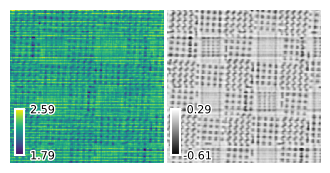

Starting recons for file: lfp
Creating dataset...
Calculating dataset length with coordinate bounds...
For file ../../data/pinn_cosmic_micro_lfp/microLFPstack_single_exposure_64_train.npz, maximum x_range is (33.45436096191406, 144.54563903808594), yrange is (33.45436096191406, 144.54563903808594)
Creating memory mapped tensor dictionary...
Memory map length: 4489
Memory map creation time: 0.0007710456848144531
Populating memory map for dataset 0
Start - end = 4489
grouping
4_quadrant
Building KDTree for 5625 points...
Processing 4489 potential central points...
Finished quadrant neighbor processing. Found 4489 valid C=4 groups.
Non-diffraction memory map write time: 0.4037623405456543
Getting normalization coefficients...
Normalize is Batch
Batch rms factor is tensor([[[[0.0060]]]])
Diffraction memory map write time: 0.13075494766235352
[PtychoDataset Rank 0] Initialization successful. Dataset length: 4489.
Beginning reconstruction...
Reconstructing image...
Batch 0 completed in 0.146

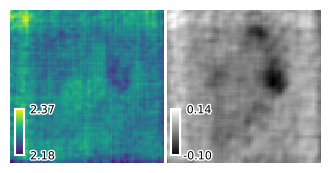

Starting recons for file: ncm
Creating dataset...
Calculating dataset length with coordinate bounds...
For file ../../data/pinn_velo_ncm/nxs_data_ncm_1_64_train.npz, maximum x_range is (33.11264419555664, 240.88735961914062), yrange is (33.431095123291016, 232.56890869140625)
Creating memory mapped tensor dictionary...
Memory map length: 1902
Memory map creation time: 0.0007531642913818359
Populating memory map for dataset 0
Start - end = 1902
grouping
4_quadrant
Building KDTree for 2466 points...
Processing 1902 potential central points...
Finished quadrant neighbor processing. Found 1902 valid C=4 groups.
Non-diffraction memory map write time: 0.1492934226989746
Getting normalization coefficients...
Normalize is Batch
Batch rms factor is tensor([[[[0.0012]]]])
Diffraction memory map write time: 0.0579073429107666
[PtychoDataset Rank 0] Initialization successful. Dataset length: 1902.
Beginning reconstruction...
Reconstructing image...
Batch 0 completed in 0.1574704647064209 seconds
B

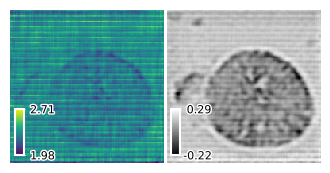

In [24]:
plot_all_objects('../../manuscript_figures/Figure_2_comparison/All_comparisons',
                 model_name_dict, file_name_dict, model_dict)

### 2b. Getting close-up views of gold_tp_2 and ic_2

In [131]:
gt, recon = generate_gt_and_recon('../../data/pinn_velo_ic_2', 'pinn_velo_gold_tp_2_exp', model_dict)

amp, phase = np.abs(recon), np.angle(recon)

Creating dataset...
Calculating dataset length with coordinate bounds...
For file ../../data/pinn_velo_ic_2/nxs_data_ic_2_64_train.npz, maximum x_range is (33.003055572509766, 434.9969482421875), yrange is (33.472206115722656, 431.5278015136719)
Creating memory mapped tensor dictionary...
Memory map length: 7591
Memory map creation time: 0.0008025169372558594
Populating memory map for dataset 0
Start - end = 7591
grouping
4_quadrant
Building KDTree for 9436 points...
Processing 7591 potential central points...
Finished quadrant neighbor processing. Found 7591 valid C=4 groups.
Non-diffraction memory map write time: 0.504286527633667
Getting normalization coefficients...
Batch rms factor is tensor([[[[0.0032]]]])
Diffraction memory map write time: 0.24067425727844238
[PtychoDataset Rank 0] Initialization successful. Dataset length: 7591.
Beginning reconstruction...
Reconstructing image...
Batch 0 completed in 0.19524288177490234 seconds
Batch 1 completed in 0.19142603874206543 seconds
B

Image saved as ../../manuscript_figures/Figure_2_comparison/ptychopinn_zoomed_gold_tp_2.svg


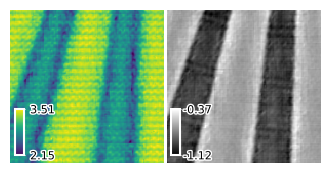

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7f7c454e5c90>)

In [117]:
#Gold_tp_2
half = recon.shape[0]//2
full_save_name = "ptychopinn_zoomed_gold_tp_2"
size = 150
y_offset = 30
x_offset = -60
plot_object(recon[half+y_offset:half+y_offset+size, half+x_offset-size//2:half+x_offset+size//2],
            save_path = '../../manuscript_figures/Figure_2_comparison',
            save_name = full_save_name)

Image saved as ../../manuscript_figures/Figure_2_comparison/ground_truth_zoomed_gold_tp_2.svg


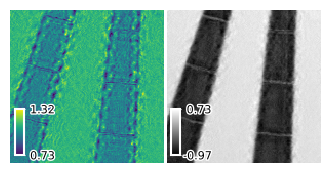

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7f7c4520d180>)

In [118]:
#Gold_tp_2 ground truth
half = gt.shape[0]//2
full_save_name = "ground_truth_zoomed_gold_tp_2"
size = 150
y_offset = 30
x_offset = -60
plot_object(gt[half+y_offset:half+y_offset+size, half+x_offset-size//2:half+x_offset+size//2],
            save_path = '../../manuscript_figures/Figure_2_comparison',
            save_name = full_save_name)

Image saved as ../../manuscript_figures/Figure_2_comparison/ptychopinn_exp_zoomed_ic_2.svg


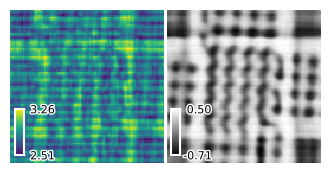

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7f7c447bc910>)

In [132]:
#Ic_2
half = recon.shape[0]//2
full_save_name = "ptychopinn_exp_zoomed_ic_2"
size = 130
y_offset = -95
x_offset = -10
plot_object(recon[half+y_offset:half+y_offset+size, half+x_offset-size//2:half+x_offset+size//2],
            save_path = '../../manuscript_figures/Figure_2_comparison',
            save_name = full_save_name)

Image saved as ../../manuscript_figures/Figure_2_comparison/ground_truth_zoomed_ic_2.svg


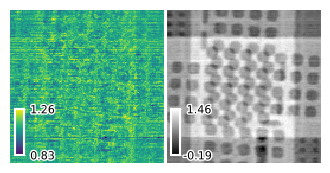

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7f7c448b8730>)

In [130]:
#Ic_2
half = gt.shape[0]//2
full_save_name = "ground_truth_zoomed_ic_2"
size = 130
y_offset = -95
x_offset = -10
plot_object(gt[half+y_offset:half+y_offset+size, half+x_offset-size//2:half+x_offset+size//2],
            save_path = '../../manuscript_figures/Figure_2_comparison',
            save_name = full_save_name)

### 2c. FRC curves

In [8]:
from scipy.signal import savgol_filter

In [44]:
frc_path = '../../data/frc_results/frc_results.npz'
# Load the frc_dict from the npz file
frc_dict = np.load(frc_path, allow_pickle=True)['frc_dict'].item()

#### Helper Functions

In [10]:
# For a given key in frc_dict and experiment name, assign x_FR, FR_curve and FR_AUC to numpy arrays. Concatenate them along the first axis.

def get_frc_arrays(frc_dict, exp_name):
    """
    Gets the FRC arrays for a given experiment name and model name from the frc_dict.
    Args:
        frc_dict (dict): Dictionary containing FRC results.
        exp_name (str): Experiment name.
        model_name (str): Model name.
    Returns:
        tuple: x_FR, FR_curve, FR_AUC as numpy arrays.
    """

    x_FR = []
    FR_curve = []
    FR_AUC = []
    model_list = list(frc_dict[exp_name].keys())  # Get the first model name for the experiment

    for model_name in frc_dict[exp_name].keys():
        x_FR.append(frc_dict[exp_name][model_name]['x_FR'])
        FR_curve.append(frc_dict[exp_name][model_name]['FR_curve'])
        FR_AUC.append(frc_dict[exp_name][model_name]['FR_AUC'])

    return x_FR, FR_curve, FR_AUC, model_list

In [11]:
def calculate_threshold_frc(x_FR):
    """
    Calculates the threshold FRC curve based on the x_FR array.
    Args:
        x_FR (list): List of x_FR arrays for different models.
    Returns:
        x_T, T_curve (tuple): Threshold FRC values and corresponding frequencies.
    """
    # Calculate threshold FRC curve (taken from eval_metrics.py)
    SNRt = 0.2071 #half bit threshold
    eps = np.finfo(float).eps
    r = np.arange(1+x_FR.shape[0]/2)
    n = 2*np.pi*r
    n[0] = 1
    t1 = np.divide(np.ones(np.shape(n)),n+eps)
    t2 = SNRt + 2*np.sqrt(SNRt)*t1 + np.divide(np.ones(np.shape(n)),np.sqrt(n))
    t3 = SNRt + 2*np.sqrt(SNRt)*t1 + 1
    T_curve = np.divide(t2,t3)
    x_T = r/(x_FR.shape[0]/2)

    return x_T, T_curve

In [12]:
def plot_frc_curves(frc_dict, exp_name, experiment_substrings, 
                   model_colors=None, model_styles=None, plot_names=None,
                   model_linewidths=None, model_alphas=None, model_priority=None,
                   save_path = None, save_name = 'Default'):
    """
    Plots the FRC curves for a given experiment name with customizable styling and order.
    Args:
        frc_dict (dict): Dictionary containing FRC results.
        exp_name (str): Experiment name.
        experiment_substrings (list): List of model substrings to include.
        model_colors (dict, optional): Dictionary mapping model names to colors.
        model_styles (dict, optional): Dictionary mapping model names to line styles.
        plot_names (dict, optional): Dictionary mapping model names to display names.
        model_linewidths (dict, optional): Dictionary mapping model names to line widths.
        model_alphas (dict, optional): Dictionary mapping model names to alpha transparency values.
        model_priority (dict, optional): Dictionary mapping model names to priority order (lower numbers plot first/behind).
    """
    from scipy.signal import savgol_filter
    
    x_FR, FR_curve, FR_AUC, model_name = get_frc_arrays(frc_dict, exp_name)

    # Generate figure
    fig = plt.figure(figsize=(5,3))
    fig.patch.set_alpha(0)

    # Filter and collect models that match experiment substrings
    models_to_plot = []
    for i, model in enumerate(model_name):
        if any(substrings in model for substrings in experiment_substrings):
            models_to_plot.append((i, model))
    
    # Sort by priority if provided
    if model_priority:
        models_to_plot.sort(key=lambda x: model_priority.get(x[1], float('inf')))

    # Plot models in priority order
    for i, model in models_to_plot:
        x_FR_i, FR_curve_i, FR_AUC_i = x_FR[i], FR_curve[i], FR_AUC[i]
        
        # Get styling parameters
        color = model_colors.get(model, None) if model_colors else None
        linestyle = model_styles.get(model, '-') if model_styles else '-'
        linewidth = model_linewidths.get(model, 1.0) if model_linewidths else 1.0
        alpha = model_alphas.get(model, 1.0) if model_alphas else 1.0
        
        # Get display name
        if plot_names and model in plot_names:
            display_name = plot_names[model]
        else:
            # Fallback to original naming logic
            display_name = '_'.join(model.split('_')[1:])
        
        # Smooth the FRC curve
        window_length = min(11, len(FR_curve_i) if len(FR_curve_i) % 2 == 1 else len(FR_curve_i)-1)
        if window_length < 3:
            window_length = 3
        
        FR_curve_smooth = savgol_filter(FR_curve_i, window_length=window_length, polyorder=2)
        
        # Plot with custom styling
        plt.plot(x_FR_i, FR_curve_smooth, 
                label=display_name,
                color=color,
                linestyle=linestyle,
                linewidth=linewidth,
                alpha=alpha)

    # Plot threshold
    if models_to_plot:  # Only if we have models to plot
        # Use the last model's x_FR for threshold calculation
        x_FR_last = x_FR[models_to_plot[-1][0]]
        x_T, T_curve = calculate_threshold_frc(x_FR_last)
        plt.plot(x_T, T_curve, label='1/2-bit threshold', linestyle='--', color='red')
            
    plt.xlabel('Spatial Frequency (1/pixel)', fontweight = 'bold', fontsize=12)
    plt.ylabel('FRC', fontweight = 'bold', fontsize=12)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()

    
    format = 'svg'
    if save_path:
        full_save_path = os.path.join(save_path, f"{save_name}.{format}")
        plt.savefig(full_save_path, format='svg', dpi=600, 
                   bbox_inches='tight', pad_inches=0, 
                   transparent=True, facecolor='none')
        print(f"Image saved as {full_save_path}")

    plt.show()

### Proceed with plotting

In [13]:

frc_dict['pinn_hxn_cnm'].keys()

dict_keys(['pinn_hxn_cnm_syn', 'pinn_velo_fly001_syn', 'pinn_velo_gold_tp_1_syn', 'pinn_velo_gold_tp_2_syn', 'pinn_velo_ic_1_syn', 'pinn_velo_ic_2_syn', 'pinn_velo_ncm_syn', 'pinn_hxn_cnm_exp', 'pinn_velo_fly001_exp', 'pinn_velo_gold_tp_1_exp', 'pinn_velo_gold_tp_2_exp', 'pinn_velo_ic_1_exp', 'pinn_velo_ic_2_exp', 'pinn_velo_ncm_exp', 'pinn_cosmic_micro_lfp_syn', 'pinn_cosmic_micro_lfp_exp'])

Image saved as ../../manuscript_figures/Figure_2_comparison/ic_2_frc_comparison.svg


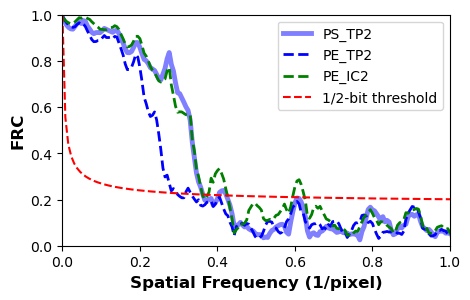

In [14]:
# Your existing definitions
exp_name = 'pinn_velo_ic_2'
save_path = '../../manuscript_figures/Figure_2_comparison'
full_save_name = 'ic_2_frc_comparison'

model_substrings = ['pinn_velo_gold_tp_2_exp',
                    'pinn_velo_ic_2_exp',
                    'pinn_velo_gold_tp_2_syn',
                    'pinn_velo_gold_tp_2_supervised']

model_colors = {
    'pinn_velo_gold_tp_2_exp': 'blue',
    'pinn_velo_ic_2_exp': 'green',
    'pinn_velo_gold_tp_2_syn': 'blue',
    'pinn_velo_gold_tp_2_supervised': "#787575"
}

model_styles = {
    'pinn_velo_gold_tp_2_exp': '--',
    'pinn_velo_ic_2_exp': '--',
    'pinn_velo_gold_tp_2_syn': '-',
    'pinn_velo_gold_tp_2_supervised': '-'
}

plot_names = {
    'pinn_velo_gold_tp_2_exp': 'PE_TP2',
    'pinn_velo_ic_2_exp': 'PE_IC2',
    'pinn_velo_gold_tp_2_syn': 'PS_TP2',
    'pinn_velo_gold_tp_2_supervised': 'SS_TP2'
}

# New styling dictionaries
model_linewidths = {
    'pinn_velo_gold_tp_2_exp': 2.0,
    'pinn_velo_ic_2_exp': 2.0,
    'pinn_velo_gold_tp_2_syn': 3.5,
    'pinn_velo_gold_tp_2_supervised': 2.0
}

model_alphas = {
    'pinn_velo_gold_tp_2_exp': 1.0,
    'pinn_velo_ic_2_exp': 1.0,
    'pinn_velo_gold_tp_2_syn': 0.5,
    'pinn_velo_gold_tp_2_supervised': 1.0
}

model_priority = {
    'pinn_velo_gold_tp_2_supervised': 4,  # Plot first (behind others)
    'pinn_velo_gold_tp_2_syn': 1,         # Plot second
    'pinn_velo_gold_tp_2_exp': 2,         # Plot third
    'pinn_velo_ic_2_exp': 3               # Plot last (on top)
}

# Call with all styling dictionaries
plot_frc_curves(frc_dict, exp_name, model_substrings, 
                model_colors, model_styles, plot_names,
                model_linewidths, model_alphas, model_priority,
                save_path, full_save_name)

In [245]:
# Calculating FRC_AUC values at 0.5 to display in Illustrator

pps_gold_tp_2 = frc_dict['pinn_velo_ic_2']['pinn_velo_gold_tp_2_syn']['FR_AUC_0.5']
ppe_gold_tp_2 = frc_dict['pinn_velo_ic_2']['pinn_velo_gold_tp_2_exp']['FR_AUC_0.5']
ppe_ic_2 = frc_dict['pinn_velo_ic_2']['pinn_velo_ic_2_exp']['FR_AUC_0.5']
ss_gold_tp_2 = frc_dict['pinn_velo_ic_2']['pinn_velo_gold_tp_2_supervised']['FR_AUC_0.5']

print(f"PPS TP 2: {round(pps_gold_tp_2,2)} \
        PPE TP 2: {round(ppe_gold_tp_2,2)},\
        PPE IC 2: {round(ppe_ic_2,2)},\
        SS TP 2: {round(ss_gold_tp_2,2)}")




PPS TP 2: 0.62         PPE TP 2: 0.51,        PPE IC 2: 0.64,        SS TP 2: 0.2


# Table 1. FRC AUC results (quantitative)

### Need to recalculate all FRC-AUC scores in the table since they were going all the way to 1



In [41]:
frc_dict['pinn_hxn_cnm']['pinn_hxn_cnm_syn'].keys()

dict_keys(['x_FR', 'FR_curve', 'FR_AUC', 'window_size', 'FR_AUC_0.5'])

In [39]:
def calculate_frc_auc(frc_dict):
    for exp_name in frc_dict.keys():
        for model_name in frc_dict[exp_name].keys():
            #Get curve characteristics and recalculate FR_AUC
            x_FR = frc_dict[exp_name][model_name]['x_FR']
            FR_curve = frc_dict[exp_name][model_name]['FR_curve']
            # Calculate sum under curve until 0.5, normalized by total theoretical area
            FR_AUC = np.sum(FR_curve[:np.where(x_FR - 0.5 > 0)[0][0]])/np.where(x_FR - 0.5 > 0)[0][0]
            frc_dict[exp_name][model_name]['FR_AUC_0.5'] = FR_AUC
            

In [40]:
calculate_frc_auc(frc_dict)

### Generate automatic latex table with results

In [ ]:
def generate_frc_latex_table(frc_dict, model_display_names=None, experiment_display_names=None):
    """
    Generates a LaTeX table comparing FRC_AUC values across experiments and models.
    Sorts to create diagonal pattern where models align with their corresponding experiments.
    """
    
    # Get all unique experiments and models
    experiments = list(frc_dict.keys())
    all_models = set()
    for exp_data in frc_dict.values():
        all_models.update(exp_data.keys())
    models = list(all_models)
    
    # Extract dataset names for sorting - need to get the meaningful part
    def extract_dataset_name(key):
        # Remove suffixes first
        clean_key = key.replace('_supervised', '').replace('_syn', '').replace('_exp', '')
        parts = clean_key.split('_')
        
        # Handle different patterns
        if 'gold_tp' in clean_key:
            return f"tp_{parts[-1]}"  # tp_1, tp_2
        elif '_ic_' in clean_key:
            return f"ic_{parts[-1]}"  # ic_1, ic_2
        elif 'micro_lfp' in clean_key:
            return "lfp"
        else:
            return parts[-1]  # cnm, fly001, ncm, etc.
    
    # Sort experiments by dataset name
    experiments.sort(key=extract_dataset_name)
    
    # Sort models: group by dataset, then by model type within each dataset
    def model_sort_key(model):
        dataset = extract_dataset_name(model)
        # Determine model type priority: exp=1, syn=2, supervised=3
        if '_exp' in model:
            type_priority = 1
        elif '_syn' in model:
            type_priority = 2
        elif '_supervised' in model:
            type_priority = 3
        else:
            type_priority = 4
        return (dataset, type_priority)
    
    models.sort(key=model_sort_key)
    
    # Create display names if not provided
    if model_display_names is None:
        model_display_names = {model: model for model in models}
    if experiment_display_names is None:
        experiment_display_names = {exp: exp for exp in experiments}
    
    # Start building LaTeX table
    n_cols = len(experiments) + 1  # +1 for model names column
    latex_table = []
    
    # Table header
    latex_table.append("\\begin{table}[htbp]")
    latex_table.append("\\centering")
    latex_table.append("\\caption{FRC AUC Comparison Across Experiments}")
    latex_table.append("\\label{tab:frc_comparison}")
    latex_table.append(f"\\begin{{tabular}}{{l{'c' * len(experiments)}}}")
    latex_table.append("\\toprule")
    
    # Column headers
    header_row = "Model"
    for exp in experiments:
        exp_display = experiment_display_names.get(exp, exp)
        header_row += f" & {exp_display}"
    header_row += " \\\\"
    latex_table.append(header_row)
    latex_table.append("\\midrule")
    
    # Data rows
    for model in models:
        model_display = model_display_names.get(model, model)
        row = model_display
        
        for exp in experiments:
            if exp in frc_dict and model in frc_dict[exp]:
                frc_auc = frc_dict[exp][model].get('FR_AUC_0.5', 'N/A')
                if isinstance(frc_auc, (int, float)):
                    row += f" & {frc_auc:.3f}"
                else:
                    row += f" & {frc_auc}"
            else:
                row += " & --"
        
        row += " \\\\"
        latex_table.append(row)
    
    # Table footer
    latex_table.append("\\bottomrule")
    latex_table.append("\\end{tabular}")
    latex_table.append("\\end{table}")
    
    return "\n".join(latex_table)

# Usage example:
model_names = {
    'pinn_hxn_cnm_syn': 'PPS - CNM',
    'pinn_velo_fly001_syn': 'PPS - FLY001',
    'pinn_velo_gold_tp_1_syn': 'PPS - TP\\_1',
    'pinn_velo_gold_tp_2_syn': 'PPS - TP\\_2',
    'pinn_velo_ic_1_syn': 'PPS - IC\\_1',
    'pinn_velo_ic_2_syn': 'PPS - IC\\_2',
    'pinn_cosmic_micro_lfp_syn': 'PPS - LFP',
    'pinn_velo_ncm_syn': 'PPS - NCM',
    'pinn_hxn_cnm_exp': 'PPE - CNM',
    'pinn_velo_fly001_exp': 'PPE - FLY001',
    'pinn_velo_gold_tp_1_exp': 'PPE - TP\\_1',
    'pinn_velo_gold_tp_2_exp': 'PPE - TP\\_2',
    'pinn_velo_ic_1_exp': 'PPE - IC\\_1',
    'pinn_velo_ic_2_exp': 'PPE - IC\\_2',
    'pinn_velo_ncm_exp': 'PPE - NCM',
    'pinn_cosmic_micro_lfp_exp': 'PPE - LFP',
    'pinn_velo_gold_tp_2_supervised': 'SS - TP\\_2'
}


experiment_names = {
    'pinn_hxn_cnm': 'CNM',
    'pinn_velo_fly001': 'FLY001',
    'pinn_velo_als_ns': 'ALS\\_NS',
    'pinn_velo_gold_tp_1': 'TP\\_1',
    'pinn_velo_gold_tp_2': 'TP\\_2',
    'pinn_velo_ic_1': 'IC\\_1',
    'pinn_velo_ic_2': 'IC\\_2',
    'pinn_cosmic_micro_lfp': 'LFP',
    'pinn_velo_ncm': 'NCM'
}

latex_code = generate_frc_latex_table(frc_dict, model_names, experiment_names)
print(latex_code)

\begin{table}[htbp]
\centering
\caption{FRC AUC Comparison Across Experiments}
\label{tab:frc_comparison}
\begin{tabular}{lcccccccc}
\toprule
Model & CNM & FLY001 & IC\_1 & IC\_2 & LFP & NCM & TP\_1 & TP\_2 \\
\midrule
PPE - CNM & 0.744 & 0.267 & 0.373 & 0.329 & 0.289 & 0.224 & 0.309 & 0.267 \\
PPS - CNM & 0.655 & 0.337 & 0.344 & 0.297 & 0.268 & 0.238 & 0.272 & 0.224 \\
PPE - FLY001 & 0.328 & 0.521 & 0.423 & 0.413 & 0.286 & 0.265 & 0.477 & 0.316 \\
PPS - FLY001 & 0.368 & 0.489 & 0.386 & 0.355 & 0.275 & 0.242 & 0.295 & 0.240 \\
PPE - IC\_1 & 0.234 & 0.275 & 0.307 & 0.271 & 0.310 & 0.219 & 0.275 & 0.108 \\
PPS - IC\_1 & 0.376 & 0.397 & 0.638 & 0.607 & 0.309 & 0.326 & 0.435 & 0.578 \\
PPE - IC\_2 & 0.301 & 0.352 & 0.607 & 0.638 & 0.318 & 0.317 & 0.543 & 0.510 \\
PPS - IC\_2 & 0.357 & 0.370 & 0.599 & 0.597 & 0.321 & 0.298 & 0.421 & 0.557 \\
PPE - LFP & 0.224 & 0.291 & 0.353 & 0.308 & 0.592 & 0.213 & 0.290 & 0.160 \\
PPS - LFP & 0.404 & 0.296 & 0.262 & 0.211 & 0.425 & 0.176 & 0.229 & 0.106 

# Figure 3. General synthetic model performance as function of probe

This set of figures will demonstrate the power of probe similarity in the synthetic model training schema.

1. We include general bar charts showing that synthetic models with similar probes perform very similarly in FRC_AUC.
2. Additionally, we will show a probe "dilution" FRC chart showing the model's capability of learning multiple probes simultaneously. Might need to run new experiment with all three probes to show that the performance diminishes but is much above the baseline. (could be bar chart)
3. Lastly we can show a probe similarity heatmap (might need logarithm cuz the subset of velociprobes are highly similar)

### 3. Creating schematics for arbitrary probability density functions

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, hex2color
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata

In [125]:
def create_contour_map(seed=42, 
                      grid_size=100, 
                      n_levels=10,
                      colormap=None,
                      boundary_complexity=0.3,
                      smooth_factor=2.0,
                      figsize=(8, 6),
                      alpha=0.8,
                      line_color="#4a7da3"):
    """
    Create a contour map with customizable parameters and deterministic curved boundaries.
    
    Parameters:
    -----------
    seed : int
        Random seed for reproducible results
    grid_size : int
        Size of the grid (grid_size x grid_size)
    n_levels : int
        Number of contour levels
    colormap : str or matplotlib colormap
        Color mapping for the contours (ignored - uses BuPu)
    boundary_complexity : float
        Controls how curved/complex the boundary is (0.1-1.0)
    smooth_factor : float
        Gaussian smoothing factor for the data
    figsize : tuple
        Figure size (width, height)
    alpha : float
        Overall transparency for the entire contour map (0.0 = transparent, 1.0 = opaque)
    line_color : str
        Starting color for contour lines (darkest/highest magnitude), fades to white at edges
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    
    # Set random seed for reproducibility
    np.random.seed(seed)
    
    # Create coordinate grids
    x = np.linspace(-2, 2, grid_size)
    y = np.linspace(-2, 2, grid_size)
    X, Y = np.meshgrid(x, y)
    
    # Create base probability distribution (can be customized)
    # Using a combination of Gaussian peaks
    Z = np.zeros_like(X)
    
    # Add multiple Gaussian peaks with random positions and amplitudes
    # Ensure contours stay within frame by clustering near center
    n_peaks = int(3 + boundary_complexity * 5)  # More peaks = more complex boundary
    
    for i in range(n_peaks):
        # Center-biased random positions with asymmetry
        # Use beta distribution to bias towards center but allow asymmetry
        cx_raw = np.random.beta(2, 2) * 2 - 1  # Beta(2,2) gives center bias
        cy_raw = np.random.beta(2, 2) * 2 - 1  
        
        # Add slight asymmetric offset to break perfect symmetry
        asymmetry_x = np.random.uniform(-0.3, 0.5)  # Slight rightward bias
        asymmetry_y = np.random.uniform(-0.2, 0.3)  # Slight upward bias
        
        cx = np.clip(cx_raw + asymmetry_x, -1.2, 1.2)
        cy = np.clip(cy_raw + asymmetry_y, -1.2, 1.2)
        
        # Distance from center affects amplitude and width
        distance_from_center = np.sqrt(cx**2 + cy**2)
        
        # Closer to center = larger amplitude, further = smaller amplitude
        max_amplitude = 1.0 - 0.3 * distance_from_center
        amplitude = np.random.uniform(0.4 * max_amplitude, max_amplitude)
        
        # Width inversely related to distance from center
        # Further peaks have smaller widths to prevent edge spillover
        base_width = 1.2 - 0.4 * distance_from_center
        width_x = np.random.uniform(0.3, base_width)
        width_y = np.random.uniform(0.3, base_width)
        
        # Add Gaussian peak
        Z += amplitude * np.exp(-((X - cx)**2 / (2 * width_x**2) + 
                                 (Y - cy)**2 / (2 * width_y**2)))
    
    # Add some noise for more irregular boundaries
    noise_amplitude = boundary_complexity * 0.2
    Z += np.random.normal(0, noise_amplitude, Z.shape)
    
    # Apply Gaussian smoothing
    Z = gaussian_filter(Z, sigma=smooth_factor)
    
    # Normalize to create a proper probability-like distribution
    Z = (Z - Z.min()) / (Z.max() - Z.min())
    
    # Use BuPu colormap (Blue-Purple)
    blue_cmap = plt.cm.Blues
    
    # Create the figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create contour levels, excluding the minimum to make lowest level transparent
    # Start from a higher threshold to ensure only actual contours are visible
    threshold = Z.min() + (Z.max() - Z.min()) * 0.2  # Start at 20% above minimum
    levels = np.linspace(threshold, Z.max(), n_levels)
    
    # Create filled contours with BuPu colormap and alpha, but don't extend to minimum
    contourf = ax.contourf(X, Y, Z, levels=levels, cmap=blue_cmap, alpha=alpha)
    
    # Create custom gradient for contour lines from white to specified color
    line_rgb = hex2color(line_color)
    
    # Create individual contour lines with gradient colors
    for i, level in enumerate(levels):
        # Calculate gradient factor (0 = white, 1 = full color)
        gradient_factor = i / (len(levels) - 1) if len(levels) > 1 else 1
        
        # Interpolate between white (1,1,1) and specified color
        current_color = tuple(
            (1 - gradient_factor) * 1.0 + gradient_factor * line_rgb[j] 
            for j in range(3)
        )
        
        # Draw contour line for this level
        ax.contour(X, Y, Z, levels=[level], colors=[current_color], 
                  linewidths=0.8, alpha=0.8)
    
    # Remove all axes elements
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('')
    ax.set_aspect('equal')
    
    # Remove axes spines
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    return fig, ax, Z

In [ ]:
seed_number = 20

for i in range(20,52):

    fig, ax, data = create_contour_map(seed=i, n_levels = 12, boundary_complexity=0.1, alpha = 0.6,
                                    line_color = "#234c6b")

    contour_map_name = str(i) + "contour_map.svg"
    plt.savefig('../../manuscript_figures/Figure_3_comparison/contour_maps/' + contour_map_name, 
                bbox_inches='tight',
                transparent=True,
                format='svg')
    
# plt.show()





### 3. Supplemental Bar Charts for single_trained performance

#### Helper functions

In [45]:
def plot_frc_bar_chart(frc_dict, experiment_key, model_display_names=None, 
                      bar_colors=None, text_colors=None, 
                      figsize=(12, 6), save_path=None, save_name='frc_bar_chart'):
    """
    Creates a bar chart of FR_AUC_0.5 values for models in a given experiment.
    
    Args:
        frc_dict (dict): Nested dictionary with structure: experiment -> model -> metrics
        experiment_key (str): The experiment to plot
        model_display_names (dict, optional): Mapping of model keys to display names
        bar_colors (dict, optional): Mapping of model keys to bar colors
        text_colors (dict, optional): Mapping of model keys to text colors
        figsize (tuple): Figure size
        save_path (str, optional): Path to save figure
        save_name (str): Name for saved figure
    """
    
    # Extract FR_AUC_0.5 values for the given experiment
    if experiment_key not in frc_dict:
        raise ValueError(f"Experiment '{experiment_key}' not found in frc_dict")
    
    exp_data = frc_dict[experiment_key]
    
    # Get FR_AUC_0.5 values and model names
    model_scores = []
    for model, metrics in exp_data.items():
        # Only include models thata are to be plotted
        if model in model_display_names.keys():
            if 'FR_AUC_0.5' in metrics:
                model_scores.append((model, metrics['FR_AUC_0.5']))
    
    if not model_scores:
        raise ValueError(f"No FR_AUC_0.5 data found for experiment '{experiment_key}'")
    
    # Sort by FR_AUC_0.5 values in descending order (highest on right)
    model_scores.sort(key=lambda x: x[1], reverse=True)
    
    # Separate models and scores
    models = [item[0] for item in model_scores]
    scores = [item[1] for item in model_scores]

    max_score = max(scores)
    
    # Get display names
    if model_display_names is None:
        model_display_names = {model: model for model in models}
    
    display_names = [model_display_names.get(model, model) for model in models]
    
    # Set up colors
    default_bar_color = '#1f77b4'
    default_text_color = 'white'
    
    bar_color_list = []
    text_color_list = []
    
    for model in models:
        bar_color_list.append(bar_colors.get(model, default_bar_color) if bar_colors else default_bar_color)
        text_color_list.append(text_colors.get(model, default_text_color) if text_colors else default_text_color)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize, dpi = 300)
    fig.patch.set_alpha(0)
    
    # Create bars
    x_pos = np.arange(len(models))
    bars = ax.bar(x_pos, scores, color=bar_color_list,
                  width=0.8, edgecolor='black', linewidth=0.7)
    
    # Add text labels on bars (rotated 90 degrees counter-clockwise)
    for i, (bar, name, text_color) in enumerate(zip(bars, display_names, text_color_list)):
        height = bar.get_height()
        if height < 0.42 * max_score:
            height += 0.03
        else:
            height = 0.01
        ax.text(bar.get_x() + bar.get_width()/2. + 0.1, height,
                name, ha='center', va='bottom',
                fontsize = 6.5, rotation=90, color=text_color)
    
    # Remove x-axis ticks since we have text on bars
    ax.set_xticks([])
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)
    
    # Adjust layout
    plt.tight_layout()

    
    # Save if requested
    if save_path:
        full_save_path = f"{save_path}/{save_name}.svg"
        plt.savefig(full_save_path, format = 'svg', dpi=300,
                    bbox_inches='tight', pad_inches = 0,
                    transparent = True, facecolor = 'none')
        print(f"Figure saved as {full_save_path}")

    plt.show()



In [46]:
# Dictionary Definitions

# Define color palette
color_palette = [
    # Primary colors
    "#17AB17",  # Forest Green (primary green)
    "#E28206",  # Crimson Red (primary red)  
    'black',  # Dark Slate (primary black/dark)
    "#EB0606",  # Goldenrod (primary yellow)
    
    # Secondary colors (similar but distinct)
    '#66CDAA',  # Medium Aquamarine (secondary green - lighter, more blue)
    '#F08080',  # Light Coral (secondary red - lighter, more pink)
    '#708090',  # Slate Gray (secondary black - lighter gray)
    '#F0E68C',  # Khaki (secondary yellow - lighter, more muted)
]

# Define colors for different model types
bar_colors = {
    #CNM syn
    'pinn_hxn_cnm_syn': color_palette[0],
    'pinn_hxn_cnm_exp': color_palette[0],
    #Fly001 syn
    'pinn_velo_fly001_syn': color_palette[1],
    'pinn_velo_fly001_exp': color_palette[1],
    #Other velo synthetic
    'pinn_velo_gold_tp_1_syn': color_palette[2],
    'pinn_velo_gold_tp_2_syn': color_palette[2],
    'pinn_velo_ic_1_syn': color_palette[2],
    'pinn_velo_ic_2_syn': color_palette[2],
    'pinn_velo_ncm_syn': color_palette[2],
    #Other velo exp
    'pinn_velo_gold_tp_1_exp': color_palette[6],
    'pinn_velo_gold_tp_2_exp': color_palette[6],
    'pinn_velo_ic_1_exp': color_palette[6],
    'pinn_velo_ic_2_exp': color_palette[6],
    'pinn_velo_ncm_exp': color_palette[6],
    #Micro exp
    'pinn_cosmic_micro_lfp_exp': color_palette[3],
    #Micro syn
    'pinn_cosmic_micro_lfp_syn': color_palette[3],
}

text_colors = {
    #CNM syn - Teal background (#66C2A5) - medium brightness
    'pinn_hxn_cnm_syn': 'black',
    #CNM exp - Salmon background (#FC8D62) - medium brightness  
    'pinn_hxn_cnm_exp': 'black',
    #Fly001 syn - Lavender background (#8DA0CB) - medium brightness
    'pinn_velo_fly001_syn': 'black',
    #Fly001 exp - Pink background (#E78AC3) - medium brightness
    'pinn_velo_fly001_exp': 'black',
    #Other velo synthetic - Light green background (#A6D854) - bright
    'pinn_velo_gold_tp_1_syn': 'white',
    'pinn_velo_gold_tp_2_syn': 'white',
    'pinn_velo_ic_1_syn': 'white',
    'pinn_velo_ic_2_syn': 'white',
    'pinn_velo_ncm_syn': 'white',
    #Other velo exp - Muted yellow background (#FFD92F) - very bright
    'pinn_velo_gold_tp_1_exp': 'black',
    'pinn_velo_gold_tp_2_exp': 'black',
    'pinn_velo_ic_1_exp': 'black',
    'pinn_velo_ic_2_exp': 'black',
    'pinn_velo_ncm_exp': 'black',
    #Micro exp - Tan background (#E5C494) - light
    'pinn_cosmic_micro_lfp_exp': 'black',
    #Micro syn - Dark gray background (#2C3E50) - very dark
    'pinn_cosmic_micro_lfp_syn': 'black',


}

# Use your existing model_display_names dictionary
model_display_names = {
    'pinn_hxn_cnm_syn': 'PS - W',
    'pinn_velo_fly001_syn': 'PS - FLY1',
    'pinn_velo_gold_tp_1_syn': 'PS - TP1',
    'pinn_velo_gold_tp_2_syn': 'PS - TP2',
    'pinn_velo_ic_1_syn': 'PS - IC1',
    'pinn_velo_ic_2_syn': 'PS - IC2',
    'pinn_cosmic_micro_lfp_syn': 'PS - LFP',
    'pinn_velo_ncm_syn': 'PS - NCM',
    'pinn_hxn_cnm_exp': 'PE - W',
    'pinn_velo_fly001_exp': 'PE - FLY1',
    'pinn_velo_gold_tp_1_exp': 'PE - TP1',
    'pinn_velo_gold_tp_2_exp': 'PE - TP2',
    'pinn_velo_ic_1_exp': 'PE - IC1',
    'pinn_velo_ic_2_exp': 'PE - IC2',
    'pinn_velo_ncm_exp': 'PE - NCM',
    'pinn_cosmic_micro_lfp_exp': 'PE - LFP',
}


In [8]:
# Loading frc dict
frc_path = '../../data/frc_results/frc_results.npz'
# Load the frc_dict from the npz file
frc_dict = np.load(frc_path, allow_pickle=True)['frc_dict'].item()

Figure saved as ../../manuscript_figures/Figure_3_comparison/pinn_cosmic_micro_lfp_bar_comparison.svg


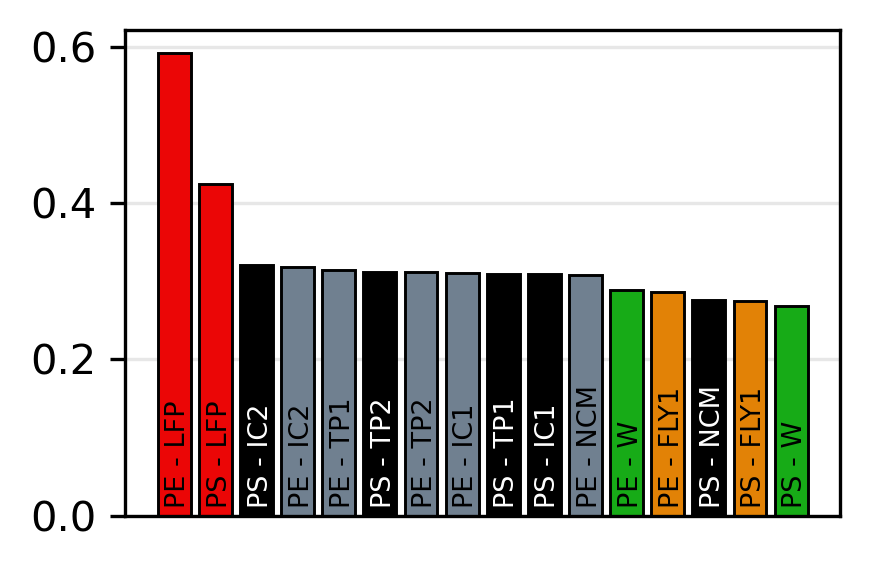

In [54]:
experiment_key = 'pinn_cosmic_micro_lfp'
full_save_name = experiment_key + '_bar_comparison'

plot_frc_bar_chart(frc_dict, experiment_key, model_display_names, 
                  bar_colors, text_colors, figsize = (3,2),
                  save_path = '../../manuscript_figures/Figure_3_comparison',
                  save_name = full_save_name)

Figure saved as ../../manuscript_figures/Figure_3_comparison/pinn_velo_ic_2_bar_comparison.svg


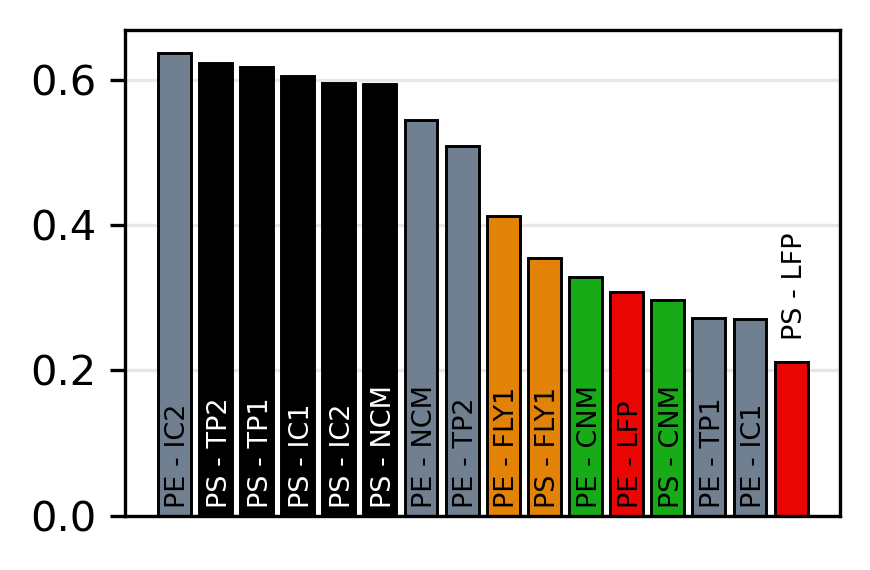

In [12]:
experiment_key = 'pinn_velo_ic_2'
full_save_name = experiment_key + '_bar_comparison'

plot_frc_bar_chart(frc_dict, experiment_key, model_display_names, 
                  bar_colors, text_colors, figsize = (3,2),
                  save_path = '../../manuscript_figures/Figure_3_comparison',
                  save_name = full_save_name)

Figure saved as ../../manuscript_figures/Figure_3_comparison/pinn_hxn_cnm_bar_comparison.svg


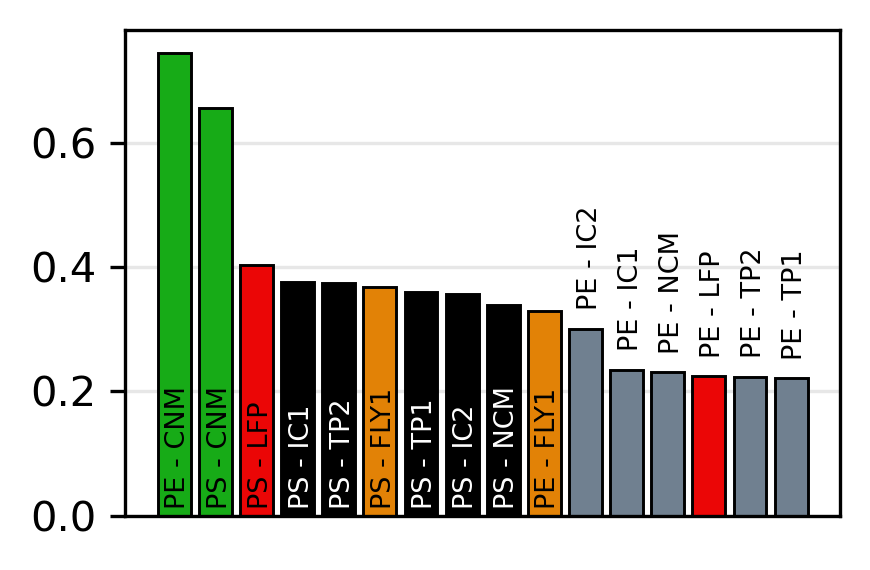

In [19]:
experiment_key = 'pinn_hxn_cnm'
full_save_name = experiment_key + '_bar_comparison'

plot_frc_bar_chart(frc_dict, experiment_key, model_display_names, 
                  bar_colors, text_colors, figsize = (3,2),
                  save_path = '../../manuscript_figures/Figure_3_comparison',
                  save_name = full_save_name)

## 3 a. Getting close-up reconstructions of different models close-up

#### Redefinining the models/experiments needed to calculate.

Run Figure 2, 1a. before this

In [28]:
file_list = ['../../data/pinn_hxn_cnm',
            '../../data/pinn_velo_fly001',
            '../../data/pinn_velo_gold_tp_2',
            '../../data/pinn_cosmic_micro_lfp',
            '../../data/pinn_velo_ic_2'
            ]

model_dict= { #Fine-tuned
    #Synthetic
    'cnm': 'bec5909f8c7d407dbdcdc24357495239',
    'fly1': '9c87bda4384f42a9ad8f7fa0bcc6ea5b',
    'tp2': '5c668cbdb3244e92acd8cb1d682234df',
    'lfp': 'e4a5907f060c4af1adb9005a4fc1c51e',
    #Double
    'tp2_cnm': '92f5a0518ea641adb8a75e02242c390e',
    'tp2_fly1': '40f07429768142c5b4d7b57f5c072862',
    'tp2_lfp': 'f7c72e4058994eea9e9c43ffe7e3b278', #Need to fix properly
    'fly1_cnm': 'cb2e664b3001486ba1047936d0b4a533',#'9af3b6b00ccf4149a7834dea2ca53c06', #'e468c7ebb115444283df1db69f29e512',
    'fly1_lfp': 'bc649e7a54c14a9b9191a66024a7fba5',
    'cnm_lfp': 'd3dc54d3897941e89bc16c85b82fba44',#'9537d209825a4b0c85e63f0ef2bcb777',
    #Triple
    'fly1_tp2_cnm': 'b1b57bffe4f646c68cbbd4591bea53e3',
    'fly1_tp2_lfp': 'a250403a44bf4781a86cd1bceae1bfe3',
    'fly1_cnm_lfp': '289fd63d5ff7409c806167ea66099d1c',
    'tp2_cnm_lfp': '7ee57ee6173a487e8d1cebddaf580e9a',
    #Quadruple
    'fly1_tp2_cnm_lfp': 'f6ce8d9583164c84955fc6209c340e04',
    
}

model_dict_general = { #General
    #Synthetic
    'cnm': '4f4c7e06ba904647956599623f5b1f58',
    'fly1': '2ca4b081d4c44e4799f42109dc651fef',
    'tp2': '8def784391fc46aea4d7b406e6206b5d',
    'lfp': 'f550a7d6992743a9812d241da1aa4945',
    #Double
    'tp2_cnm': 'f8c2a2f30fb14dbab601dfe9ea9a86ff',
    'tp2_fly1': 'cb06f849b25048339d344134dd31ba44',
    'tp2_lfp': 'a5d2d9dfd8d94aaf97e82f6d45b578ab', #Need to fix properly
    'fly1_cnm': '2b8e208fd660442682f5e312baf56652',
    'fly1_lfp': 'b6baaed1331a4b4ca227fd386eb7ba9e',
    'cnm_lfp': 'ee8cba75616948fc8dab9b18ea078df7',
    #Triple
    'fly1_tp2_cnm': 'c857c9fbbc854690a4ca8ac3bc0d9d0e',
    'fly1_tp2_lfp': 'ca8a5ed589344be7920f374ae6673e57',
    'fly1_cnm_lfp': '7ee57ee6173a487e8d1cebddaf580e9a',
    'tp2_cnm_lfp': '6dbafa177fd2400388361a0d759c6540',
    #Quadruple
    'fly1_tp2_cnm_lfp': 'cde1887936d543058d8f0ed15831f6b1',
    
}

# Window size dict. All values should be 20 except for pinn_gold_tp_2, which is 40. Use only names of experiments without _syn or _exp suffixes
window_size_dict = {
    #Synthetic objects
    'pinn_hxn_cnm': 20,
    'pinn_velo_fly001': 10,
    'pinn_velo_gold_tp_2': 40,
    'pinn_cosmic_micro_lfp': 20,
    'pinn_velo_ic_2': 20
}

Run all helper functions for part 2, this essentially reuses the same code. We'll be reconstructing ic2 from several different models.

In [10]:
# Constant vars
relative_mlruns_path = '../../mlruns'
tracking_uri = f"file:{os.path.abspath(relative_mlruns_path)}"

In [26]:
model_dict.keys()

dict_keys(['pinn_hxn_cnm_syn', 'pinn_velo_fly001_syn', 'pinn_velo_gold_tp_1_syn', 'pinn_velo_gold_tp_2_syn', 'pinn_velo_ic_1_syn', 'pinn_velo_ic_2_syn', 'pinn_cosmic_micro_lfp_syn', 'pinn_velo_ncm_syn', 'pinn_hxn_cnm_exp', 'pinn_velo_fly001_exp', 'pinn_velo_gold_tp_1_exp', 'pinn_velo_gold_tp_2_exp', 'pinn_velo_ic_1_exp', 'pinn_velo_ic_2_exp', 'pinn_velo_ncm_exp', 'pinn_cosmic_micro_lfp_exp', 'pinn_velo_gold_tp_2_supervised'])

In [110]:
#Run Figure 2, 1a. first to get necessary functions
gt, recon = generate_gt_and_recon('../../data/pinn_cosmic_micro_lfp', 'fly1_tp2_cnm_lfp', model_dict)

amp, phase = np.abs(recon), np.angle(recon)

Creating dataset...
Calculating dataset length with coordinate bounds...
For file ../../data/pinn_cosmic_micro_lfp/microLFPstack_single_exposure_64_train.npz, maximum x_range is (33.45436096191406, 144.54563903808594), yrange is (33.45436096191406, 144.54563903808594)
Creating memory mapped tensor dictionary...
Memory map length: 4489
Memory map creation time: 0.0007226467132568359
Populating memory map for dataset 0
Start - end = 4489
grouping
4_quadrant
Building KDTree for 5625 points...
Processing 4489 potential central points...
Finished quadrant neighbor processing. Found 4489 valid C=4 groups.
Non-diffraction memory map write time: 0.3686408996582031
Getting normalization coefficients...
Batch rms factor is tensor([[[[0.0060]]]])
Diffraction memory map write time: 0.14405584335327148
[PtychoDataset Rank 0] Initialization successful. Dataset length: 4489.
Beginning reconstruction...
Reconstructing image...
Batch 0 completed in 0.14574337005615234 seconds
Batch 1 completed in 0.145

#### Different reconstructions with specific zooms

##### IC2

Image saved as ../../manuscript_figures/Figure_3_comparison/Quadruple_model_predictions/ic_2_zoomed_PS_all.svg


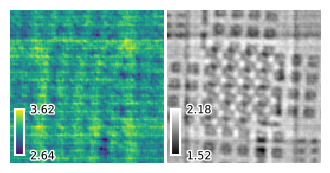

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7f7dd01679a0>)

In [76]:
#Ic_2
half = gt.shape[0]//2
full_save_name = "ic_2_zoomed_PS_all"
size = 130
y_offset = -95
x_offset = -10
plot_object(recon[half+y_offset:half+y_offset+size, half+x_offset-size//2:half+x_offset+size//2],
            save_path = '../../manuscript_figures/Figure_3_comparison/Quadruple_model_predictions',
            save_name = full_save_name)

##### Fly1

Image saved as ../../manuscript_figures/Figure_3_comparison/Quadruple_model_predictions/fly001_zoomed_PS_all.svg


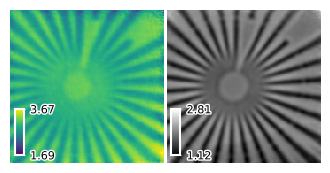

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7f7da2b38a60>)

In [108]:
#Fly001
half = gt.shape[0]//2
full_save_name = "fly001_zoomed_PS_all"
size = 154
y_offset = 0
x_offset = 0
plot_object(recon,
            save_path = '../../manuscript_figures/Figure_3_comparison/Quadruple_model_predictions',
            save_name = full_save_name)

Image saved as ../../manuscript_figures/Figure_3_comparison/fly001_gt.svg


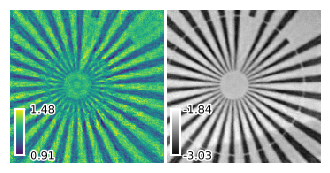

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7f7da2c22da0>)

In [109]:
full_save_name = 'fly001_gt'
plot_object(gt,
            save_path = '../../manuscript_figures/Figure_3_comparison/',
            save_name = full_save_name)

##### CNM

Image saved as ../../manuscript_figures/Figure_3_comparison/Quadruple_model_predictions/cnm_zoomed_PS_all.svg


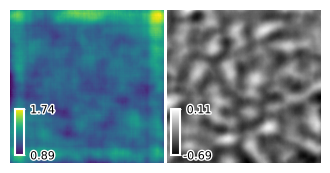

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7f7da3921990>)

In [84]:
#CNM
half = gt.shape[0]//2
full_save_name = "cnm_zoomed_PS_all"
size = 154
y_offset = 0
x_offset = 0
plot_object(recon,
            save_path = '../../manuscript_figures/Figure_3_comparison/Quadruple_model_predictions',
            save_name = full_save_name)

##### LFP

Image saved as ../../manuscript_figures/Figure_3_comparison/Quadruple_model_predictions/lfp_zoomed_PS_all.svg


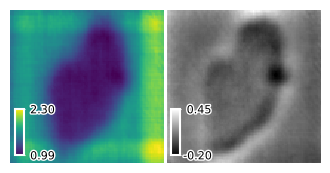

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7f7da2ee60b0>)

In [106]:
#LFP
half = gt.shape[0]//2
full_save_name = "lfp_zoomed_PS_all"
size = 154
y_offset = 0
x_offset = 0
plot_object(recon,
            save_path = '../../manuscript_figures/Figure_3_comparison/Quadruple_model_predictions',
            save_name = full_save_name)

Image saved as ../../manuscript_figures/Figure_3_comparison/lfp_gt.svg


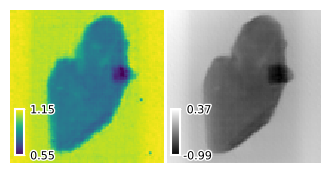

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7f7da2a25840>)

In [111]:
full_save_name = 'lfp_gt'
plot_object(gt,
            save_path = '../../manuscript_figures/Figure_3_comparison/',
            save_name = full_save_name)

## 3c. Calculating the average performance of multi-probe trained models.

1. Run all helper functions for figure 2, a.
2. We'll set up an independent workflow to evaluate and calculate all the FRC statistics for trained models

### Helper functions (FRC calcs, copied from calculate_frc)

In [15]:
import importlib
import ptychopinn_torch.datagen
import ptychopinn_torch.reassembly
import ptychopinn_torch.helper
import ptychopinn_torch.dataloader
import ptychopinn_torch.patch_generator
importlib.reload(ptychopinn_torch.reassembly)
importlib.reload(ptychopinn_torch.helper)
importlib.reload(ptychopinn_torch.dataloader)
importlib.reload(ptychopinn_torch.patch_generator)
from ptychopinn_torch.reassembly import reconstruct_image, reassemble_multi_channel
from ptychopinn_torch.patch_generator import get_fixed_quadrant_neighbors_c4

In [16]:
from ptychopinn_torch.eval.frc import frc_preprocess_images, _match_phases_least_squares
from ptychopinn_torch.eval.eval_metrics import FSC
from scipy.ndimage import fourier_shift
from ptychopinn_torch.utils import load_all_configs_from_mlflow
from ptychopinn_torch.config_params import update_existing_config
from ptychopinn_torch.helper import center_crop
from ptychopinn_torch.config_params import ModelConfig, TrainingConfig, DataConfig, InferenceConfig
from ptychopinn_torch.dataloader import TensorDictDataLoader, PtychoDataset, Collate
import numpy as np
import mlflow.pytorch
from mlflow import MlflowClient


# Constant vars
relative_mlruns_path = '../../mlruns'
tracking_uri = f"file:{os.path.abspath(relative_mlruns_path)}"

In [17]:
def load_dataset(ptycho_dir, model_id, data_config_replace=None):
    """
    Loads dataset with configuration parameters linked to specific model ID.
    Args:
        ptycho_dir (str): Directory containing the ptychography data.
        model_id (str): Model ID to load the dataset configuration from.
        data_config_replace (dict, optional): Dictionary to replace specific data configuration parameters.
    """
    


    #Load configs
    data_config, model_config, training_config, inference_config = load_all_configs_from_mlflow(model_id,
                                                                                            tracking_uri)


    # Replace data config if avail
    if data_config_replace is not None:
        update_existing_config(data_config, data_config_replace)

    print('Creating dataset...')
    ptycho_dataset = PtychoDataset(ptycho_dir, model_config, data_config,
                                remake_map=True)

    return ptycho_dataset, data_config, model_config, training_config, inference_config

In [18]:
def load_model_and_reconstruct(model_id, ptycho_dataset,
                              data_config, model_config, training_config,
                              inference_config, inference_config_replace = None):
    """
    Loads the model and reconstructs the image from the dataset.
    Args:
        model_id (str): Model ID to load the model from.
        ptycho_dataset (PtychoDataset): Dataset containing the ptychography data.
        data_config (DataConfig): Data configuration parameters.
        model_config (ModelConfig): Model configuration parameters.
        training_config (TrainingConfig): Training configuration parameters.
        inference_config (InferenceConfig): Inference configuration parameters.
    """
    
    # Loading model
    mlflow.set_tracking_uri(tracking_uri)
    model_uri = f"runs:/{model_id}/model"
    loaded_model = mlflow.pytorch.load_model(model_uri)
    loaded_model.to('cuda')
    loaded_model.training = True

    # Reconstruct image
    print('Reconstructing image...')
    result, recon_dataset = reconstruct_image(loaded_model, ptycho_dataset,
                           training_config, data_config, model_config, inference_config)

    return result, recon_dataset

In [19]:
def get_target_and_prediction_images_and_window(result, recon_dataset, window_size=0):
    """
    Meant to be called on result of reconstruct_image which still resides on GPU.
    Gets target amplitude and phase images, as well as the prediction amplitude and phase images.
    Crops to specified window size if provided.
    Args:
        result (torch.Tensor): Result tensor from the reconstruction. Complex-valued
        recon_dataset (PtychoDataset): Dataset containing the ptychography data.
        window_size (int): Size of the window to crop the images to. If 0, no cropping is done. Will almost surely be greater than 0.
    Returns:
        np.ndarray: Numpy array of the result.
    """
    #Move result to CPU and remove channel dimension if needed
    im_cpu = result.to('cpu')
    if len(im_cpu.shape) == 3:
        im_cpu = im_cpu.squeeze()
    
    # Set to shorter variable for readability
    w = window_size

    # Object recon
    recon = im_cpu.detach().cpu().numpy().copy()[w:-w,w:-w]

    # Ground truth
    gt = recon_dataset.data_dict['objectGuess'][0].copy()[w:-w,w:-w]
    gt = center_crop(gt, recon.shape[0])

    return gt, recon
    


In [20]:
def preprocess_and_calculate_frc(gt, recon):
    """
    Preprocesses the ground truth and reconstructed images, then calculates the Fourier Ring Correlation (FRC).
    Args:
        gt (np.ndarray): Ground truth image.
        recon (np.ndarray): Reconstructed image.
    Returns:
        tuple: FRC values and frequencies.
    """
    # Preprocess images
    aligned_gt, aligned_pred = frc_preprocess_images(gt, recon, image_prop='complex',verbose=True, align = False)

    # Calculate FRC
    FR_curve, x_FR, T_curve, x_T = FSC(aligned_gt, aligned_pred)

    # Calculate sum under curve until 1
    FR_AUC = np.sum(FR_curve[:np.where(x_FR - 1 > 0)[0][0]])/np.where(x_FR - 1 > 0)[0][0]

    return FR_curve, x_FR, FR_AUC
def save_frc_to_dict(FR_curve, x_FR, FR_AUC, frc_dict,
                     experiment_id, model_name, window_size):
    """
    Saves FRC values to dictionary with appropriate keys.
    """
    # In case frc_dict is not defaultdict
    if experiment_id not in frc_dict:
        frc_dict[experiment_id] = {}
    if model_name not in frc_dict[experiment_id]:
        frc_dict[experiment_id][model_name] = {}

    frc_dict[experiment_id][model_name]['x_FR'] = x_FR
    frc_dict[experiment_id][model_name]['FR_curve'] = FR_curve
    frc_dict[experiment_id][model_name]['FR_AUC'] = FR_AUC
    frc_dict[experiment_id][model_name]['window_size'] = window_size

    return frc_dict

def add_to_npz(filename, **new_arrays):
    """
    Adds new arrays to an existing .npz file or creates a new one if it doesn't exist.
    Args:
        filename (str): The name of the .npz file to which arrays will be added.
        **new_arrays: Arbitrary keyword arguments representing the new arrays to add.
    """
    try:
        # Load existing arrays
        existing = dict(np.load(filename))
        existing.update(new_arrays)
        np.savez(filename, **existing)
    except FileNotFoundError:
        # File doesn't exist yet, create it
        print("File not found")
        np.savez(filename, **new_arrays)

In [21]:
# For a given key in frc_dict and experiment name, assign x_FR, FR_curve and FR_AUC to numpy arrays. Concatenate them along the first axis.

def get_frc_arrays(frc_dict, exp_name):
    """
    Gets the FRC arrays for a given experiment name and model name from the frc_dict.
    Args:
        frc_dict (dict): Dictionary containing FRC results.
        exp_name (str): Experiment name.
        model_name (str): Model name.
    Returns:
        tuple: x_FR, FR_curve, FR_AUC as numpy arrays.
    """

    x_FR = []
    FR_curve = []
    FR_AUC = []
    model_list = list(frc_dict[exp_name].keys())  # Get the first model name for the experiment

    for model_name in frc_dict[exp_name].keys():
        x_FR.append(frc_dict[exp_name][model_name]['x_FR'])
        FR_curve.append(frc_dict[exp_name][model_name]['FR_curve'])
        FR_AUC.append(frc_dict[exp_name][model_name]['FR_AUC'])

    return x_FR, FR_curve, FR_AUC, model_list

In [22]:
def calculate_threshold_frc(x_FR):
    """
    Calculates the threshold FRC curve based on the x_FR array.
    Args:
        x_FR (list): List of x_FR arrays for different models.
    Returns:
        x_T, T_curve (tuple): Threshold FRC values and corresponding frequencies.
    """
    # Calculate threshold FRC curve (taken from eval_metrics.py)
    SNRt = 0.2071 #half bit threshold
    eps = np.finfo(float).eps
    r = np.arange(1+x_FR.shape[0]/2)
    n = 2*np.pi*r
    n[0] = 1
    t1 = np.divide(np.ones(np.shape(n)),n+eps)
    t2 = SNRt + 2*np.sqrt(SNRt)*t1 + np.divide(np.ones(np.shape(n)),np.sqrt(n))
    t3 = SNRt + 2*np.sqrt(SNRt)*t1 + 1
    T_curve = np.divide(t2,t3)
    x_T = r/(x_FR.shape[0]/2)

    return x_T, T_curve

In [23]:
def preprocess_and_calculate_frc(gt, recon):
    """
    Preprocesses the ground truth and reconstructed images, then calculates the Fourier Ring Correlation (FRC).
    Args:
        gt (np.ndarray): Ground truth image.
        recon (np.ndarray): Reconstructed image.
    Returns:
        tuple: FRC values and frequencies.
    """
    # Preprocess images
    aligned_gt, aligned_pred = frc_preprocess_images(gt, recon, image_prop='complex',verbose=True, align = False)

    # Calculate FRC
    FR_curve, x_FR, T_curve, x_T = FSC(aligned_gt, aligned_pred)

    # Calculate sum under curve until 1
    FR_AUC = np.sum(FR_curve[:np.where(x_FR - 0.5 > 0)[0][0]])/np.where(x_FR - 0.5 > 0)[0][0]

    return FR_curve, x_FR, FR_AUC

### Calculating the new FRC values for probe dilution experiments

In [24]:
from collections import defaultdict

save_path = '../../data/frc_results'

if not os.path.exists(save_path):
    os.makedirs(save_path)

if os.path.exists(save_path + '/frc_probe_dilution_finetuned.npz'):
    print("Loading existing frc_results.npz")
    frc_dict = np.load(save_path + '/frc_probe_dilution_finetuned.npz', allow_pickle = True)['frc_dict'].item()
else:
    frc_dict = defaultdict(dict)



Loading existing frc_results.npz


In [25]:
# for key, value in frc_dict.items():
#     value.pop('fly1_cnm')

frc_dict['pinn_hxn_cnm'].keys()




dict_keys(['cnm', 'fly1', 'tp2', 'lfp', 'tp2_cnm', 'tp2_fly1', 'tp2_lfp', 'fly1_lfp', 'fly1_tp2_cnm', 'fly1_tp2_lfp', 'fly1_cnm_lfp', 'tp2_cnm_lfp', 'fly1_tp2_cnm_lfp', 'cnm_lfp', 'fly1_cnm'])

#### Calculating FRC (only need to run once)

In [71]:
#Just write out main analysis workflow here for FRC

for file in file_list:
    # Get experiment name
    exp_name = file.split('/')[-1]

    # Get model ID
    for model_name, model_id in model_dict.items():
        # Check if this iteration was already done
        if exp_name in frc_dict and model_name in frc_dict[exp_name]:
            print(f'Skipping {exp_name} with model {model_name}, already processed.')
            continue

        print(f'Processing {exp_name} with model {model_name}')
        # Check to see if need to replace data config
        data_config_replace = {}

        data_config_replace['normalize'] = 'Batch'
        data_config_replace['probe_normalize'] = 'True'
        if exp_name != 'pinn_hxn_cnm':
            data_config_replace['min_neighbor_distance'] = 0.5
            data_config_replace['max_neighbor_distance'] = 8
            data_config_replace['scan_pattern'] = 'Rectangular'

        # Load dataset
        ptycho_dataset, data_config, model_config, training_config, inference_config = load_dataset(file, model_id,
                                                                                                  data_config_replace=data_config_replace)
        
        #Replacing inference config
        inference_config_replace = {'middle_trim': data_config.N//2,
                            'batch_size': 512,
                            'experiment_number': 0,
                            'pad_eval': True}

        update_existing_config(inference_config, inference_config_replace)
        
        print("Beginning reconstruction...")
        # Load model and reconstruct image
        result, recon_dataset = load_model_and_reconstruct(model_id, ptycho_dataset,
                                                        data_config, model_config,
                                                        training_config, inference_config)
        
        print("Recon complete. Beginning FRC calculation...")
        # Get target and prediction images
        gt, recon = get_target_and_prediction_images_and_window(result, recon_dataset,
                                                                window_size=window_size_dict[exp_name])

        # Preprocess and calculate FRC
        FR_curve, x_FR, FR_AUC = preprocess_and_calculate_frc(gt, recon)
        
        # Create entries if they don't exist
        if exp_name not in frc_dict:
            frc_dict[exp_name] = defaultdict(dict)
            if model_name not in frc_dict[exp_name]:
                frc_dict[exp_name][model_name] = defaultdict(dict)
        
        # Sanity check if frc_dict[exp_name][model_name] exists
        if model_name in frc_dict[exp_name]:
            print(f"frc_dict[{exp_name}][{model_name}] exists")
        
        frc_dict = save_frc_to_dict(FR_curve, x_FR, FR_AUC,frc_dict,
                                    exp_name, model_name,
                                    window_size=window_size_dict[exp_name])

        # Save intermediate results to .npz file
        print("Saving results to .npz file...")
        npz_filename = os.path.join(save_path, f'frc_probe_dilution_finetuned.npz')
        np.savez(npz_filename, frc_dict=frc_dict)

Skipping pinn_hxn_cnm with model cnm, already processed.
Skipping pinn_hxn_cnm with model fly1, already processed.
Skipping pinn_hxn_cnm with model tp2, already processed.
Skipping pinn_hxn_cnm with model lfp, already processed.
Skipping pinn_hxn_cnm with model tp2_cnm, already processed.
Skipping pinn_hxn_cnm with model tp2_fly1, already processed.
Skipping pinn_hxn_cnm with model tp2_lfp, already processed.
Processing pinn_hxn_cnm with model fly1_cnm
Creating dataset...
Calculating dataset length with coordinate bounds...
For file ../../data/pinn_hxn_cnm/CNM_APS_XNP_scan39_pty-chi_LSQML-64.npz, maximum x_range is (33.04172515869142, 203.9582748413086), yrange is (33.0417251586895, 203.9582748413105)
Creating memory mapped tensor dictionary...
Memory map length: 20449
Memory map creation time: 0.0009508132934570312
Populating memory map for dataset 0
Start - end = 20449
grouping
4_quadrant
Building KDTree for 25921 points...
Processing 20449 potential central points...
Finished quadra

### Unused. Plotting now

#### Helper

In [15]:
def plot_multi_dataset_bar_chart(analysis_dict, experiment_key, model_substring, 
                                model_dict, bar_colors=None, text_colors=None,
                                figsize=(10, 6), save_path=None, save_name='multi_dataset_bar_chart'):
    """
    Creates a bar chart showing FRC_AUC_0.5 performance as datasets are added to training.
    
    Args:
        analysis_dict (dict): Nested dictionary with structure: experiment -> model -> metrics
        experiment_key (str): The experiment to plot (e.g., '../../data/pinn_hxn_cnm')
        model_substring (str): The model substring to filter by (e.g., 'cnm', 'fly1', 'tp2', 'lfp')
        model_dict (dict): Mapping of model keys to their hash IDs
        bar_colors (list, optional): List of 4 colors for bars [1-dataset, 2-dataset, 3-dataset, 4-dataset]
        text_colors (list, optional): List of 4 text colors for bar labels
        figsize (tuple): Figure size
        save_path (str, optional): Path to save figure
        save_name (str): Name for saved figure
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Extract the base experiment name for substring matching
    # Convert '../../data/pinn_hxn_cnm' to 'cnm' for matching
    
    # Check if experiment exists
    if experiment_key not in analysis_dict:
        raise ValueError(f"Experiment '{experiment_key}' not found in analysis_dict")
    
    exp_data = analysis_dict[experiment_key]
    
    # Filter models by substring and group by number of datasets
    dataset_groups = {1: [], 2: [], 3: [], 4: []}
    
    for model_key in model_dict.keys():
        # Check if this model hash exists in the experiment data
        if model_key in exp_data:
            # Check if the model contains the specified substring
            if model_substring in model_key:
                # Count number of datasets (number of underscores + 1)
                num_datasets = len(model_key.split('_'))
                if num_datasets in dataset_groups:
                    if 'FR_AUC' in exp_data[model_key]:
                        auc_score = exp_data[model_key]['FR_AUC']
                        dataset_groups[num_datasets].append(auc_score)
                        print(f"{model_key}: {auc_score}")

    
    # Calculate means for each group
    x_labels = ['1', '2', '3', '4']
    scores = []
    valid_groups = []
    
    for i in range(1, 5):
        if dataset_groups[i]:
            scores.append(np.mean(dataset_groups[i]))
            valid_groups.append(i)
        else:
            scores.append(0)  # or np.nan if you prefer
            valid_groups.append(i)
    
    if not any(scores):
        raise ValueError(f"No FR_AUC data found for model substring '{model_substring}' in experiment '{experiment_key}'")
    
    max_score = max([s for s in scores if s > 0])
    
    # Set up colors
    default_bar_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red
    default_text_color = 'white'
    
    if bar_colors is None:
        bar_colors = default_bar_colors
    if text_colors is None:
        text_colors = [default_text_color] * 4
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize, dpi=250)
    fig.patch.set_alpha(0)
    
    # Create bars
    x_pos = np.arange(len(scores))
    bars = ax.bar(x_pos, scores, color=bar_colors[:len(scores)],
                  width=0.8, edgecolor='black', linewidth=0.7)
    
    # Add text labels on bars (rotated 90 degrees counter-clockwise)
    for i, (bar, label, text_color, score) in enumerate(zip(bars, x_labels, text_colors, scores)):
        if score > 0:  # Only add text if there's actual data
            height = bar.get_height()
            if height < 0.42 * max_score:
                height += 0.03
            else:
                height = 0.01
            ax.text(bar.get_x() + bar.get_width()/2. + 0.1, height,
                    label, ha='center', va='bottom',
                    fontsize=6.5, rotation=90, color=text_color)
    
    # Set x-axis labels
    # ax.set_xticks(x_pos)
    # ax.set_xticklabels(x_labels, rotation=45, ha='right')
    
    # Set labels and title
    ax.set_ylabel('FRC_AUC', fontsize=12)
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)
    
    # Add value labels on top of bars
    for i, (bar, score) in enumerate(zip(bars, scores)):
        if score > 0:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{score:.3f}', ha='center', va='bottom', fontsize=8)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save if requested
    if save_path:
        full_save_path = f"{save_path}/{save_name}.svg"
        plt.savefig(full_save_path, format='svg', dpi=300,
                    bbox_inches='tight', pad_inches=0,
                    transparent=True, facecolor='none')
        print(f"Figure saved as {full_save_path}")
    
    plt.show()
    
    # Print summary statistics
    print(f"\nSummary for {model_substring} in {experiment_key}:")
    for i, (group, score) in enumerate(zip(x_labels, scores), 1):
        if score > 0:
            count = len(dataset_groups[i])
            print(f"{group}: {score:.4f} (n={count} models)")
        else:
            print(f"{group}: No data available")

#### Plots

In [43]:
frc_dict.keys()

dict_keys(['pinn_hxn_cnm', 'pinn_velo_fly001', 'pinn_velo_gold_tp_2', 'pinn_cosmic_micro_lfp'])

cnm: 0.5148503850668406
tp2_cnm: 0.5610558653752534
fly1_cnm: 0.3537062714019479
cnm_lfp: 0.43607387171744333
fly1_tp2_cnm: 0.5685186579877227
fly1_cnm_lfp: 0.5240690745872427
tp2_cnm_lfp: 0.5191819757550468
fly1_tp2_cnm_lfp: 0.43423532537081383


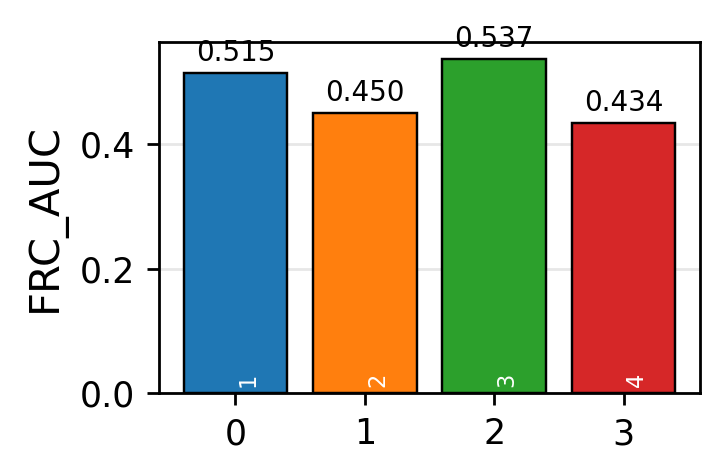


Summary for cnm in pinn_hxn_cnm:
1: 0.5149 (n=1 models)
2: 0.4503 (n=3 models)
3: 0.5373 (n=3 models)
4: 0.4342 (n=1 models)


In [46]:
experiment_key = 'pinn_hxn_cnm'
model_substring = 'cnm'

plot_multi_dataset_bar_chart(frc_dict, experiment_key, model_substring, 
                                model_dict, figsize = (3,2))

### Actual 3c. Trying a different kind of plot comparing with/without correct probe

In [37]:
def plot_foreign_model_comparison(analysis_dict, experiment_key, base_model,
                                 model_dict, base_results, bar_colors=None, text_colors=None,
                                 figsize=(14, 8), save_path=None, save_name='foreign_model_comparison',
                                 base_model_plot_name = None):
    """
    Creates a grouped bar chart comparing foreign model performance across different training combinations.
    
    Args:
        analysis_dict (dict): Nested dictionary with structure: experiment -> model -> metrics
        experiment_key (str): The experiment to plot (e.g., '../../data/pinn_hxn_cnm')
        base_model (str): The base model for this experiment (e.g., 'cnm', 'fly1', 'tp2', 'lfp')
        model_dict (dict): Mapping of model keys to their hash IDs
        base_results (dict): Dictionary with standalone performance values (e.g., {'cnm_standalone': 0.655, ...})
        bar_colors (list, optional): List of 4 colors for bars [single, dual, quad, standalone]
        text_colors (list, optional): List of 4 text colors for bar labels
        figsize (tuple): Figure size
        save_path (str, optional): Path to save figure
        save_name (str): Name for saved figure
        base_model_plot_name (str, optional): Display name for base model in labels
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Define all possible models
    all_models = ['cnm', 'fly1', 'tp2', 'lfp']
    
    # Get foreign models (all except base model)
    foreign_models = [m for m in all_models if m != base_model]
    
    # Check if experiment exists
    if experiment_key not in analysis_dict:
        raise ValueError(f"Experiment '{experiment_key}' not found in analysis_dict")
    
    exp_data = analysis_dict[experiment_key]
    
    # Initialize data structure for results
    results = {}
    for foreign_model in foreign_models:
        results[foreign_model] = {
            'single': None,
            'dual': None, 
            'quad': None,
            'standalone': None
        }
    
    # Parse through model_dict to find relevant models
    for model_key in model_dict.keys():
        if model_key in exp_data:
            model_parts = model_key.split('_')
            
            # Single model case (1 dataset)
            if len(model_parts) == 1 and model_parts[0] in foreign_models:
                results[model_parts[0]]['single'] = exp_data[model_key]['FR_AUC']
            
            # Dual model case (2 datasets: foreign + base)
            elif len(model_parts) == 2:
                if base_model in model_parts:
                    foreign_in_dual = [m for m in model_parts if m != base_model]
                    if len(foreign_in_dual) == 1 and foreign_in_dual[0] in foreign_models:
                        results[foreign_in_dual[0]]['dual'] = exp_data[model_key]['FR_AUC']
            
            # Quad model case (4 datasets: all models)
            elif len(model_parts) == 4:
                # This should be the same for all foreign models
                quad_score = exp_data[model_key]['FR_AUC']
                for foreign_model in foreign_models:
                    if foreign_model in model_parts:
                        results[foreign_model]['quad'] = quad_score
    
    # Add standalone results for base model
    base_standalone_key = f"{base_model}_standalone"
    if base_standalone_key in base_results:
        base_standalone_score = base_results[base_standalone_key]
        for foreign_model in foreign_models:
            results[foreign_model]['standalone'] = base_standalone_score
    else:
        print(f"Warning: {base_standalone_key} not found in base_results")
    
    # Prepare data for plotting
    group_names = [f.upper() for f in foreign_models]
    single_scores = [results[f]['single'] for f in foreign_models]
    dual_scores = [results[f]['dual'] for f in foreign_models]
    quad_scores = [results[f]['quad'] for f in foreign_models]
    standalone_scores = [results[f]['standalone'] for f in foreign_models]
    
    # Replace None values with 0 for plotting
    single_scores = [s if s is not None else 0 for s in single_scores]
    dual_scores = [s if s is not None else 0 for s in dual_scores]
    quad_scores = [s if s is not None else 0 for s in quad_scores]
    standalone_scores = [s if s is not None else 0 for s in standalone_scores]
    
    # Check if we have any data
    if not any(single_scores + dual_scores + quad_scores + standalone_scores):
        raise ValueError(f"No FRC_AUC_0.5 data found for foreign models in experiment '{experiment_key}'")
    
    max_score = max([s for s in single_scores + dual_scores + quad_scores + standalone_scores if s > 0])
    
    # Set up colors
    default_bar_colors = ['#708090', '#ff7f0e', '#2ca02c', "#87A3EB"]  # Grey, Orange, Green, Light Blue
    default_text_color = 'black'
    
    if bar_colors is None:
        bar_colors = default_bar_colors
    if text_colors is None:
        text_colors = [default_text_color] * 4
    
    # Set up the plot
    fig, ax = plt.subplots(figsize=figsize, dpi=200)
    fig.patch.set_alpha(0)

    # Set y lim
    ax.set_ylim([0,0.7])
    
    # Set up bar positions
    n_groups = len(foreign_models)
    bar_width = 0.2  # Adjusted for 4 bars
    x_pos = np.arange(n_groups)
    
    # Create bars
    bars1 = ax.bar(x_pos - 1.5*bar_width, single_scores, bar_width, 
                   label='', color=bar_colors[0],
                   edgecolor='black', linewidth=0.7)
    
    bars2 = ax.bar(x_pos - 0.5*bar_width, dual_scores, bar_width,
                   label=f'Dual (+ {base_model.upper()})', color=bar_colors[1],
                   edgecolor='black', linewidth=0.7)
    
    bars3 = ax.bar(x_pos + 0.5*bar_width, quad_scores, bar_width,
                   label='Quad (All 4)', color=bar_colors[2],
                   edgecolor='black', linewidth=0.7)
    
    bars4 = ax.bar(x_pos + 1.5*bar_width, standalone_scores, bar_width,
                   label='Test Probe Only', color=bar_colors[3],
                   edgecolor='black', linewidth=0.7)
    
    # Add text labels on bars (rotated 90 degrees counter-clockwise)
    if base_model_plot_name:
        base_model_plot = base_model_plot_name.upper()
    elif base_model == 'tp2':
        base_model_plot = "IC2"
    elif base_model == 'cnm':
        base_model_plot = "W"
    else:
        base_model_plot = base_model.upper()

    bar_groups = [bars1, bars2, bars3, bars4]
    bar_labels = ['', f'+ {base_model_plot}', 'All 4 probes', f'{base_model_plot} only']
    
    for bar_set, label, text_color in zip(bar_groups, bar_labels, text_colors):
        for bar in bar_set:
            height = bar.get_height()
            if height > 0:  # Only add text if there's actual data
                if height < 0.42 * max_score:
                    text_height = height + 0.03
                else:
                    text_height = 0.01
                ax.text(bar.get_x() + bar.get_width()/2., text_height,
                        label, ha='center', va='bottom',
                        fontsize=8, rotation=90, color=text_color)
    
    # Add value labels on top of bars
    for bar_set in bar_groups:
        for bar in bar_set:
            height = round(bar.get_height(),2)
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{height:.2f}'[1:], ha='center', va='bottom', fontsize=7)
    
    # Customize the plot
    # ax.set_ylabel('FRC_AUC', fontsize=12)

    for i, name in enumerate(group_names):
        if name == 'TP2' or name == 'tp2':
            group_names[i] = 'IC2'
        elif name == 'CNM' or name == 'cnm':
            group_names[i] = 'W'
    
    # Set x-axis
    ax.set_xticks(x_pos)
    ax.set_xticklabels(group_names)
    
    # Add legend
    # ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save if requested
    if save_path:
        full_save_path = f"{save_path}/{save_name}.svg"
        plt.savefig(full_save_path, format='svg', dpi=300,
                    bbox_inches='tight', pad_inches=0,
                    transparent=True, facecolor='none')
        print(f"Figure saved as {full_save_path}")
    
    plt.show()
    
    # Print summary statistics
    print(f"\nSummary for {experiment_key} (Base model: {base_model.upper()}):")
    for i, foreign_model in enumerate(foreign_models):
        print(f"\n{foreign_model.upper()}:")
        print(f"  Single: {single_scores[i]:.4f}" if single_scores[i] > 0 else "  Single: No data")
        print(f"  Dual: {dual_scores[i]:.4f}" if dual_scores[i] > 0 else "  Dual: No data")
        print(f"  Quad: {quad_scores[i]:.4f}" if quad_scores[i] > 0 else "  Quad: No data")
        print(f"  Standalone ({base_model.upper()}): {standalone_scores[i]:.4f}" if standalone_scores[i] > 0 else f"  Standalone ({base_model.upper()}): No data")

Figure saved as ../../manuscript_figures/Figure_3_comparison/fly1_probe_inclusion_v2.svg


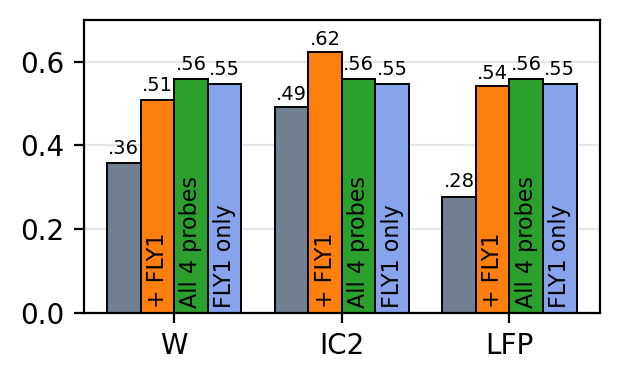


Summary for pinn_velo_fly001 (Base model: FLY1):

CNM:
  Single: 0.3584
  Dual: 0.5086
  Quad: 0.5589
  Standalone (FLY1): 0.5476

TP2:
  Single: 0.4910
  Dual: 0.6238
  Quad: 0.5589
  Standalone (FLY1): 0.5476

LFP:
  Single: 0.2763
  Dual: 0.5429
  Quad: 0.5589
  Standalone (FLY1): 0.5476


In [41]:
experiment_key = 'pinn_velo_fly001'
base_model = 'fly1'

full_save_path = '../../manuscript_figures/Figure_3_comparison'
save_name = 'fly1_probe_inclusion_v2'

base_results = {
    'cnm_standalone': frc_dict['pinn_hxn_cnm']['cnm']['FR_AUC'],
    'tp2_standalone': frc_dict['pinn_velo_ic_2']['tp2']['FR_AUC'],
    'lfp_standalone': frc_dict['pinn_cosmic_micro_lfp']['lfp']['FR_AUC'],
    'fly1_standalone': frc_dict['pinn_velo_fly001']['fly1']['FR_AUC'],
}

plot_foreign_model_comparison(frc_dict, experiment_key, base_model, 
                              model_dict, base_results,
                              figsize = (3.2,2),
                              save_path = full_save_path, save_name = save_name,
                              base_model_plot_name = 'fly1')

# Figure 4

Planning for Figure 4.

This will include:
- PSD's for different synthetic object functions as well experimental objects
- Evaluation for synthetic models trained on different objects for specific probe examples
    - Can pick gold_tp_2, fly_001, hxn, cosmic

## Compiling list of all models

In [4]:
file_list = ['../../data/pinn_hxn_cnm',
            '../../data/pinn_velo_fly001',
            '../../data/pinn_velo_gold_tp_2',
            '../../data/pinn_cosmic_micro_lfp',
            '../../data/pinn_velo_ic_2',
            '../../data/pinn_velo_ncm',
            ]

model_dict = {

    # Dead leaves
    "CNM_deadleaves": "74ba23396c4042afb1751afe9fa87520",
    "fly1_deadleaves": "3d2ca583357c43baa6ab17519d500355",
    "tp2_deadleaves": "6fb4668f21e44e0b80056f64fdfedf01",
    "lfp_deadleaves": "1cda8280703748fabba173f747fc4103",

    # Procedural
    "CNM_procedural": "ed7cabe320b94e82a2a8c13b519abc6d",
    "fly1_procedural": "11ff4f97061f4554b831c45caa40f495",
    "tp2_procedural": "04106a3750184a2dbe544cc2c8c2f857",
    "lfp_procedural": "1aaf4df1f3a5440da898667953dd11f3",
    
    # Smooth White Noise (blurred_wn)
    "CNM_blurred_wn": "42d9fb49f2c94a44b0f03b7f221cab8f",
    "fly1_blurred_wn": "1c5528183d834c299e2d43e535fb8cf8",#"bc6992fb52c0415dbd0334d360b95227",
    "tp2_blurred_wn": "0c975e1328e64f7898abb6d94973bbec",
    # "ic2_blurred_wn": "1e2dbf5e00d24fcfadba84c9d9c39a70",
    # "ncm_blurred_wn": "a56e49f8884a49fd896a3b3fbafad693",
    "lfp_blurred_wn": "0248c08bb3c04004a6672a201f9a3a2d",
}

window_size_dict = {
    #Synthetic objects
    'pinn_hxn_cnm': 20,
    'pinn_velo_fly001': 10,
    'pinn_velo_gold_tp_2': 40,
    'pinn_cosmic_micro_lfp': 20,
    'pinn_velo_ic_2': 20,
    'pinn_velo_ncm': 20
}


### Calculating all FRCS

In [20]:
import ptychopinn_torch.notebooks.analysis
importlib.reload(ptychopinn_torch.notebooks.analysis)
from ptychopinn_torch.notebooks.analysis import calculate_all_frcs
from ptychopinn_torch.notebooks.analysis import generate_gt_and_recon, plot_object

In [21]:
calculate_all_frcs(file_list, model_dict, window_size_dict,
                   "../../data/frc_results",
                   save_file_name = "frc_different_synthetic.npz")

Loading existing frc_results.npz
Skipping pinn_hxn_cnm with model CNM_deadleaves, already processed.
Skipping pinn_hxn_cnm with model fly1_deadleaves, already processed.
Skipping pinn_hxn_cnm with model tp2_deadleaves, already processed.
Skipping pinn_hxn_cnm with model lfp_deadleaves, already processed.
Skipping pinn_hxn_cnm with model CNM_procedural, already processed.
Skipping pinn_hxn_cnm with model fly1_procedural, already processed.
Skipping pinn_hxn_cnm with model tp2_procedural, already processed.
Skipping pinn_hxn_cnm with model lfp_procedural, already processed.
Skipping pinn_hxn_cnm with model CNM_blurred_wn, already processed.
Skipping pinn_hxn_cnm with model fly1_blurred_wn, already processed.
Skipping pinn_hxn_cnm with model tp2_blurred_wn, already processed.
Skipping pinn_hxn_cnm with model lfp_blurred_wn, already processed.
Skipping pinn_velo_fly001 with model CNM_deadleaves, already processed.
Skipping pinn_velo_fly001 with model fly1_deadleaves, already processed.
Ski

### Looking at reconstructions and saving them

In [5]:
save_file_name = "frc_different_synthetic.npz"
save_path = "../../data/frc_results"

frc_dict = np.load(save_path + '/' + save_file_name, allow_pickle = True)['frc_dict'].item()


In [41]:
#Run Figure 2, 1a. first to get necessary functions
gt, recon = generate_gt_and_recon('../../data/pinn_cosmic_micro_lfp', 'lfp_blurred_wn', model_dict,
                                  window_size_dict)

amp, phase = np.abs(recon), np.angle(recon)

Creating dataset...
Calculating dataset length with coordinate bounds...
For file ../../data/pinn_cosmic_micro_lfp/microLFPstack_single_exposure_64_train.npz, maximum x_range is (33.45436096191406, 144.54563903808594), yrange is (33.45436096191406, 144.54563903808594)
Creating memory mapped tensor dictionary...
Memory map length: 4489
Memory map creation time: 0.001222848892211914
Populating memory map for dataset 0
Start - end = 4489
Building KDTree for 5625 points...
Processing 4489 potential central points...
Finished quadrant neighbor processing. Found 4489 valid C=4 groups.
Non-diffraction memory map write time: 0.3341636657714844
Getting normalization coefficients...
Batch rms factor is tensor([[[[0.0060]]]])
Diffraction memory map write time: 0.14974641799926758
[PtychoDataset Rank 0] Initialization successful. Dataset length: 4489.
Beginning reconstruction...
Reconstructing image...
Batch 0 completed in 0.14249348640441895 seconds
Batch 1 completed in 0.1417083740234375 seconds

#### Different reconstructions with specific zooms

##### TP2

Image saved as ../../manuscript_figures/Figure_4_synthetic_models/tp2_zoomed_tp2_deadleaves.svg


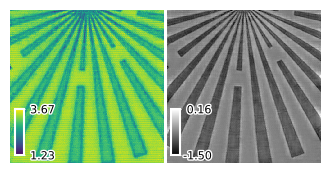

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7fc0d0331150>)

In [70]:
#tp2
half = gt.shape[0]//2
full_save_name = "tp2_zoomed_tp2_deadleaves"

plot_object(recon,
            save_path = '../../manuscript_figures/Figure_4_synthetic_models',
            save_name = full_save_name)

##### IC2

Image saved as ../../manuscript_figures/Figure_4_synthetic_models/ic2_zoomed_tp2_deadleaves.svg


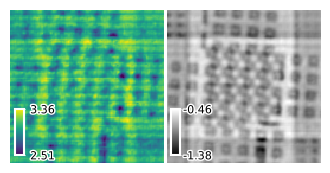

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7fc0bbe94070>)

In [72]:
#Ic_2
half = gt.shape[0]//2
full_save_name = "ic2_zoomed_tp2_deadleaves"
size = 130
y_offset = -95
x_offset = -10
plot_object(recon[half+y_offset:half+y_offset+size, half+x_offset-size//2:half+x_offset+size//2],
            save_path = '../../manuscript_figures/Figure_4_synthetic_models',
            save_name = full_save_name)

##### Fly1

Image saved as ../../manuscript_figures/Figure_4_synthetic_models/fly1_zoomed_fly1_wn.svg


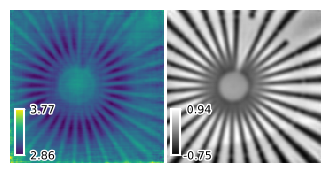

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7fa94f025b40>)

In [31]:
#fly1
half = gt.shape[0]//2
full_save_name = "fly1_zoomed_fly1_wn"

plot_object(recon,
            save_path = '../../manuscript_figures/Figure_4_synthetic_models',
            save_name = full_save_name)

##### NCM

Image saved as ../../manuscript_figures/Figure_4_synthetic_models/ncm_zoomed_tp2_deadleaves.svg


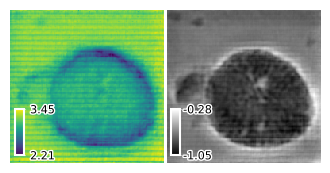

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7fc0bbf66290>)

In [74]:
#Ic_2
half = gt.shape[0]//2
full_save_name = "ncm_zoomed_tp2_deadleaves"
plot_object(recon,
            save_path = '../../manuscript_figures/Figure_4_synthetic_models',
            save_name = full_save_name)

Image saved as ../../manuscript_figures/Figure_3_comparison/fly001_gt.svg


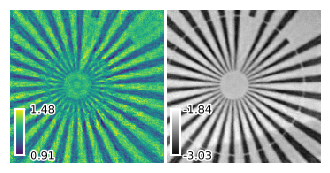

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7f7da2c22da0>)

In [ ]:
full_save_name = 'fly001_gt'
plot_object(gt,
            save_path = '../../manuscript_figures/Figure_3_comparison/',
            save_name = full_save_name)

##### CNM

Image saved as ../../manuscript_figures/Figure_4_synthetic_models/cnm_zoomed_cnm_wn.svg


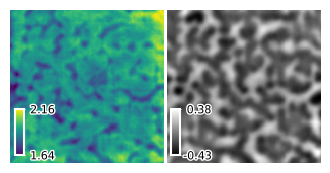

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7fa94c2c5180>)

In [26]:
#CNM
half = gt.shape[0]//2
full_save_name = "cnm_zoomed_cnm_wn"
plot_object(recon,
            save_path = '../../manuscript_figures/Figure_4_synthetic_models',
            save_name = full_save_name)

##### LFP

Image saved as ../../manuscript_figures/Figure_4_synthetic_models/lfp_zoomed_lfp_wn.svg


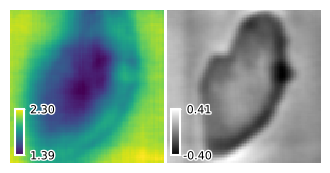

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7fa94c621600>)

In [42]:
#LFP
half = gt.shape[0]//2
full_save_name = "lfp_zoomed_lfp_wn"

plot_object(recon,
            save_path = '../../manuscript_figures/Figure_4_synthetic_models',
            save_name = full_save_name)

Image saved as ../../manuscript_figures/Figure_3_comparison/lfp_gt.svg


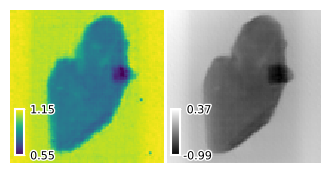

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7f7da2a25840>)

In [ ]:
full_save_name = 'lfp_gt'
plot_object(gt,
            save_path = '../../manuscript_figures/Figure_3_comparison/',
            save_name = full_save_name)

## Plotting FRC curves

In [6]:
from ptychopinn_torch.notebooks.analysis import get_frc_arrays, calculate_threshold_frc

#### Helper functions

In [7]:
def plot_frc_curves(frc_dict, exp_name, experiment_substrings, 
                   model_colors=None, model_styles=None, plot_names=None,
                   model_linewidths=None, model_alphas=None, model_priority=None,
                   save_path = None, save_name = 'Default'):
    """
    Plots the FRC curves for a given experiment name with customizable styling and order.
    Args:
        frc_dict (dict): Dictionary containing FRC results.
        exp_name (str): Experiment name.
        experiment_substrings (list): List of model substrings to include.
        model_colors (dict, optional): Dictionary mapping model names to colors.
        model_styles (dict, optional): Dictionary mapping model names to line styles.
        plot_names (dict, optional): Dictionary mapping model names to display names.
        model_linewidths (dict, optional): Dictionary mapping model names to line widths.
        model_alphas (dict, optional): Dictionary mapping model names to alpha transparency values.
        model_priority (dict, optional): Dictionary mapping model names to priority order (lower numbers plot first/behind).
    """
    from scipy.signal import savgol_filter
    
    x_FR, FR_curve, FR_AUC, model_name = get_frc_arrays(frc_dict, exp_name)

    # Generate figure
    fig = plt.figure(figsize=(5,3))
    fig.patch.set_alpha(0)

    # Filter and collect models that match experiment substrings
    models_to_plot = []
    for i, model in enumerate(model_name):
        if any(substrings in model for substrings in experiment_substrings):
            models_to_plot.append((i, model))
    
    # Sort by priority if provided
    if model_priority:
        models_to_plot.sort(key=lambda x: model_priority.get(x[1], float('inf')))

    # Plot models in priority order
    for i, model in models_to_plot:
        x_FR_i, FR_curve_i, FR_AUC_i = x_FR[i], FR_curve[i], FR_AUC[i]

        model_ref = model.split('_',1)[-1]
        
        # Get styling parameters
        color = model_colors.get(model_ref, None) if model_colors else None
        linestyle = model_styles.get(model_ref, '-') if model_styles else '-'
        linewidth = model_linewidths.get(model_ref, 1.0) if model_linewidths else 1.0
        alpha = model_alphas.get(model_ref, 1.0) if model_alphas else 1.0
        
        # Get display name
        display_name = plot_names[model_ref]
    
        
        # Smooth the FRC curve
        window_length = min(11, len(FR_curve_i) if len(FR_curve_i) % 2 == 1 else len(FR_curve_i)-1)
        if window_length < 3:
            window_length = 3
        
        FR_curve_smooth = savgol_filter(FR_curve_i, window_length=window_length, polyorder=2)
        
        # Plot with custom styling
        plt.plot(x_FR_i, FR_curve_smooth, 
                label=display_name,
                color=color,
                linestyle=linestyle,
                linewidth=linewidth,
                alpha=alpha)

    # Plot threshold
    if models_to_plot:  # Only if we have models to plot
        # Use the last model's x_FR for threshold calculation
        x_FR_last = x_FR[models_to_plot[-1][0]]
        x_T, T_curve = calculate_threshold_frc(x_FR_last)
        plt.plot(x_T, T_curve, label='1/2-bit threshold', linestyle='--', color='red')
            
    plt.xlabel('Spatial Frequency (1/pixel)', fontweight = 'bold', fontsize=12)
    plt.ylabel('FRC', fontweight = 'bold', fontsize=12)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()

    
    format = 'svg'
    if save_path:
        full_save_path = os.path.join(save_path, f"{save_name}.{format}")
        plt.savefig(full_save_path, format='svg', dpi=600, 
                   bbox_inches='tight', pad_inches=0, 
                   transparent=True, facecolor='none')
        print(f"Image saved as {full_save_path}")

    plt.show()

### Proceed with plotting

Image saved as ../../manuscript_figures/Figure_4_synthetic_models/frc/redo/ic2_frc_comparison.svg


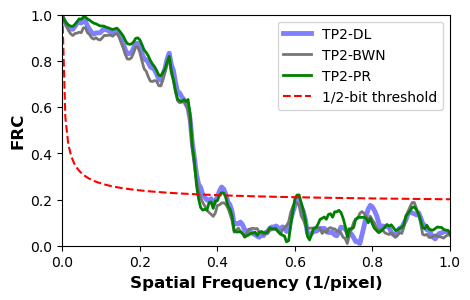

In [13]:
# Your existing definitions
exp_name = 'pinn_velo_ic_2'
save_path = '../../manuscript_figures/Figure_4_synthetic_models/frc/redo'
full_save_name = 'ic2_frc_comparison'

# Model mapping - ONLY thing you need to change when swapping models
model_mapping = {
    'deadleaves': 'tp2_deadleaves',
    'blurred_wn': 'tp2_blurred_wn',
    'procedural': 'tp2_procedural'
}

plot_names = {
    'deadleaves': 'TP2-DL',
    'blurred_wn': 'TP2-PR',
    'procedural': 'TP2-BWN',
}

# Auto-generate model_substrings from the mapping
model_substrings = [model_mapping[key] for key in ['deadleaves', 'blurred_wn', 'procedural']]


model_colors = {
    'deadleaves': 'blue',
    'blurred_wn': 'green',
    'procedural': '#787575',
}

model_styles = {
    'deadleaves': '-',
    'blurred_wn': '-',
    'procedural': '-',
}

model_linewidths = {
    'deadleaves': 3.5,
    'blurred_wn': 2.0,
    'procedural': 2.0,
}

model_alphas = {
    'deadleaves': 0.5,
    'blurred_wn': 1.0,
    'procedural': 1.0,
}

model_priority = {
    'deadleaves': 3,
    'blurred_wn': 2,
    'procedural': 1,
}

# Call with all styling dictionaries
plot_frc_curves(frc_dict, exp_name, model_substrings, 
                model_colors, model_styles, plot_names,
                model_linewidths, model_alphas, model_priority,
                save_path, full_save_name)

## Plotting data for simplex noise

### Helper

In [75]:
from ptychopinn_torch.notebooks.analysis import generate_gt_and_recon, plot_object

In [76]:
def compute_psd_2d(image):
    """
    Compute the 2D power spectral density of an image.
    
    Args:
        image (np.ndarray): 2D image array (real or complex)
        
    Returns:
        np.ndarray: 2D power spectral density
    """
    # Take 2D FFT
    fft_2d = np.fft.fft2(image)
    
    # Shift zero frequency to center
    fft_2d_shifted = np.fft.fftshift(fft_2d)
    
    # Compute power spectral density
    psd_2d = np.abs(fft_2d_shifted)**2
    
    return psd_2d

def compute_radial_psd(image):
    """
    Compute the radially averaged power spectral density.
    This gives you a 1D profile showing how power varies with spatial frequency.
    
    Args:
        image (np.ndarray): 2D image array
        
    Returns:
        tuple: (frequencies, radial_psd)
    """
    # Get 2D PSD
    psd_2d = compute_psd_2d(image)
    
    h, w = psd_2d.shape
    center_y, center_x = h // 2, w // 2
    
    # Create coordinate arrays
    y, x = np.ogrid[:h, :w]
    
    # Calculate distance from center for each pixel
    r = np.sqrt((x - center_x)**2 + (y - center_y)**2)
    
    # Define radial bins
    max_r = min(center_x, center_y)
    r_bins = np.arange(0, max_r, 1)
    
    # Compute radially averaged PSD
    radial_psd = []
    for i in range(len(r_bins) - 1):
        mask = (r >= r_bins[i]) & (r < r_bins[i + 1])
        if np.any(mask):
            radial_psd.append(np.mean(psd_2d[mask]))
        else:
            radial_psd.append(0)
    
    # Convert bin indices to actual frequencies
    frequencies = r_bins[:-1] / max(h, w)  # Normalized frequencies
    
    return frequencies, np.array(radial_psd)

def plot_psd_2d(psd_data, colorbar_size=(0.06, 0.3), 
                colorbar_position=(0.03, 0.05), figsize=(2, 2), 
                save_path=None, save_name='psd_default', 
                format='svg', dpi=600, cmap='hot', noise_floor=1e-10):
    """
    Plot 2D power spectral density data as log10 image with embedded colorbar.
    
    Parameters:
    -----------
    psd_data : numpy.ndarray
        2D power spectral density array
    colorbar_size : tuple
        (width, height) of colorbar as fraction of image
    colorbar_position : tuple
        (x, y) position of colorbar bottom-left corner as fraction of image
    figsize : tuple
        Figure size in inches (width, height)
    save_path : str or None
        Directory path to save the image. If None, displays only
    save_name : str
        Base filename for saved image
    format : str
        Export format ('svg', 'pdf', 'png', 'eps')
    dpi : int
        DPI for raster formats
    cmap : str
        Colormap for PSD display
    noise_floor : float
        Small value added to prevent log(0)
    """
    
    # Apply log10 transform with noise floor
    log_psd = np.log10(psd_data + noise_floor)
    
    # Create figure with single subplot
    fig, ax = plt.subplots(1, 1, figsize=figsize, facecolor='none')
    fig.patch.set_alpha(0)
    
    # Get data range for colorbar
    vmin, vmax = 0, np.max(log_psd)
    min_label = f'{vmin:.2f}' if vmin <= 0 else f' {vmin:.2f}'
    max_label = f'{vmax:.2f}' if vmax <= 0 else f' {vmax:.2f}'
    tick_labels = [min_label, max_label]
    
    # Display PSD image
    im = ax.imshow(log_psd, cmap=cmap, vmin=0, vmax=vmax, 
                   aspect='equal')
    
    im.set_clim(0, np.max(log_psd))
    
    # Remove borders and ticks from main axis
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Create colorbar
    pos = ax.get_position()
    cb_left = pos.x0 + colorbar_position[0] * pos.width
    cb_bottom = pos.y0 + colorbar_position[1] * pos.height
    cb_width = colorbar_size[0] * pos.width
    cb_height = colorbar_size[1] * pos.height
    
    ax_cb = fig.add_axes([cb_left, cb_bottom, cb_width, cb_height])
    cb = plt.colorbar(im, cax=ax_cb, orientation='vertical')
    ax_cb.set_aspect('auto')
    
    cb.set_ticks([vmin, vmax])
    cb.set_ticklabels(tick_labels)
    cb.ax.tick_params(color='white', size=1)
    
    cb.ax.tick_params(
        labelsize=8,
        labelcolor='black',
        pad=1,
        left=False, 
        right=True, 
        labelleft=False,
        labelright=True
    )
    
    for label in cb.ax.get_yticklabels():
        label.set_path_effects([
            patheffects.Stroke(linewidth=2, foreground='white'),
            patheffects.Normal()
        ])
    
    cb.outline.set_visible(True)
    cb.outline.set_linewidth(1.5)
    cb.outline.set_edgecolor('white')
    
    if save_path:
        full_save_path = os.path.join(save_path, f"{save_name}.{format}")
        plt.savefig(full_save_path, format=format, dpi=dpi, 
                   bbox_inches='tight', pad_inches=0, 
                   transparent=True, facecolor='none')
        print(f"Image saved as {full_save_path}")
    
    plt.show()
    return fig, ax, cb

In [77]:
def plot_radial_psd(object_image, figsize=(2,2), line_color='red', linewidth=3, fontsize=14,
                    save_path = None, save_name = 'default', dpi = 600, format='svg'):

    frequencies, radial_psd = compute_radial_psd(object_image)

    # Create figure with transparent background
    fig = plt.figure(figsize=figsize, facecolor='none')
    fig.patch.set_alpha(0)
    # ax = plt.gca()
    # ax.set_facecolor('black') 
    
    # For the plot line itself:
    plt.loglog(frequencies[1:], radial_psd[1:], 
            color=line_color, 
            linewidth=linewidth,
            path_effects=[patheffects.Stroke(linewidth=linewidth+2, foreground='white', alpha=1.0),
                        patheffects.Normal()])

    # For axis labels:
    plt.xlabel('Frequency', fontsize=fontsize, fontweight='bold', color=line_color,
            path_effects=[patheffects.Stroke(linewidth=2, foreground='white', alpha=1.0),
                        patheffects.Normal()])
    plt.ylabel('Power', fontsize=fontsize, fontweight='bold', color=line_color,
            path_effects=[patheffects.Stroke(linewidth=2, foreground='white', alpha=1.0),
                        patheffects.Normal()])
    plt.ylim([1e2,1e8])

    # For tick labels:
    ax = plt.gca()
    plt.tick_params(axis='both', which='major', labelsize=fontsize-2, 
                   colors=line_color, width=2, length=6)
    plt.tick_params(axis='both', which='minor', labelsize=fontsize-4, 
                   colors=line_color, width=1, length=3)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_path_effects([patheffects.Stroke(linewidth=2, foreground='white', alpha=1.0),
                            patheffects.Normal()])

    # For plot borders with white outline:
    for spine in ax.spines.values():
        spine.set_color(line_color)
        spine.set_linewidth(2)
        spine.set_path_effects([patheffects.Stroke(linewidth=4, foreground='white', alpha=1.0),
                            patheffects.Normal()])
    
    # Tight layout for clean overlay
    plt.tight_layout()

    if save_path:
        full_save_path = os.path.join(save_path, f"{save_name}.{format}")
        plt.savefig(full_save_path, format=format, dpi=dpi, 
                    bbox_inches='tight', pad_inches=0, 
                    transparent=True, facecolor='none')
        print(f"Image saved as {full_save_path}")
    
    return fig

### File list

In [39]:
file_list = ['../../data/pinn_hxn_cnm',
            '../../data/pinn_velo_fly001',
            '../../data/pinn_velo_gold_tp_2',
            '../../data/pinn_cosmic_micro_lfp',
            '../../data/pinn_velo_ic_2',
            '../../data/pinn_velo_ncm',
            ]

model_dict = {
    "CNM_simplex": "7c0b74ecf2d54198acea22aee60fdfc2",
    "fly1_simplex": "db698d0b702348ae8f33bf44e0d1573b",
    "tp2_simplex": "c98fefc6252e494db5f0ce5155904333",
    "ic2_simplex": "da9c13ba1e354a2ba7b020ed5d02fb75",
    "ncm_simplex": "72401cec06bb4673a321f90e4fa9e05f",
    "lfp_simplex": "12ce5db7c1564fd7a5fed78704b0c010"
}

window_size_dict = {
    #Synthetic objects
    'pinn_hxn_cnm': 20,
    'pinn_velo_fly001': 10,
    'pinn_velo_gold_tp_2': 40,
    'pinn_cosmic_micro_lfp': 20,
    'pinn_velo_ic_2': 20,
    'pinn_velo_ncm': 20
}


In [40]:
#Run Figure 2, 1a. first to get necessary functions
gt, recon = generate_gt_and_recon('../../data/pinn_velo_gold_tp_2', 'tp2_simplex', model_dict,
                                  window_size_dict)

amp, phase = np.abs(recon), np.angle(recon)

Creating dataset...
Calculating dataset length with coordinate bounds...
For file ../../data/pinn_velo_gold_tp_2/nxs_data_gold_tp_2_64_train.npz, maximum x_range is (33.47206497192383, 566.5279541015625), yrange is (33.47703552246094, 630.52294921875)
Creating memory mapped tensor dictionary...
Memory map length: 5931
Memory map creation time: 0.0007214546203613281
Populating memory map for dataset 0
Start - end = 5931
grouping
4_quadrant
Building KDTree for 7709 points...
Processing 5931 potential central points...
Finished quadrant neighbor processing. Found 5931 valid C=4 groups.
Non-diffraction memory map write time: 0.38289570808410645
Getting normalization coefficients...
Batch rms factor is tensor([[[[0.0031]]]])
Diffraction memory map write time: 0.19172310829162598
[PtychoDataset Rank 0] Initialization successful. Dataset length: 5931.
Beginning reconstruction...
Reconstructing image...
Batch 0 completed in 0.24854469299316406 seconds
Batch 1 completed in 0.2399764060974121 se

#### Simplex PSD stuff

Image saved as ../../manuscript_figures/Figure_4_synthetic_models/simplex/tp2_simplex_psd1d.svg


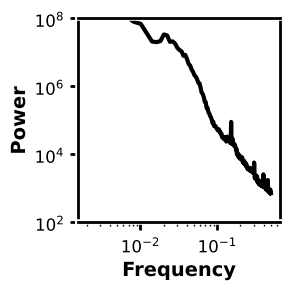

In [41]:
experiment_name = 'tp2_simplex'
full_save_name = experiment_name + '_psd'
save_path = '../../manuscript_figures/Figure_4_synthetic_models/simplex'

psd_image = compute_psd_2d(recon)
# plot_psd_2d(psd_image,
#             save_path = save_path,
#             save_name = full_save_name)

full_save_name = experiment_name + '_psd1d'

fig = plot_radial_psd(recon, figsize = (3,3), line_color = 'black',save_path = save_path, save_name = full_save_name)

##### Ground Truth simplex image and PSD

In [6]:
import ptychopinn_torch.datagen.objects
import ptychopinn_torch.datagen.datagen
importlib.reload(ptychopinn_torch.datagen.objects)
importlib.reload(ptychopinn_torch.datagen.datagen)

from ptychopinn_torch.datagen.datagen import simulate_synthetic_objects
from ptychopinn_torch.datagen.objects import create_complex_object

Image saved as ../../manuscript_figures/Figure_4_synthetic_models/simplex/simplex_gt.svg


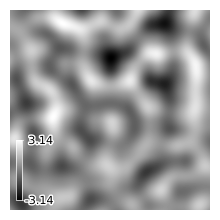

(<Figure size 200x200 with 2 Axes>,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7fc0ba3dad40>)

In [169]:
full_save_name = "simplex_gt"

obj_arg = {'blur': True,
           'r_min_frac': 0.03,
           'r_max_frac': 0.2,
           'r_sigma': 3,
           'max_iters': 500}
#Data configs
data_config = DataConfig()
img_shape = (200,200)
#Simulate simplex
synthetic_obj_list = simulate_synthetic_objects(img_shape, data_config, 4, "simplex_noise", obj_arg)



# Need to run "plot_complex_image" from Figure 1 section
plot_complex_image(synthetic_obj_list[1],
                   save_path = save_path,
                   save_name = full_save_name)


Image saved as ../../manuscript_figures/Figure_4_synthetic_models/simplex/simplex_gt_psd.svg


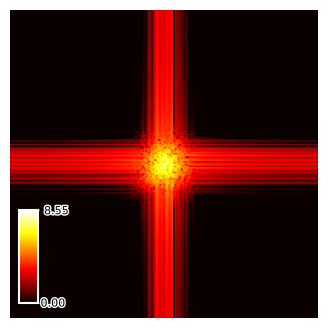

(<Figure size 400x400 with 2 Axes>,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7fc0ba35ee90>)

In [168]:
full_save_name = 'simplex_gt_psd'
save_path = '../../manuscript_figures/Figure_4_synthetic_models/simplex'

psd_image = compute_psd_2d(synthetic_obj_list[0])
plot_psd_2d(psd_image,
            save_path = save_path,
            save_name = full_save_name)

### Plotting remaining ground truth PSDs for objects

In [78]:
save_path = None
synth_name = "simplex_noise"

full_save_name = synth_name + "_gt"



obj_arg = {'blur': True,
           'r_min_frac': 0.03,
           'r_max_frac': 0.2,
           'r_sigma': 3,
           'max_iters': 500}
#Data configs
data_config = DataConfig()
img_shape = (200,200)
#Simulate simplex
synthetic_obj_list = simulate_synthetic_objects(img_shape, data_config, 1, synth_name, obj_arg)



# Need to run "plot_complex_image" from Figure 1 section
plot_complex_image(synthetic_obj_list[0],
                   save_path = save_path,
                   save_name = full_save_name)

#PSD
full_save_name = synth_name + "_psd2d"


psd_image = compute_psd_2d(synthetic_obj_list[0])
# plot_psd_2d(psd_image, figsize = (3,3),
#             save_path = save_path,
#             save_name = full_save_name)

psd_image.shape
# y_to_plot = psd_image[50,:]
# x_to_plot = np.linspace(-1/2,1/2,400)

# plt.plot()

#Generating object for plotting
# full_save_name = synth_name + '_psd1d'
# fig = plot_radial_psd(synthetic_obj_list[0], figsize = (3,3), line_color = 'black',save_path = save_path, save_name = full_save_name)




NameError: name 'simulate_synthetic_objects' is not defined

Image saved as ../../manuscript_figures/Figure_4_synthetic_models/blurred_white_noise_gt.svg


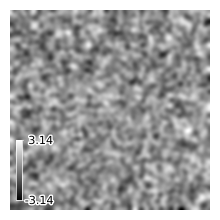

Image saved as ../../manuscript_figures/Figure_4_synthetic_models/blurred_white_noise_psd2d.svg


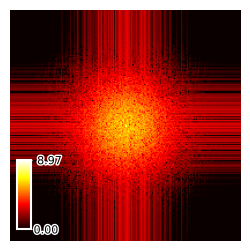

Image saved as ../../manuscript_figures/Figure_4_synthetic_models/blurred_white_noise_psd1d.svg


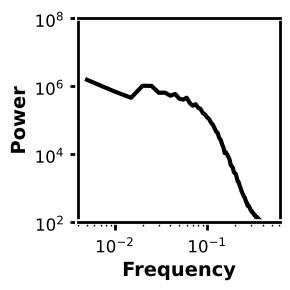

In [16]:
save_path = '../../manuscript_figures/Figure_4_synthetic_models'
synth_name = "blurred_white_noise"

full_save_name = synth_name + "_gt"



obj_arg = {'blur': True,
           'r_min_frac': 0.03,
           'r_max_frac': 0.2,
           'r_sigma': 3,
           'max_iters': 500}
#Data configs
data_config = DataConfig()
img_shape = (200,200)
#Simulate simplex
synthetic_obj_list = simulate_synthetic_objects(img_shape, data_config, 1, synth_name, obj_arg)



# Need to run "plot_complex_image" from Figure 1 section
plot_complex_image(synthetic_obj_list[0],
                   save_path = save_path,
                   save_name = full_save_name)

#PSD
full_save_name = synth_name + "_psd2d"


psd_image = compute_psd_2d(synthetic_obj_list[0])
plot_psd_2d(psd_image, figsize = (3,3),
            save_path = save_path,
            save_name = full_save_name)

#Generating object for plotting


full_save_name = synth_name + '_psd1d'
fig = plot_radial_psd(synthetic_obj_list[0], figsize = (3,3), line_color = 'black',save_path = save_path, save_name = full_save_name)




### Plotting images of rest of reconstructions

##### TP2

Image saved as ../../manuscript_figures/Figure_4_synthetic_models/simplex/tp2_zoomed_tp2_simplex.svg


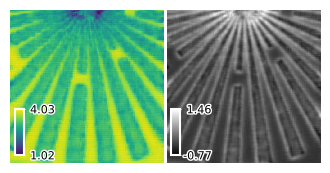

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7fc0bbc5b6d0>)

In [113]:
#tp2
half = gt.shape[0]//2
full_save_name = "tp2_zoomed_tp2_simplex"

plot_object(recon,
            save_path = '../../manuscript_figures/Figure_4_synthetic_models/simplex',
            save_name = full_save_name)

##### IC2

Image saved as ../../manuscript_figures/Figure_4_synthetic_models/simplex/ic2_zoomed_ic2_simplex.svg


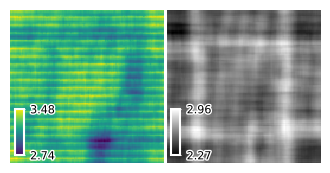

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7fc0bb80a5f0>)

In [115]:
#Ic_2
half = gt.shape[0]//2
full_save_name = "ic2_zoomed_ic2_simplex"
size = 130
y_offset = -95
x_offset = -10
plot_object(recon[half+y_offset:half+y_offset+size, half+x_offset-size//2:half+x_offset+size//2],
            save_path = '../../manuscript_figures/Figure_4_synthetic_models/simplex',
            save_name = full_save_name)

Image saved as ../../manuscript_figures/Figure_4_synthetic_models/simplex/ic2_unzoomed_ncm_simplex.svg


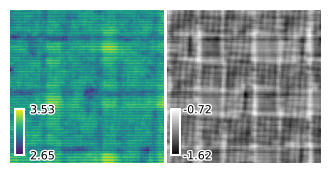

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7fc0baf3fc40>)

In [120]:
#Ic_2
half = gt.shape[0]//2
full_save_name = "ic2_unzoomed_ncm_simplex"

plot_object(recon,
            save_path = '../../manuscript_figures/Figure_4_synthetic_models/simplex',
            save_name = full_save_name)

##### Fly1

Image saved as ../../manuscript_figures/Figure_4_synthetic_models/simplex/fly1_zoomed_fly1_simplex.svg


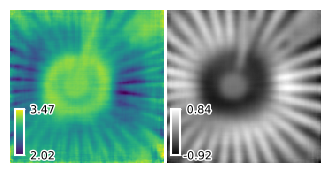

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7fc0bbceb430>)

In [111]:
#fly1
half = gt.shape[0]//2
full_save_name = "fly1_zoomed_fly1_simplex"

plot_object(recon,
            save_path = '../../manuscript_figures/Figure_4_synthetic_models/simplex',
            save_name = full_save_name)

##### NCM

Image saved as ../../manuscript_figures/Figure_4_synthetic_models/simplex/ncm_zoomed_tp2_simplex.svg


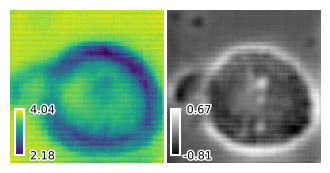

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7fc0bb35f760>)

In [126]:
#Ic_2
half = gt.shape[0]//2
full_save_name = "ncm_zoomed_tp2_simplex"
plot_object(recon,
            save_path = '../../manuscript_figures/Figure_4_synthetic_models/simplex',
            save_name = full_save_name)

Image saved as ../../manuscript_figures/Figure_3_comparison/fly001_gt.svg


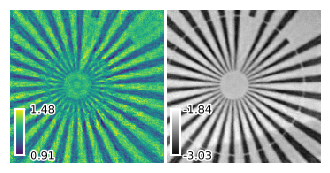

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7f7da2c22da0>)

In [ ]:
full_save_name = 'fly001_gt'
plot_object(gt,
            save_path = '../../manuscript_figures/Figure_3_comparison/',
            save_name = full_save_name)

##### CNM

Image saved as ../../manuscript_figures/Figure_4_synthetic_models/simplex/cnm_zoomed_cnm_simplex.svg


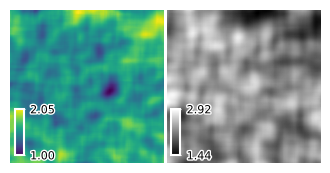

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7fc0bbb25750>)

In [107]:
#CNM
half = gt.shape[0]//2
full_save_name = "cnm_zoomed_cnm_simplex"
plot_object(recon,
            save_path = '../../manuscript_figures/Figure_4_synthetic_models/simplex',
            save_name = full_save_name)

##### LFP

Image saved as ../../manuscript_figures/Figure_4_synthetic_models/lfp_zoomed_lfp_deadleaves.svg


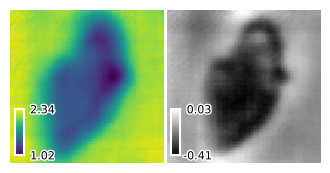

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7fc0d04bff10>)

In [ ]:
#LFP
half = gt.shape[0]//2
full_save_name = "lfp_zoomed_lfp_deadleaves"

plot_object(recon,
            save_path = '../../manuscript_figures/Figure_4_synthetic_models',
            save_name = full_save_name)

Image saved as ../../manuscript_figures/Figure_3_comparison/lfp_gt.svg


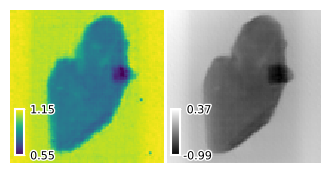

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7f7da2a25840>)

In [ ]:
full_save_name = 'lfp_gt'
plot_object(gt,
            save_path = '../../manuscript_figures/Figure_3_comparison/',
            save_name = full_save_name)

# Supplemental Information

To-do here:

- Ablation test for different inductive biases
- Performance scaling with image number
- Speed tests
- Show reconstructions from training sets on synthetic data

## Ablation tests for IC2

Run Figure 2, 1a. helper functions first

In [2]:
file_list = [
            '../../data/pinn_velo_ic_2',
            '../../data/pinn_velo_ncm',
            '../../data/pinn_gold_tp_1'
            ]

model_dict = {
    'ic2_supervised': '35a811fe6b2e4d1dbda4822b2fe197f4',
    'ic2_unsupervised_cdi': 'b2a05bdc3acb4aa4adde50c00ae05f44',
    'ic2_pinn_nearby': '5bd8835da18746f3a9a0636b9a718b4d',
    'ic2_pinn_patch_encoding': 'c21418cb510e44989198fa2ee8b15092',
}

window_size_dict = {
    #Synthetic objects
    'pinn_hxn_cnm': 20,
    'pinn_hxn_cnm_supervised': 20,
    'pinn_velo_fly001': 20,
    'pinn_velo_fly001_supervised': 20,
    'pinn_velo_als_ns': 20,
    'pinn_velo_gold_tp_1': 20,
    'pinn_velo_gold_tp_1_supervised': 15,
    'pinn_velo_gold_tp_2': 40,
    'pinn_velo_gold_tp_2_supervised': 40,
    'pinn_velo_ic_1': 20,
    'pinn_velo_ic_1_supervised': 18,
    'pinn_velo_ic_2': 20,
    'pinn_velo_ic_2_supervised': 20,
    'pinn_cosmic_micro_lfp': 20,
    'pinn_velo_ncm': 20,
    'pinn_velo_ncm_supervised': 10,
}
# Constant vars
relative_mlruns_path = '../../mlruns'
tracking_uri = f"file:{os.path.abspath(relative_mlruns_path)}"

### Calculating all FRCS

In [ ]:
import ptychopinn_torch.notebooks.analysis
importlib.reload(ptychopinn_torch.notebooks.analysis)
from ptychopinn_torch.notebooks.analysis import calculate_all_frcs
from ptychopinn_torch.notebooks.analysis import generate_gt_and_recon, plot_object

In [ ]:
calculate_all_frcs(file_list, model_dict, window_size_dict,
                   "../../data/frc_results",
                   save_file_name = "frc_different_synthetic.npz")

Loading existing frc_results.npz
Skipping pinn_hxn_cnm with model CNM_deadleaves, already processed.
Skipping pinn_hxn_cnm with model fly1_deadleaves, already processed.
Skipping pinn_hxn_cnm with model tp2_deadleaves, already processed.
Skipping pinn_hxn_cnm with model lfp_deadleaves, already processed.
Skipping pinn_hxn_cnm with model CNM_procedural, already processed.
Skipping pinn_hxn_cnm with model fly1_procedural, already processed.
Skipping pinn_hxn_cnm with model tp2_procedural, already processed.
Skipping pinn_hxn_cnm with model lfp_procedural, already processed.
Skipping pinn_hxn_cnm with model CNM_blurred_wn, already processed.
Skipping pinn_hxn_cnm with model fly1_blurred_wn, already processed.
Skipping pinn_hxn_cnm with model tp2_blurred_wn, already processed.
Skipping pinn_hxn_cnm with model lfp_blurred_wn, already processed.
Skipping pinn_velo_fly001 with model CNM_deadleaves, already processed.
Skipping pinn_velo_fly001 with model fly1_deadleaves, already processed.
Ski

### Reconstructions for viewing

In [159]:
idx = 2
name = list(model_dict.keys())[idx]
gt, recon = generate_gt_and_recon('../../data/pinn_velo_ic_1_supervised', name, model_dict)



Creating dataset...
Calculating dataset length with coordinate bounds...
For file ../../data/pinn_velo_ic_1_supervised/supervised_pinn_ic_1.npz, maximum x_range is (33.129241943359375, 170.87075805664062), yrange is (33.0966911315918, 165.90330505371094)
Creating memory mapped tensor dictionary...
Memory map length: 779
Memory map creation time: 0.0011603832244873047
Populating memory map for dataset 0
Start - end = 779
grouping
<function get_neighbor_indices at 0x7fd7a38e3c70>
begin nn_indices
nn_indices_bounded_shape (779, 7)
Non-diffraction memory map write time: 0.016620635986328125
Getting normalization coefficients...
Normalize is Batch
Batch rms factor is tensor([[[[0.0032]]]])
Diffraction memory map write time: 0.03532695770263672
[PtychoDataset Rank 0] Initialization successful. Dataset length: 779.
Beginning reconstruction...
Reconstructing image...
Batch 0 completed in 0.14824366569519043 seconds
Batch 1 completed in 0.07710862159729004 seconds
Recon complete. Beginning FRC 

### IC2

Image saved as ../../manuscript_figures/Supplemental/Ablation_PINN/Out-of-distribution/ncm_supervised_zoomed.svg


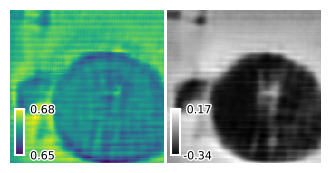

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7fd77ca02350>)

In [ ]:
#Ic_2
exp_name = 'ic2'
half = recon.shape[0]//2
full_save_name = exp_name + '_' + name.split('_')[1] + "_zoomed"
size = 170
y_offset = -95
x_offset = -10
plot_object(recon[half+y_offset:half+y_offset+size, half+x_offset-size//2:half+x_offset+size//2],
            save_path = '../../manuscript_figures/Supplemental/Ablation_PINN/Out-of-distribution',
            save_name = full_save_name)

### NCM/Others

Image saved as ../../manuscript_figures/Supplemental/Ablation_PINN/Out-of-distribution/ic1_pinn_nearby_zoomed.svg


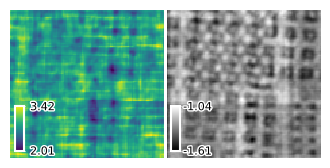

Image saved as ../../manuscript_figures/Supplemental/Ablation_PINN/Out-of-distribution/ic1_gt.svg


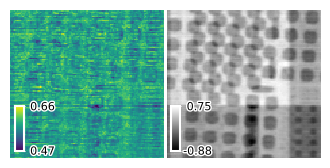

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7fd770dd3820>)

In [160]:
#Other experiments
exp_name = 'ic1'
w =1
half = recon.shape[0]//2
full_save_name = exp_name + '_' + '_'.join(name.split('_')[1:]) + "_zoomed"

plot_object(recon[w:-5,w:-w],
            save_path = '../../manuscript_figures/Supplemental/Ablation_PINN/Out-of-distribution',
            save_name = full_save_name)

plot_object(gt[w:-5,w:-w],
            save_path = '../../manuscript_figures/Supplemental/Ablation_PINN/Out-of-distribution',
            save_name = exp_name + "_gt")

## Just show loss curves for specific training

### IC2 synthetic

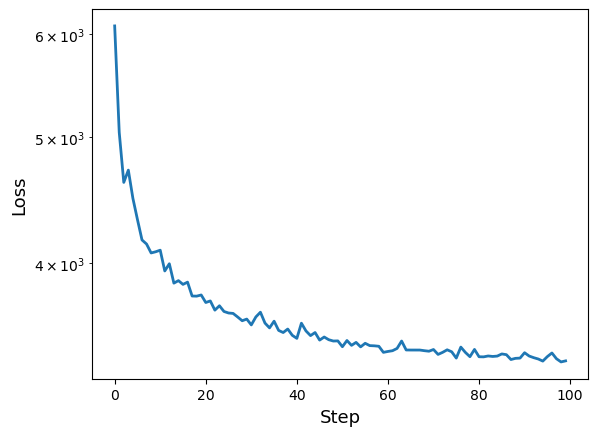

In [170]:
#Code taken from model_recon_evaluation.ipynb
validation = True

run_id = 'd141fe4eea1849b7941c78683f60e0fa'
save_path = '../../manuscript_figures/Supplemental/'
save_name = 'ic2_loss_curve_100_epochs'

relative_mlruns_path = '../../mlruns'
tracking_uri = f"file:{os.path.abspath(relative_mlruns_path)}"
data_config, model_config, training_config, inference_config = load_all_configs_from_mlflow(run_id,
                                                                                            tracking_uri)
#Getting loss
client = mlflow.tracking.MlflowClient()
run = client.get_run(run_id)

if model_config.amp_loss:
    loss_name = "poisson_train_Amp_loss"
    if model_config.phase_loss:
        loss_name = "poisson_train_Amp_Phase_loss"
elif model_config.phase_loss:
    loss_name = "poisson_train_Phase_loss"
elif model_config.mode == 'Unsupervised':
    loss_name = "poisson_train_loss"
elif model_config.mode == "Supervised":
    loss_name = "mae_train_loss"

if validation:
    if model_config.mode == "Unsupervised":
        loss_name = "poisson_val_loss"
    else:
        loss_name = "mae_val_loss"

metrics = client.get_metric_history(run_id, loss_name)


loss_history = [(m.step, m.value) for m in metrics]

plot_step = np.array([l[0] for l in loss_history])
plot_loss = np.array([l[1] for l in loss_history])

plt.plot(plot_step,plot_loss, linewidth = 2)
plt.xlabel('Step', fontsize = 13)
plt.ylabel('Loss', fontsize = 13)
plt.yscale('log')
# plt.ylim([1e6,7e6])
# plt.xlim([30,40])
# plt.ylim([1e3, 3e3])

full_save_path = os.path.join(save_path, f"{save_name}.svg")
plt.savefig(full_save_path, format='svg', dpi=600, 
            bbox_inches='tight', pad_inches=0, 
            transparent=True, facecolor='none')


## Reconstruction at different synthetic image numbers

In [305]:
#All general models, not fine-tuned
model_dict = {
    #TP2
    'tp2_2ims': 'd19a9baa74ea4ac797e88fc356329d5f',
    'tp2_4ims': '6fb4668f21e44e0b80056f64fdfedf01',
    'tp2_6ims': '18a9964fcd04458f82e1b057b2634ec1',
    'tp2_10ims': '20390aef5981432db6707e3cd8c4aa6c',
    #CNM
    'cnm_2ims': 'e2b6e5a314314c7dada587042ae792a8',
    'cnm_4ims': '74ba23396c4042afb1751afe9fa87520',
    'cnm_6ims': '6713fa786c654b92a87fd7675adb83f5',
    'cnm_10ims': '5212a78373324eefbb61a80abcd6b854',
    #Fly1
    'fly1_2ims': '9a9b02d3feb04592a3744b4940a426e1',
    'fly1_4ims': '3d2ca583357c43baa6ab17519d500355',
    'fly1_6ims': 'fa47a1c656074059893b829c73b3c275', #Redo
    'fly1_10ims': '71a6d7f0500845f99097f5112aa9e2df', #Redo
    #LFP
    'lfp_2ims': 'a4d8423356234a00862bd96403fddc8f',
    'lfp_4ims': '1cda8280703748fabba173f747fc4103',
    'lfp_6ims': 'ef7deb55365d4dd386d59cc135c4d822', #Redo
    'lfp_10ims': '40b3895767794da2af8315e42857c3c3' #Redo
}

window_size_dict = {
    #Synthetic objects
    'pinn_hxn_cnm': 20,
    'pinn_hxn_cnm_supervised': 20,
    'pinn_velo_fly001': 10,
    'pinn_velo_fly001_supervised': 20,
    'pinn_velo_als_ns': 20,
    'pinn_velo_gold_tp_1': 20,
    'pinn_velo_gold_tp_1_supervised': 15,
    'pinn_velo_gold_tp_2': 40,
    'pinn_velo_gold_tp_2_supervised': 40,
    'pinn_velo_ic_1': 20,
    'pinn_velo_ic_1_supervised': 18,
    'pinn_velo_ic_2': 20,
    'pinn_velo_ic_2_supervised': 20,
    'pinn_cosmic_micro_lfp': 14,
    'pinn_velo_ncm': 20,
    'pinn_velo_ncm_supervised': 10,
}
# Constant vars
relative_mlruns_path = '../../mlruns'
tracking_uri = f"file:{os.path.abspath(relative_mlruns_path)}"

In [313]:
name = 'lfp_4ims'
gt, recon = generate_gt_and_recon('../../data/pinn_cosmic_micro_lfp', name, model_dict)



Creating dataset...
Calculating dataset length with coordinate bounds...
For file ../../data/pinn_cosmic_micro_lfp/microLFPstack_single_exposure_64_train.npz, maximum x_range is (33.45436096191406, 144.54563903808594), yrange is (33.45436096191406, 144.54563903808594)
Creating memory mapped tensor dictionary...
Memory map length: 4489
Memory map creation time: 0.0011615753173828125
Populating memory map for dataset 0
Start - end = 4489
grouping
4_quadrant
Building KDTree for 5625 points...
Processing 4489 potential central points...
Finished quadrant neighbor processing. Found 4489 valid C=4 groups.
Non-diffraction memory map write time: 0.48882198333740234
Getting normalization coefficients...
Normalize is Batch
Batch rms factor is tensor([[[[0.0060]]]])
Diffraction memory map write time: 0.14825725555419922
[PtychoDataset Rank 0] Initialization successful. Dataset length: 4489.
Beginning reconstruction...
Reconstructing image...
Batch 0 completed in 0.14597225189208984 seconds
Batch 

Image saved as ../../manuscript_figures/Supplemental/Synthetic_image_scaling/lfp_4ims.svg


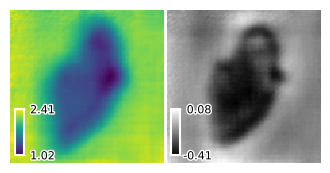

Image saved as ../../manuscript_figures/Supplemental/Synthetic_image_scaling/lfp_gt.svg


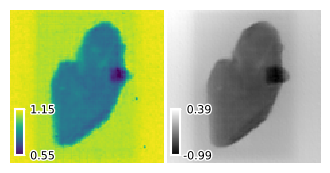

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7fd76ab9c040>)

In [314]:
#Other experiments
exp_name = 'lfp'
w = 1
half = recon.shape[0]//2
full_save_name = exp_name + '_' + '_'.join(name.split('_')[1:])

plot_object(recon[w:-w,w:-w],
            save_path = '../../manuscript_figures/Supplemental/Synthetic_image_scaling',
            save_name = full_save_name)

plot_object(gt[w:-w,w:-w],
            save_path = '../../manuscript_figures/Supplemental/Synthetic_image_scaling',
            save_name = exp_name + "_gt")

## Synthetic image predictions for different object models

In [38]:
import importlib
import os
import torch
from glob import glob
import ptychopinn_torch.datagen.datagen
import ptychopinn_torch.datagen.probe
import ptychopinn_torch.datagen.objects
import ptychopinn_torch.notebooks.analysis
importlib.reload(ptychopinn_torch.datagen.datagen)
importlib.reload(ptychopinn_torch.datagen.probe)
importlib.reload(ptychopinn_torch.datagen.objects)
importlib.reload(ptychopinn_torch.notebooks.analysis)

from ptychopinn_torch.datagen.datagen import simulate_multiple_experiments, generate_simulated_data
from ptychopinn_torch.datagen.datagen import assemble_precomputed_images, simulate_synthetic_objects, simulate_synthetic_probes
from ptychopinn_torch.datagen.probe import generate_random_fzp, generate_random_zernike, generate_zernike_probe
from ptychopinn_torch.datagen.objects import generate_base_map_shapes_perlin_layers, create_complex_polyhedra, create_dead_leaves, create_white_noise_object, create_simplex_noise_object
from ptychopinn_torch.config_params import DataConfig, update_existing_config

from ptychopinn_torch.notebooks.analysis import generate_gt_and_recon, plot_object

### Generating synthetic data quickly
Copied from test_synthetic_datagen.ipynb

In [39]:
def remove_all_files(directory_path):
    """
    Remove all files in the specified directory without removing the directory itself.
    
    Args:
        directory_path (str): Path to the directory whose files should be removed
        
    Returns:
        int: Number of files removed
    """
    count = 0
    
    # Check if the directory exists
    if not os.path.exists(directory_path):
        print(f"Directory '{directory_path}' does not exist.")
        return count
        
    # Loop through all items in the directory
    for item in os.listdir(directory_path):
        item_path = os.path.join(directory_path, item)
        
        # Check if it's a file and remove it
        if os.path.isfile(item_path):
            os.remove(item_path)
            count += 1
            
    print(f"Removed {count} files from '{directory_path}'")
    return count

In [43]:
#Prep and setting up

#Calculating number of synthetic objects/probes needed
exp_dir_list = [#'../data/pinn_hxn_cnm',
            '../../data/pinn_velo_fly001',
            # '../data/pinn_velo_als_ns',
            #'../data/pinn_velo_als_gold',
            # '../data/pinn_velo_gold_tp_1',
            # '../../data/pinn_velo_gold_tp_2',
            # '../data/pinn_velo_ic_1',
            # '../data/pinn_velo_ic_2',
            # '../data/pinn_cosmic_micro_lfp',
            # '../data/test_pinn_als_ns',
            # '../data/pinn_velo_ncm',
            ]

probe_name_list = [item.split('/')[-1] for item in exp_dir_list]

n_exp_probes = len(exp_dir_list)
obj_per_exp_probe = 1

n_exp_obj = n_exp_probes * obj_per_exp_probe
n_synth_obj = 0 # Number of objects associated with synthetic probes

#Total number of "experiments" (i.e. number of synthetic objects needed)
#is number of experimental objects + number of synthetic objects
#Essentially, we want the experimental probes to get "more" objects per probe
n_experiments = n_exp_obj + n_synth_obj


#Image sizing
images_per_experiment = 7000
img_shape = (250,250) #Object sizing

#Misc
save_dir = "../../data/synthetic_experiments"

#Probe arguments
probe_arg = {'ortho': True,
             'beamstop_diameter': 4,
             'phase_noise': True,
             'amp_noise': True,
             'max_order': 10,
             'probe_names': probe_name_list,}

obj_arg = {'blur': False,
           'r_min_frac': 0.03,
           'r_max_frac': 0.2,
           'r_sigma': 3,
           'max_iters': 500}

            #  'probe_method': 'fzp'}

#Data configs
data_config = DataConfig()
data_config_replace = {'N': 64}
update_existing_config(data_config, data_config_replace)


In [44]:
#Generating object list, probe list
synthetic_obj_list = simulate_synthetic_objects(img_shape, data_config, n_experiments, "white_noise", obj_arg)

synthetic_probe_list = simulate_synthetic_probes(data_config, n_synth_obj, "zernike",
                                                 probe_arg)
        

#Only assemble experimental probes. Objects will be synthetic
exp_probe_list = assemble_precomputed_images(exp_dir_list, 'probe')
# exp_obj_list = assemble_precomputed_images(exp_dir_list, 'object')

#We'll give each probe 2 objects to train on
probe_list = [item for item in exp_probe_list for _ in range(obj_per_exp_probe)] \
              + synthetic_probe_list

#Assign probe name indices based on what index the item is in the probe list
probe_name_idx = [idx for idx in list(range(len(exp_dir_list))) for _ in range(obj_per_exp_probe)] \
                + [idx + n_exp_probes * obj_per_exp_probe for idx in range(len(synthetic_probe_list))]

probe_arg['probe_name_idx'] = probe_name_idx

#The rest will just be vanilla

#Remnove old files
remove_all_files(save_dir)

#Save new ones
simulate_multiple_experiments(synthetic_obj_list, probe_list,
                              images_per_experiment,
                              img_shape, data_config, probe_arg,
                              save_dir)

torch.cuda.empty_cache()

Removed 1 files from '../../data/synthetic_experiments'
----Beginning simulation for experiment 0----
Beginning simulation...
Processing 7000 images in batches of 3000...
  Getting image patches...
  Diffracting...
  Poisson scaling...
  Applying detector beamstop...
  Getting image patches...
  Diffracting...
  Poisson scaling...
  Applying detector beamstop...
  Getting image patches...
  Diffracting...
  Poisson scaling...
  Applying detector beamstop...
Concatenating results...
----Finished saving for experiment 0 in 0.907470703125 seconds----


### Predicting on synthetic data with loaded models

In [40]:
file_list = ['../../data/pinn_hxn_cnm',
            '../../data/pinn_velo_fly001',
            '../../data/pinn_velo_gold_tp_2',
            '../../data/pinn_cosmic_micro_lfp',
            '../../data/pinn_velo_ic_2',
            '../../data/pinn_velo_ncm',
            ]

model_dict = {

    # Dead leaves
    "CNM_deadleaves": "74ba23396c4042afb1751afe9fa87520",
    "fly1_deadleaves": "6963a95288f94ed295ebce5415b1b68d",#"3d2ca583357c43baa6ab17519d500355",
    "tp2_deadleaves": "6fb4668f21e44e0b80056f64fdfedf01",
    "lfp_deadleaves": "1cda8280703748fabba173f747fc4103",

    # Procedural
    "CNM_procedural": "ed7cabe320b94e82a2a8c13b519abc6d",
    "fly1_procedural": "11ff4f97061f4554b831c45caa40f495",
    "tp2_procedural": "04106a3750184a2dbe544cc2c8c2f857",
    "lfp_procedural": "1aaf4df1f3a5440da898667953dd11f3",
    
    # Smooth White Noise (blurred_wn)
    "CNM_blurred_wn": "42d9fb49f2c94a44b0f03b7f221cab8f",
    "fly1_blurred_wn": "1c5528183d834c299e2d43e535fb8cf8",#"bc6992fb52c0415dbd0334d360b95227",
    "tp2_blurred_wn": "0c975e1328e64f7898abb6d94973bbec",
    # "ic2_blurred_wn": "1e2dbf5e00d24fcfadba84c9d9c39a70",
    # "ncm_blurred_wn": "a56e49f8884a49fd896a3b3fbafad693",
    "lfp_blurred_wn": "0248c08bb3c04004a6672a201f9a3a2d",

    # Simplex
    "CNM_simplex": "7c0b74ecf2d54198acea22aee60fdfc2",
    "fly1_simplex": "db698d0b702348ae8f33bf44e0d1573b",
    "tp2_simplex": "c98fefc6252e494db5f0ce5155904333",
    "ic2_simplex": "da9c13ba1e354a2ba7b020ed5d02fb75",
    "ncm_simplex": "72401cec06bb4673a321f90e4fa9e05f",
    "lfp_simplex": "12ce5db7c1564fd7a5fed78704b0c010",

    #Regular white noise
    "fly1_WN": "690c26efdb1841c3aad79eeec5f39337"
}

window_size_dict = {
    #Synthetic objects
    'pinn_hxn_cnm': 20,
    'pinn_velo_fly001': 10,
    'pinn_velo_gold_tp_2': 40,
    'pinn_cosmic_micro_lfp': 20,
    'pinn_velo_ic_2': 20,
    'pinn_velo_ncm': 20,
    'synthetic_experiments': 20
}

In [45]:
gt, recon = generate_gt_and_recon('../../data/synthetic_experiments','fly1_WN',model_dict, window_size_dict)

[0.05, 0.95] [0.05, 0.95]
Creating dataset...
Calculating dataset length with coordinate bounds...
For file ../../data/synthetic_experiments/synthetic_0.npz, maximum x_range is (31.34, 218.63), yrange is (31.35, 218.64)
Creating memory mapped tensor dictionary...
Memory map length: 5685
Memory map creation time: 0.0013365745544433594
Populating memory map for dataset 0
Start - end = 5685
Building KDTree for 7000 points...
Processing 5685 potential central points...
Finished quadrant neighbor processing. Found 5685 valid C=4 groups.
Non-diffraction memory map write time: 0.8886339664459229
Getting normalization coefficients...
Batch rms factor is tensor([[[[0.0033]]]])
Diffraction memory map write time: 0.2587857246398926
[PtychoDataset Rank 0] Initialization successful. Dataset length: 5685.
Beginning reconstruction...
Reconstructing image...
Batch 0 completed in 0.14794206619262695 seconds
Batch 1 completed in 0.1474459171295166 seconds
Batch 2 completed in 0.14606571197509766 seconds

Image saved as ../../manuscript_figures/Supplemental/Synthetic_predictions/white_noise_pred.svg


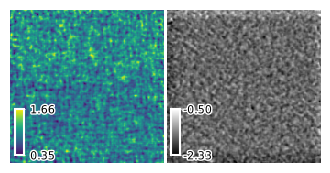

Image saved as ../../manuscript_figures/Supplemental/Synthetic_predictions/white_noise_gt.svg


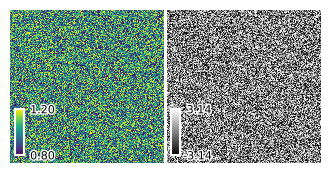

(<Figure size 400x200 with 4 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7eff6456ac80>)

In [46]:
# Plot object
exp_name = 'white_noise'
full_save_name = exp_name

plot_object(recon,
            save_path = '../../manuscript_figures/Supplemental/Synthetic_predictions',
            save_name = full_save_name + '_pred')

plot_object(gt,
            save_path = '../../manuscript_figures/Supplemental/Synthetic_predictions',
            save_name = full_save_name + '_gt')